# Evaluate and compare unlearning approaches

Load test data to evaluate performance, forget set to evaluate if data was forgotten.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

WORK_DIR_ROOT = '/content/drive/MyDrive/datasets/Master/'
sys.path.append(WORK_DIR_ROOT)

from utils import *
from utils import run_inference_3_modalities, top_k_from_logits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import random
import matplotlib.pyplot as plt


DATASET_ROOT = '/content/drive/MyDrive/datasets/Master/datasets_orig'
METADATA_TRAIN_PATH = f"{DATASET_ROOT}/MILK10k_Training_Metadata.csv"
METADATA_TEST_PATH = f"{DATASET_ROOT}/MILK10k_Test_Metadata.csv"
DATASET_TRAIN = f"{DATASET_ROOT}/MILK10k_Training_Input/MILK10k_Training_Input/"
DATASET_RESIZED = f"{WORK_DIR_ROOT}/datasets_resized_stratified/"
GT_PATH = f"{DATASET_ROOT}/MILK10k_Training_GroundTruth.csv"


CHECKPOINT_DIR = WORK_DIR_ROOT + 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Mounted at /content/drive


#### Import model 8 architecture:

In [2]:
from VitClassifier_1_defnitions import MutualCrossAttentionModel_3modalities

#### Import metrics for evaluation of unlearning:

In [3]:
from utils import compute_forgetting_mse, compute_auc, compute_pr_auc, compute_fairness

#### Methods for model load:

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def loadSavedModel8(model_filename, metadata_dim, device = device):
  # Initialize
  model = MutualCrossAttentionModel_3modalities(
      metadata_dim=metadata_dim, num_classes=11).to(device)

  # load the model as saved in the checkpoints dir:

  checkpoint_path = CHECKPOINT_DIR + "/" + model_filename
  checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
  #checkpoint = torch.load(checkpoint_path, map_location=device)

  # now load the actual model weights
  model.load_state_dict(checkpoint["model_state"])

  return model

Using device: cpu


## Load data:

In [ ]:
from utils import LABEL_COLUMNS, LABEL_NAMES


df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "skin_tone_class", "sex", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
print(df_train_dermoscopic_minimal.head())

print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

    lesion_id       isic_id          image_type  age_approx  skin_tone_class  \
0  IL_0000652  ISIC_8149219  clinical: close-up        70.0                1   
1  IL_0003176  ISIC_3904045  clinical: close-up        45.0                5   
2  IL_0004688  ISIC_0791494  clinical: close-up        50.0                3   
3  IL_0005081  ISIC_5667730  clinical: close-up        45.0                3   
4  IL_0006177  ISIC_8803389  clinical: close-up        75.0                3   

      sex             site  label_id  
0    male   head_neck_face         1  
1  female   head_neck_face         1  
2    male  lower_extremity         1  
3    male   head_neck_face         9  
4    male  upper_extremity         1  
    lesion_id       isic_id   image_type  age_approx  skin_tone_class     sex  \
0  IL_0000652  ISIC_4671410  dermoscopic        70.0                1    male   
1  IL_0003176  ISIC_5371928  dermoscopic        45.0                5  female   
2  IL_0004688  ISIC_3624913  dermoscopic  

In [ ]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# We can create the validation dataframes immediately:

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Validation
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

# Validation
df_test_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)


Lesions - Train: 4191, Val: 524, Test: 525


Load the forget and retain set.

In [ ]:
RANDOM_SEED = 42
FORGET_RATIO = 0.05

split_path = WORK_DIR_ROOT + "/unlearning_lesion_split_random_5.json"

print("Loading existing unlearning split...")

with open(split_path, "r") as f:
    unlearning_split = json.load(f)

forget_lesions = unlearning_split["forget"]
retain_lesions = unlearning_split["retain"]

Loading existing unlearning split...


In [ ]:
# The train set is split to forget and retain.

# Clinical forget set:
df_forget_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


# Dermoscopic forget set:

df_forget_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


In [ ]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


In [ ]:
import numpy as np

ages = df_val_clinical["age_approx"].values
print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 31, 41, 51, 61, 71, 81, np.inf],
    labels=["<=30", "31-40", "41-50", "51-60", "61-70", "71-80", ">=81"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

#print(pd.Series(skin).value_counts().sort_index())

age_approx
65.0    75
70.0    66
50.0    61
75.0    56
60.0    53
55.0    50
85.0    42
80.0    37
45.0    37
40.0    15
35.0    12
30.0     9
15.0     5
25.0     4
5.0      1
Name: count, dtype: int64
<=30      19
31-40     27
41-50     98
51-60    103
61-70    141
71-80     93
>=81      42
Name: count, dtype: int64
1     11
2     50
3    319
4    107
5     37
Name: count, dtype: int64


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

forget_transform = transforms.Compose([
    transforms.ToTensor()])

validation_transform = transforms.Compose([
    transforms.ToTensor()])

In [ ]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Using the FORGET datasets here:

forget_dataset = Milk10kDataset_3_modalities(
    df_forget_clinical,
    df_forget_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)

# using the validation as usual.
val_dataset = Milk10kDataset_3_modalities(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform
)


Using device: cuda


In [ ]:
NUM_WORKERS = 2

forget_loader = DataLoader(
    forget_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

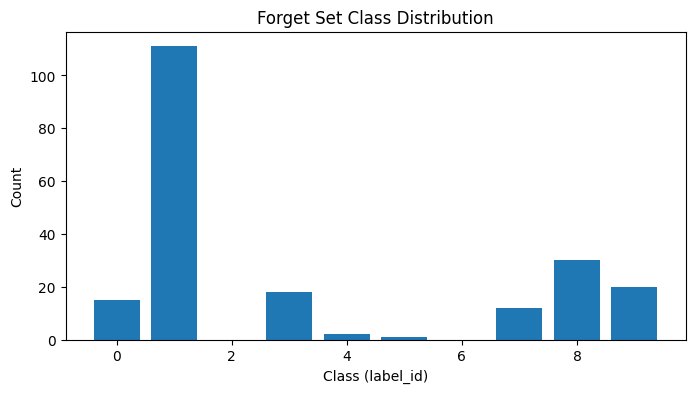

In [ ]:
import matplotlib.pyplot as plt

forget_counts = df_forget_clinical["label_id"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(forget_counts.index, forget_counts.values)
plt.xlabel("Class (label_id)")
plt.ylabel("Count")
plt.title("Forget Set Class Distribution")
plt.show()

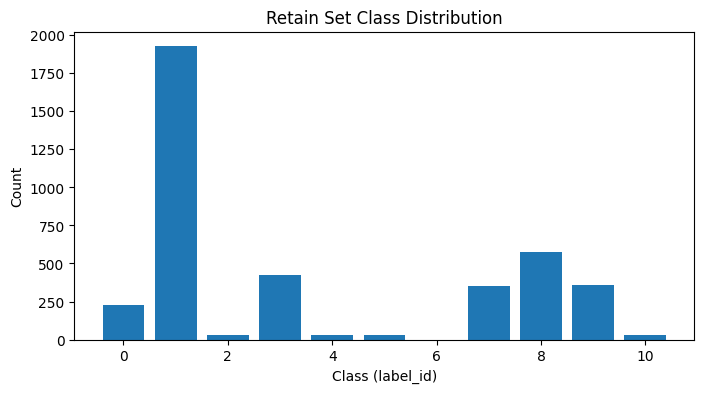

In [ ]:
df_retain_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(retain_lesions)
].reset_index(drop=True)

retain_counts = df_retain_clinical["label_id"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(retain_counts.index, retain_counts.values)
plt.xlabel("Class (label_id)")
plt.ylabel("Count")
plt.title("Retain Set Class Distribution")
plt.show()

## (-1) Original model 8 trained on full data

In [ ]:
# @title

original = loadSavedModel8("Cross_images_metadata_1_best_stage2.pt", forget_dataset.metadata_dim)

Test original model trained on full data on the forget subset:

In [ ]:
logits, y_true = run_inference_3_modalities(original, forget_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.9234449863433838


In [ ]:
print(f"Forgetting metric: Reference model versus Original model: {compute_forgetting_mse(model, original, forget_loader, device)}")

Forgetting metric: Reference model versus Original model: 0.1994755119085312


Get utility of the Original model 8:

In [ ]:
print(f"Utility (AUC) for original model: {compute_auc(original, val_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
Utility (AUC) for original model: 0.9178267597619006


In [ ]:
print(f"Utility PR-AUC:")
compute_pr_auc(original, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5308
  Weighted PR-AUC: 0.7306


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.5307656264050732), np.float64(0.7305618657544172))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(original, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.7213740348815918


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.734375  0.058874       21
1  41-49  0.592430  0.040759       52
2  51-59  0.420332  0.042989      111
3  61-69  0.436234  0.038971      128
4  71-79  0.551885  0.036735      122
5    <30  1.000000  0.000000       10
6    >80  0.362640  0.048835       79

Age EO Gap: 0.1381525977802259

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.447165  0.042435      208
1    male  0.564537  0.034622      316

Gender EO Gap: 0.06259242085200101

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.566667  0.048669       11
1     2  0.480263  0.048465       50
2     3  0.470036  0.038075      319
3     4  0.679732  0.036097      107
4     5  0.269388  0.059005       37

Skin EO Gap: 0.09737303399418154

Generalized Fairness Score: 0.9006273157911973


## (0) Reference model

Load the reference model:

In [ ]:
# @title

model = loadSavedModel8("Retrained_unlearning_1_stage2.pt", forget_dataset.metadata_dim)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 198MB/s]


Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model, forget_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.7224880456924438


Print analysis, since I get NAN for AUC for all models! I had to add logic to skip some classes.

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (209,)
Unique labels: [0 1 3 4 5 7 8 9]
Num unique: 8
Class 0: 15 samples
Class 1: 111 samples
Class 3: 18 samples
Class 4: 2 samples
Class 5: 1 samples
Class 7: 12 samples
Class 8: 30 samples
Class 9: 20 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=15, negatives=194
Class 1: positives=111, negatives=98
Class 2: positives=0, negatives=209
Class 3: positives=18, negatives=191
Class 4: positives=2, negatives=207
Class 5: positives=1, negatives=208
Class 6: positives=0, negatives=209
Class 7: positives=12, negatives=197
Class 8: positives=30, negatives=179
Class 9: positives=20, negatives=189
Class 10: positives=0, negatives=209


Get utility of the reference model:

In [ ]:
print(f"Utility (AUC) for reference model: {compute_auc(model, val_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
Utility (AUC) for reference model: 0.9077943503326509


In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4731
  Weighted PR-AUC: 0.7058


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.4730882513679946), np.float64(0.7057836797141237))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(model, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.6545801758766174


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.453125  0.072294       21
1  41-49  0.403297  0.049605       52
2  51-59  0.410568  0.047750      111
3  61-69  0.355137  0.038353      128
4  71-79  0.353052  0.049352      122
5    <30  0.888889  0.018182       10
6    >80  0.300535  0.050929       79

Age EO Gap: 0.10523741267436278

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.343513  0.049781      208
1    male  0.374377  0.039909      316

Gender EO Gap: 0.020367931038989557

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.800000  0.020202       11
1     2  0.358827  0.064471       50
2     3  0.351904  0.044434      319
3     4  0.480276  0.039542      107
4     5  0.298639  0.061177       37

Skin EO Gap: 0.12412658607132025

Generalized Fairness Score: 0.9167560234051092


## (1) Fine-tuning 7 fixed epochs:

In [ ]:
# @title

unlearned_1 = loadSavedModel8("Finetune_2_unlearning_1.pt", forget_dataset.metadata_dim)

In [ ]:
# @title
logits, y_true = run_inference_3_modalities(unlearned_1, forget_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.9760765433311462


#### Calculate forgetting metric

In [ ]:
print(f"Forgetting metric: Reference model versus Fine tuning with fixed epochs: {compute_forgetting_mse(model, unlearned_1, forget_loader, device)}")

Forgetting metric: Reference model versus Fine tuning with fixed epochs: 0.27544909715652466


Get utility of the unlearned fine-tuning with 7 epochs model:

In [ ]:
print(f"Utility (AUC) for fine-tuned with fixed 7 epochs: {compute_auc(unlearned_1, val_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
Utility (AUC) for fine-tuned with fixed 7 epochs: 0.9163606332229346


In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(unlearned_1, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5516
  Weighted PR-AUC: 0.7529


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.5516294059820098), np.float64(0.7529172760571509))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(unlearned_1, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.7213740348815918


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.817708  0.040693       21
1  41-49  0.280260  0.056269       52
2  51-59  0.472384  0.040642      111
3  61-69  0.479567  0.031844      128
4  71-79  0.392800  0.040326      122
5    <30  1.000000  0.000000       10
6    >80  0.441721  0.038625       79

Age EO Gap: 0.15406675896047492

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.428131  0.038931      208
1    male  0.465548  0.034507      316

Gender EO Gap: 0.020920814222734053

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.733333  0.031566       11
1     2  0.515351  0.043849       50
2     3  0.430164  0.036271      319
3     4  0.568586  0.038176      107
4     5  0.291156  0.053065       37

Skin EO Gap: 0.10733532986911196

Generalized Fairness Score: 0.9058923656492263


## (2) Fine-tuning with perturbations

In [ ]:
perturbations = loadSavedModel8("Finetuning_3_unlearning_1.pt", forget_dataset.metadata_dim)

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, forget_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.7990430593490601


In [ ]:
print(f"Forgetting metric: Reference model versus Perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus Perturbations model: 0.18432529270648956


Get utility of the unlearned fine-tuning with perturbations model:

In [ ]:
print(f"Utility (AUC) for fine-tuned with perturbations epochs: {compute_auc(perturbations, val_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
Utility (AUC) for fine-tuned with perturbations epochs: 0.8579351812216741


In [ ]:
print(f"Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4194
  Weighted PR-AUC: 0.6992


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.41944073717030117), np.float64(0.6991649562115302))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.6622137427330017


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.255208  0.070491       21
1  41-49  0.444648  0.041911       52
2  51-59  0.430882  0.043837      111
3  61-69  0.317864  0.040652      128
4  71-79  0.345867  0.051183      122
5    <30  0.388889  0.027273       10
6    >80  0.438139  0.043928       79

Age EO Gap: 0.049838823777273125

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.361198  0.043259      208
1    male  0.321649  0.042884      316

Gender EO Gap: 0.019961622886363547

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.566667  0.051768       11
1     2  0.334156  0.057525       50
2     3  0.388902  0.041229      319
3     4  0.311034  0.045877      107
4     5  0.234014  0.064276       37

Skin EO Gap: 0.0800915749169968

Generalized Fairness Score: 0.9500359928064555


## (3) Fine-tuning with early stopping (1 epoch)
The model only trained one epoch and stopped automatically

In [ ]:
finetune_1 = loadSavedModel8("Finetune_unlearning_1.pt", forget_dataset.metadata_dim)

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_1, forget_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.9569377899169922


In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 1 epoch model: {compute_forgetting_mse(model, finetune_1, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 1 epoch model: 0.24963410198688507


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print(f"Utility (AUC) for fine-tuned with 1 epoch: {compute_auc(finetune_1, val_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
Utility (AUC) for fine-tuned with 1 epoch: 0.9236511002393133


In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_1, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5474
  Weighted PR-AUC: 0.7524


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.5474186028390964), np.float64(0.7524107711771542))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_1, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.7232824563980103


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.802083  0.045238       21
1  41-49  0.438380  0.050255       52
2  51-59  0.422713  0.046184      111
3  61-69  0.471053  0.034143      128
4  71-79  0.425172  0.038505      122
5    <30  1.000000  0.000000       10
6    >80  0.407317  0.043496       79

Age EO Gap: 0.1316310308093732

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.458078  0.041980      208
1    male  0.470845  0.035118      316

Gender EO Gap: 0.009814612761135124

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.041667       11
1     2  0.504934  0.046914       50
2     3  0.474900  0.038025      319
3     4  0.582907  0.036833      107
4     5  0.262585  0.064763       37

Skin EO Gap: 0.09809205542079844

Generalized Fairness Score: 0.920154100336231


## (4) Fine-tuning (6 epochs = 1/4 original training epochs)
The model trained on 6 epochs

In [ ]:
finetune_6 = loadSavedModel8("Finetuning_444_unlearning_1.pt", forget_dataset.metadata_dim)

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_6, forget_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.7846890091896057


In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 1 epoch model: {compute_forgetting_mse(model, finetune_6, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 1 epoch model: 0.11556176841259003


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print(f"Utility (AUC) for fine-tuned with 1 epoch: {compute_auc(finetune_6, val_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
Utility (AUC) for fine-tuned with 1 epoch: 0.8554079148030223


In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_6, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4345
  Weighted PR-AUC: 0.7056


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.43449271232752085), np.float64(0.7056412100861378))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_6, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.6927480697631836


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.520833  0.059885       21
1  41-49  0.267847  0.056820       52
2  51-59  0.425258  0.046961      111
3  61-69  0.377908  0.036956      128
4  71-79  0.385447  0.043310      122
5    <30  0.333333  0.036364       10
6    >80  0.380775  0.052508       79

Age EO Gap: 0.05094455472645518

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.329508  0.043019      208
1    male  0.308077  0.044270      316

Gender EO Gap: 0.011341075405837793

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.833333  0.021465       11
1     2  0.388980  0.045733       50
2     3  0.319954  0.044625      319
3     4  0.298819  0.049738      107
4     5  0.319048  0.059416       37

Skin EO Gap: 0.12199757990277178

Generalized Fairness Score: 0.938572263321645


## (5) NegGrad+ (500 steps, learning rate = 0.0002)


In [ ]:
neggrad = loadSavedModel8("NegGrad_plus_lr0.0002.pt", forget_dataset.metadata_dim)

In [ ]:
logits, y_true = run_inference_3_modalities(neggrad, forget_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.9234449863433838


In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 1 epoch model: {compute_forgetting_mse(model, neggrad, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 1 epoch model: 0.21486955881118774


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print(f"Utility (AUC) for fine-tuned with 1 epoch: {compute_auc(neggrad, val_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
Utility (AUC) for fine-tuned with 1 epoch: 0.9197508917929035


In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(neggrad, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5346
  Weighted PR-AUC: 0.7388


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.5346333731255533), np.float64(0.7387533755267117))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(neggrad, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.7156488299369812


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.802083  0.045238       21
1  41-49  0.481319  0.043617       52
2  51-59  0.436999  0.041245      111
3  61-69  0.456436  0.035355      128
4  71-79  0.408805  0.039432      122
5    <30  1.000000  0.000000       10
6    >80  0.395734  0.046266       79

Age EO Gap: 0.13363920160245418

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.461578  0.039736      208
1    male  0.464536  0.036222      316

Gender EO Gap: 0.003236182973132412

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.040404       11
1     2  0.501096  0.044251       50
2     3  0.470177  0.037774      319
3     4  0.576522  0.037883      107
4     5  0.262585  0.061679       37

Skin EO Gap: 0.09686861066343515

Generalized Fairness Score: 0.9220853349203262


## TEST

## Load test data:

In [ ]:
import numpy as np

ages = df_test_clinical["age_approx"].values
print(df_test_clinical["age_approx"].value_counts())
ages = df_test_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 30, 40, 50, 60, 70, 80, np.inf],
    labels=["<30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_test_clinical["sex"].values


skin_df = df_test_clinical["skin_tone_class"].values
print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

print(pd.Series(skin).value_counts().sort_index())

age_approx
70.0    74
65.0    74
75.0    62
55.0    57
60.0    45
50.0    45
80.0    41
85.0    34
45.0    27
40.0    19
35.0    14
30.0    12
20.0     7
25.0     4
5.0      4
10.0     3
15.0     1
Name: count, dtype: int64
<30       19
31-39     26
41-49     46
51-59    102
61-69    119
71-79    136
>80       75
Name: count, dtype: int64
0      3
1     19
2     58
3    294
4    103
5     48
Name: count, dtype: int64
0-1     22
2       58
3      294
4      103
5       48
Name: count, dtype: int64


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

test_transform = transforms.Compose([
    transforms.ToTensor()])

In [ ]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# using the test as usual.
test_dataset = Milk10kDataset_3_modalities(
    df_test_clinical,
    df_test_dermoscopic,
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform
)


Using device: cuda


In [ ]:
NUM_WORKERS = 2

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

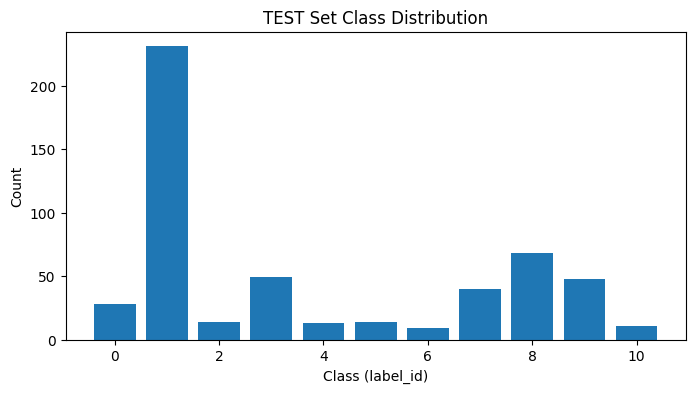

In [ ]:
import matplotlib.pyplot as plt

test_counts = df_test_clinical["label_id"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(test_counts.index, test_counts.values)
plt.xlabel("Class (label_id)")
plt.ylabel("Count")
plt.title("TEST Set Class Distribution")
plt.show()

## Test models:

## (-1) Original model 8 trained on full data

In [ ]:
# @title

original = loadSavedModel8("Cross_images_metadata_1_best_stage2.pt", test_dataset.metadata_dim)

Test original model trained on full data on the forget subset:

In [ ]:
logits, y_true = run_inference_3_modalities(original, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

Test accuracy: 0.6361904740333557


Get utility of the Original model 8:

In [ ]:
print(f"Utility (AUC) for original model:\n {compute_auc(original, test_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
Utility (AUC) for original model:
 0.8767054229700052


In [ ]:
print(f"Utility PR-AUC:")
compute_pr_auc(original, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4465
  Weighted PR-AUC: 0.6732


(np.float64(0.4464603061447851), np.float64(0.6732164045700508))

Fairness analysis:

In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.257143  0.056147       26
1  41-49  0.420256  0.041673       46
2  51-59  0.321368  0.048087      102
3  61-69  0.430901  0.048596      119
4  71-79  0.352957  0.051353      136
5    <30  0.251282  0.039341       19
6    >80  0.300654  0.053769       75

Age EO Gap: 0.047393553850786974

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.416577  0.037967      218
1    male  0.312225  0.054392      307

Gender EO Gap: 0.06038840908438828

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.568182  0.059163       22
1     2  0.243642  0.061036       58
2     3  0.257833  0.049116      294
3     4  0.422500  0.038047      103
4     5  0.388333  0.047559       48

Skin EO Gap: 0.08713292956874488

Generalized Fairness Score: 0.9350283691653599


## (0) Reference model

Load the reference model:

In [ ]:
# @title

model = loadSavedModel8("Retrained_unlearning_1_stage2.pt", test_dataset.metadata_dim)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 66.6MB/s]


Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

Test accuracy: 0.6209523677825928


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (525,)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10]
Num unique: 11
Class 0: 28 samples
Class 1: 231 samples
Class 2: 14 samples
Class 3: 49 samples
Class 4: 13 samples
Class 5: 14 samples
Class 6: 9 samples
Class 7: 40 samples
Class 8: 68 samples
Class 9: 48 samples
Class 10: 11 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=28, negatives=497
Class 1: positives=231, negatives=294
Class 2: positives=14, negatives=511
Class 3: positives=49, negatives=476
Class 4: positives=13, negatives=512
Class 5: positives=14, negatives=511
Class 6: positives=9, negatives=516
Class 7: positives=40, negatives=485
Class 8: positives=68, negatives=457
Class 9: positives=48, negatives=477
Class 10: positives=11, negatives=514


Get utility of the reference model:

In [ ]:
print(f"Utility (AUC) for reference model on test set:\n {compute_auc(model, test_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
Utility (AUC) for reference model on test set:
 0.8562386741115406


In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3963
  Weighted PR-AUC: 0.6412


(np.float64(0.3963375335126271), np.float64(0.6412013613557599))

Fairness analysis:

In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.282143  0.047739       26
1  41-49  0.341538  0.046073       46
2  51-59  0.317650  0.047180      102
3  61-69  0.296002  0.049470      119
4  71-79  0.304372  0.053159      136
5    <30  0.266667  0.034290       19
6    >80  0.354783  0.046836       75

Age EO Gap: 0.022337656103616228

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.337220  0.043971      218
1    male  0.333915  0.048675      307

Gender EO Gap: 0.0040052224456042125

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.500000  0.066883       22
1     2  0.346746  0.056634       58
2     3  0.290882  0.044960      294
3     4  0.434583  0.039318      103
4     5  0.288333  0.063900       48

Skin EO Gap: 0.06411056331690226

Generalized Fairness Score: 0.9698488527112924


## (1) Fine-tuning 7 fixed epochs:

In [ ]:
# @title

unlearned_1 = loadSavedModel8("Finetune_2_unlearning_1.pt", test_dataset.metadata_dim)

In [ ]:
# @title
logits, y_true = run_inference_3_modalities(unlearned_1, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

Test accuracy: 0.6609523892402649


Get utility of the unlearned fine-tuning with 7 epochs model:

In [ ]:
print(f"Utility (AUC) for fine-tuned with fixed 7 epochs:\n {compute_auc(unlearned_1, test_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
Utility (AUC) for fine-tuned with fixed 7 epochs:
 0.8805021792019075


In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(unlearned_1, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4843
  Weighted PR-AUC: 0.6922


(np.float64(0.48430275097925346), np.float64(0.6922147861025403))

Fairness analysis:

In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.266071  0.055758       26
1  41-49  0.370256  0.043004       46
2  51-59  0.358547  0.043587      102
3  61-69  0.466595  0.043831      119
4  71-79  0.368931  0.046529      136
5    <30  0.466667  0.029506       19
6    >80  0.374896  0.045226       75

Age EO Gap: 0.04339472530973299

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.420934  0.036650      218
1    male  0.350478  0.047071      307

Gender EO Gap: 0.040438869187560414

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.568182  0.058225       22
1     2  0.244267  0.058876       58
2     3  0.360254  0.039520      294
3     4  0.436944  0.038248      103
4     5  0.316667  0.052133       48

Skin EO Gap: 0.0828068714158055

Generalized Fairness Score: 0.944453178028967


## (2) Fine-tuning with perturbations

In [ ]:
perturbations = loadSavedModel8("Finetuning_3_unlearning_1.pt", test_dataset.metadata_dim)

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

Test accuracy: 0.630476176738739


Get utility of the unlearned fine-tuning with perturbations model:

In [ ]:
print(f"Utility (AUC) for fine-tuned with perturbations epochs:\n {compute_auc(perturbations, test_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
Utility (AUC) for fine-tuned with perturbations epochs:
 0.8461191053787871


In [ ]:
print(f"Utility PR-AUC:")
compute_pr_auc(perturbations, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4099
  Weighted PR-AUC: 0.6474


(np.float64(0.40987930096871045), np.float64(0.64743327626569))

Fairness analysis:

In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.264286  0.059307       26
1  41-49  0.261538  0.055353       46
2  51-59  0.324786  0.047394      102
3  61-69  0.375509  0.047702      119
4  71-79  0.341952  0.042936      136
5    <30  0.235897  0.043860       19
6    >80  0.390553  0.047119       75

Age EO Gap: 0.040107431264419124

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.380548  0.039907      218
1    male  0.319366  0.049705      307

Gender EO Gap: 0.035490042153158846

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.545455  0.061905       22
1     2  0.263914  0.060928       58
2     3  0.296382  0.045588      294
3     4  0.402222  0.042611      103
4     5  0.431667  0.047616       48

Skin EO Gap: 0.07522922599297857

Generalized Fairness Score: 0.9497244335298145


## (3) Fine-tuning with early stopping (1 epoch)
The model only trained one epoch and stopped automatically

In [ ]:
finetune_1 = loadSavedModel8("Finetune_unlearning_1.pt", test_dataset.metadata_dim)

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_1, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

Test accuracy: 0.6552380919456482


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print(f"Utility (AUC) for fine-tuned with 1 epoch:\n {compute_auc(finetune_1, test_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
Utility (AUC) for fine-tuned with 1 epoch:
 0.8877643383147114


In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_1, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4738
  Weighted PR-AUC: 0.6983


(np.float64(0.4737803091250475), np.float64(0.6983292596020939))

Fairness analysis:

In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.248214  0.059784       26
1  41-49  0.370256  0.043542       46
2  51-59  0.358547  0.043371      102
3  61-69  0.439402  0.045356      119
4  71-79  0.356274  0.048027      136
5    <30  0.251282  0.028708       19
6    >80  0.393078  0.045588       75

Age EO Gap: 0.046462936146979404

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.399228  0.037386      218
1    male  0.342917  0.049301      307

Gender EO Gap: 0.03411257954634432

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.568182  0.058947       22
1     2  0.256629  0.058575       58
2     3  0.296389  0.043089      294
3     4  0.435000  0.036507      103
4     5  0.371667  0.050115       48

Skin EO Gap: 0.08220829104820812

Generalized Fairness Score: 0.945738731086156


## (4) Fine-tuning (6 epochs = 1/4 original training epochs)
The model trained on 6 epochs

In [ ]:
finetune_6 = loadSavedModel8("Finetuning_444_unlearning_1.pt", test_dataset.metadata_dim)

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_6, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

Test accuracy: 0.6361904740333557


In [ ]:
print(f"Utility (AUC) for fine-tuned with 1 epoch:\n {compute_auc(finetune_6, test_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
Utility (AUC) for fine-tuned with 1 epoch:
 0.8069630236488635


In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_6, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3824
  Weighted PR-AUC: 0.6376


(np.float64(0.3824263087086788), np.float64(0.6375923415048681))

Fairness analysis:

In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.282143  0.048571       26
1  41-49  0.344615  0.047672       46
2  51-59  0.280983  0.050915      102
3  61-69  0.291970  0.050184      119
4  71-79  0.305124  0.051460      136
5    <30  0.200000  0.039075       19
6    >80  0.232472  0.055892       75

Age EO Gap: 0.03097665405752335

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.304880  0.044602      218
1    male  0.272719  0.052573      307

Gender EO Gap: 0.020065815817848415

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.409091  0.071645       22
1     2  0.370394  0.045785       58
2     3  0.279677  0.047138      294
3     4  0.301806  0.044012      103
4     5  0.190000  0.075082       48

Skin EO Gap: 0.061690060541458515

Generalized Fairness Score: 0.9624224898610566


## (5) NegGrad+ (500 steps, learning rate = 0.0002)

In [ ]:
neggrad = loadSavedModel8("NegGrad_plus_lr0.0002.pt", test_dataset.metadata_dim)

In [ ]:
logits, y_true = run_inference_3_modalities(neggrad, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

Test accuracy: 0.6399999856948853


In [ ]:
print(f"Utility (AUC) for fine-tuned with 1 epoch:\n {compute_auc(neggrad, test_loader, device)}")

AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
Utility (AUC) for fine-tuned with 1 epoch:
 0.8810957220567008


In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(neggrad, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4601
  Weighted PR-AUC: 0.6842


(np.float64(0.4600869014021926), np.float64(0.6841762286592328))

Fairness analysis:

In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.248214  0.060476       26
1  41-49  0.400256  0.042807       46
2  51-59  0.326709  0.047130      102
3  61-69  0.462050  0.044638      119
4  71-79  0.359845  0.048360      136
5    <30  0.251282  0.039341       19
6    >80  0.334492  0.048360       75

Age EO Gap: 0.05003928308273667

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.418825  0.038142      218
1    male  0.324636  0.050703      307

Gender EO Gap: 0.05337471967652481

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.568182  0.059163       22
1     2  0.256629  0.059840       58
2     3  0.276019  0.046052      294
3     4  0.422500  0.037430      103
4     5  0.383333  0.046826       48

Skin EO Gap: 0.08275180378454686

Generalized Fairness Score: 0.9379447311520638


# Progressive increase of rare samples in forget set

Method to load the forget set

In [ ]:
# @title
def create_unlearning_split_youth(young_ratio, split_filename, total_forget=209, random_seed=67):
    """
    Creates or loads an unlearning split where:
    - young_ratio % of total_forget comes from age_approx < 30
    - (1 - young_ratio) % comes randomly from the rest

    Args:
        young_ratio: float, e.g. 0.05 for 5%
        split_filename: str, e.g. "unlearning_lesion_split_age_5_ran_95.json"
        total_forget: int, total number of forget lesions (default 209)
        random_seed: int (default 67)
    """
    split_path = WORK_DIR_ROOT + "/" + split_filename

    if not os.path.exists(split_path):
        print(f"Creating new unlearning split: {split_filename}")

        random.seed(random_seed)

        n_young = int(total_forget * young_ratio)
        n_other = total_forget - n_young

        young_lesion_ids = set(
            df_train_clinical_minimal[
                df_train_clinical_minimal["age_approx"] <= 30
            ]["lesion_id"].unique()
        )

        young_train = [l for l in train_lesions if l in young_lesion_ids]
        other_train = [l for l in train_lesions if l not in young_lesion_ids]

        print(f"  Young lesions available in train: {len(young_train)}")
        print(f"  Other lesions available in train: {len(other_train)}")

        if len(young_train) < n_young:
            raise ValueError(f"Not enough young lesions: need {n_young}, have {len(young_train)}")
        if len(other_train) < n_other:
            raise ValueError(f"Not enough other lesions: need {n_other}, have {len(other_train)}")

        forget_young = random.sample(young_train, n_young)
        forget_other = random.sample(other_train, n_other)

        forget_lesions = forget_young + forget_other
        retain_lesions = [l for l in train_lesions if l not in set(forget_lesions)]

        print(f"  Forget: {len(forget_lesions)} ({n_young} young + {n_other} other)")
        print(f"  Retain: {len(retain_lesions)}")

        unlearning_split = {
            "forget": forget_lesions,
            "retain": retain_lesions
        }

        with open(split_path, "w") as f:
            json.dump(unlearning_split, f, indent=2)

    else:
        print(f"Loading existing split: {split_filename}")

        with open(split_path, "r") as f:
            unlearning_split = json.load(f)

        forget_lesions = unlearning_split["forget"]
        retain_lesions = unlearning_split["retain"]
        print(f"  Forget: {len(forget_lesions)} | Retain: {len(retain_lesions)}")

    return forget_lesions, retain_lesions

## 5% rare, 95% random

Load data:

In [ ]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "skin_tone_class", "sex", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
print(df_train_dermoscopic_minimal.head())

print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

    lesion_id       isic_id          image_type  age_approx  skin_tone_class  \
0  IL_0000652  ISIC_8149219  clinical: close-up        70.0                1   
1  IL_0003176  ISIC_3904045  clinical: close-up        45.0                5   
2  IL_0004688  ISIC_0791494  clinical: close-up        50.0                3   
3  IL_0005081  ISIC_5667730  clinical: close-up        45.0                3   
4  IL_0006177  ISIC_8803389  clinical: close-up        75.0                3   

      sex             site  label_id  
0    male   head_neck_face         1  
1  female   head_neck_face         1  
2    male  lower_extremity         1  
3    male   head_neck_face         9  
4    male  upper_extremity         1  
    lesion_id       isic_id   image_type  age_approx  skin_tone_class     sex  \
0  IL_0000652  ISIC_4671410  dermoscopic        70.0                1    male   
1  IL_0003176  ISIC_5371928  dermoscopic        45.0                5  female   
2  IL_0004688  ISIC_3624913  dermoscopic  

Import the lession Ids split

In [ ]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# We can create the validation and test dataframes immediately:

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Test
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

# Test
df_test_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)


Lesions - Train: 4191, Val: 524, Test: 525


In [ ]:
df_train_only = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(train_lesions)
]

# Group 1: young patients
young_lesions = set(df_train_only[df_train_only["age_approx"] <= 30]["lesion_id"])

# Group 2: rare locations
rare_sites = ["hand", "genital", "foot"]
site_lesions = set(df_train_only[df_train_only["site"].str.lower().isin(rare_sites)]["lesion_id"])

# Overlap and union
overlap = young_lesions & site_lesions
combined = young_lesions | site_lesions

print(f"Young (age <= 30):          {len(young_lesions)}")
print(f"Rare site (hand/foot/gen):  {len(site_lesions)}")
print(f"Overlap (both):             {len(overlap)}")
print(f"Combined unique:            {len(combined)}")

Young (age <= 30):          225
Rare site (hand/foot/gen):  82
Overlap (both):             2
Combined unique:            305


In [ ]:
df_train_only["site"].value_counts()

,count
site,
trunk,1527
head_neck_face,1197
lower_extremity,816
upper_extremity,539
hand,57
foot,19
genital,6


In [ ]:
import numpy as np

ages = df_val_clinical["age_approx"].values
#print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 30, 40, 50, 60, 70, 80, np.inf],
    labels=["<30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
#print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

<30       10
31-39     21
41-49     52
51-59    111
61-69    128
71-79    122
>80       79
Name: count, dtype: int64


Create retain and forget sets.

In [ ]:
forget_lesions, retain_lesions = create_unlearning_split_youth(
    young_ratio=0.05,
    split_filename="unlearning_lesion_split_age_5_ran_95.json"
)

Loading existing split: unlearning_lesion_split_age_5_ran_95.json
  Forget: 209 | Retain: 3982


In [ ]:
# The train set is split to forget.

# Clinical:
df_forget_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


# Dermoscopic:

df_forget_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


Load the mapping between metadata values and their location in the one-hot-encoding vector

In [ ]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


Create the datasets to be used in the dataloaders


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

validation_transform = transforms.Compose([
    transforms.ToTensor()])

forget_transform = transforms.Compose([
    transforms.ToTensor()])

test_transform = transforms.Compose([
    transforms.ToTensor()])

In [ ]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# using the validation as usual.
val_dataset = Milk10kDataset_3_modalities(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform
)

# forget dataset to evaluate metrics:
forget_dataset = Milk10kDataset_3_modalities(
    df_forget_clinical,
    df_forget_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)


# test dataset to evaluate metrics:
test_dataset = Milk10kDataset_3_modalities(
    df_test_clinical,
    df_test_dermoscopic,
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform
)


Using device: cuda


In [ ]:
NUM_WORKERS = os.cpu_count()

forget_loader = DataLoader(
    forget_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

## (0) Reference model

Load the reference model:

In [ ]:
# @title

model = loadSavedModel8(
    "Retrained_unlearning_age_5_ran_95_stage2.pt",
    forget_dataset.metadata_dim)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 114MB/s]


Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.6889952421188354


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (209,)
Unique labels: [ 0  1  2  3  4  5  7  8  9 10]
Num unique: 10
Class 0: 13 samples
Class 1: 105 samples
Class 2: 2 samples
Class 3: 14 samples
Class 4: 2 samples
Class 5: 1 samples
Class 7: 12 samples
Class 8: 37 samples
Class 9: 20 samples
Class 10: 3 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=13, negatives=196
Class 1: positives=105, negatives=104
Class 2: positives=2, negatives=207
Class 3: positives=14, negatives=195
Class 4: positives=2, negatives=207
Class 5: positives=1, negatives=208
Class 6: positives=0, negatives=209
Class 7: positives=12, negatives=197
Class 8: positives=37, negatives=172
Class 9: positives=20, negatives=189
Class 10: positives=3, negatives=206


Get utility of the reference model:

In [ ]:
# print(f"Utility (AUC) for reference model on test set:\n {compute_auc(model, test_loader, device)}")

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4905
  Weighted PR-AUC: 0.7253


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.49050827928169577), np.float64(0.7252504504410293))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")

Vlaidation accuracy: 0.7022900581359863


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.687500  0.072078       21
1  41-49  0.494139  0.056917       52
2  51-59  0.482495  0.042095      111
3  61-69  0.382150  0.031714      128
4  71-79  0.379032  0.045616      122
5    <30  0.500000  0.090909       10
6    >80  0.375093  0.043495       79

Age EO Gap: 0.07343416188749648

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.435845  0.040988      208
1    male  0.366156  0.038840      316

Gender EO Gap: 0.035918611909021445

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.733333  0.031566       11
1     2  0.550164  0.053664       50
2     3  0.408322  0.039938      319
3     4  0.426580  0.035586      107
4     5  0.193197  0.064429       37

Skin EO Gap: 0.13059194396585302

Generalized Fairness Score: 0.920018427412543


## (2) Fine-tuning (6 epochs = 1/4 original training epochs)
The model trained on 6 epochs

In [ ]:
finetune_6 = loadSavedModel8("Finetuning_unlearning_age_5_ran_95_2.pt",
                             forget_dataset.metadata_dim)

In [ ]:
# logits, y_true = run_inference_3_modalities(finetune_6,
#                                             forget_loader,
#                                             device)
# y_pred = logits.argmax(dim=1)

# acc = (y_pred == y_true).float().mean().item()
# print(f"Forget accuracy: {acc}")

In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 6 epoch model: {compute_forgetting_mse(model, finetune_6, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 1 epoch model: 0.18041767179965973


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
# print(f"Utility (AUC) for fine-tuned with 1 epoch: {compute_auc(finetune_6, val_loader, device)}")

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_6, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3856
  Weighted PR-AUC: 0.6953


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.385649187439053), np.float64(0.6953095275847962))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_6, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.6660305261611938


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.302083  0.067749       21
1  41-49  0.264225  0.056577       52
2  51-59  0.440247  0.043958      111
3  61-69  0.369177  0.036591      128
4  71-79  0.393601  0.043195      122
5    <30  0.444444  0.018182       10
6    >80  0.398830  0.043579       79

Age EO Gap: 0.049337011902601355

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.296833  0.042974      208
1    male  0.345880  0.039059      316

Gender EO Gap: 0.026481334010925686

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.040404       11
1     2  0.302906  0.060602       50
2     3  0.348856  0.039237      319
3     4  0.382741  0.039125      107
4     5  0.303401  0.055663       37

Skin EO Gap: 0.08662398536325075

Generalized Fairness Score: 0.945852556241074


## (3) Fine-tuning with perturbation


In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_age_5_ran_95.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus perturbations model: 0.15677013993263245


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4487
  Weighted PR-AUC: 0.7443


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.4487038369464617), np.float64(0.7443225945577966))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.7041984796524048


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.536458  0.068470       21
1  41-49  0.276475  0.051372       52
2  51-59  0.466596  0.041337      111
3  61-69  0.382165  0.032858      128
4  71-79  0.406010  0.041741      122
5    <30  0.388889  0.027273       10
6    >80  0.404964  0.042275       79

Age EO Gap: 0.053690106528111986

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.306935  0.043407      208
1    male  0.353363  0.035439      316

Gender EO Gap: 0.027198339453118343

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.700000  0.028466       11
1     2  0.456689  0.042845       50
2     3  0.341749  0.038738      319
3     4  0.330047  0.043081      107
4     5  0.355782  0.053065       37

Skin EO Gap: 0.09083861529589882

Generalized Fairness Score: 0.9427576462409569


## (4) NegGrad+


In [ ]:
neggrad = loadSavedModel8("NegGrad_plus_5_age_95_ran_lr0.0001.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus neggrad model: {compute_forgetting_mse(model, neggrad, forget_loader, device)}")

Forgetting metric: Reference model versus neggrad model: 0.2780649662017822


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(neggrad, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5277
  Weighted PR-AUC: 0.7372


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.5277132074238465), np.float64(0.7372446478755464))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(neggrad, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.7251908183097839


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.817708  0.040909       21
1  41-49  0.481319  0.043617       52
2  51-59  0.422713  0.042961      111
3  61-69  0.449942  0.035609      128
4  71-79  0.435598  0.038465      122
5    <30  1.000000  0.000000       10
6    >80  0.383048  0.046767       79

Age EO Gap: 0.13558952678360353

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.452619  0.041522      208
1    male  0.473759  0.034809      316

Gender EO Gap: 0.01392603556709249

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.040404       11
1     2  0.490680  0.046416       50
2     3  0.477757  0.037098      319
3     4  0.570808  0.039204      107
4     5  0.269388  0.059005       37

Skin EO Gap: 0.09386358130799974

Generalized Fairness Score: 0.9188736187804348


## 25% rare, 75% random

Load data:

In [ ]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "skin_tone_class", "sex", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
print(df_train_dermoscopic_minimal.head())

print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

    lesion_id       isic_id          image_type  age_approx  skin_tone_class  \
0  IL_0000652  ISIC_8149219  clinical: close-up        70.0                1   
1  IL_0003176  ISIC_3904045  clinical: close-up        45.0                5   
2  IL_0004688  ISIC_0791494  clinical: close-up        50.0                3   
3  IL_0005081  ISIC_5667730  clinical: close-up        45.0                3   
4  IL_0006177  ISIC_8803389  clinical: close-up        75.0                3   

      sex             site  label_id  
0    male   head_neck_face         1  
1  female   head_neck_face         1  
2    male  lower_extremity         1  
3    male   head_neck_face         9  
4    male  upper_extremity         1  
    lesion_id       isic_id   image_type  age_approx  skin_tone_class     sex  \
0  IL_0000652  ISIC_4671410  dermoscopic        70.0                1    male   
1  IL_0003176  ISIC_5371928  dermoscopic        45.0                5  female   
2  IL_0004688  ISIC_3624913  dermoscopic  

Import the lession Ids split

In [ ]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# We can create the validation and test dataframes immediately:

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Test
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

# Test
df_test_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)


Lesions - Train: 4191, Val: 524, Test: 525


In [ ]:
import numpy as np

ages = df_val_clinical["age_approx"].values
#print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 30, 40, 50, 60, 70, 80, np.inf],
    labels=["<30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
#print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

<30       10
31-39     21
41-49     52
51-59    111
61-69    128
71-79    122
>80       79
Name: count, dtype: int64


Create retain and forget sets.

In [ ]:
forget_lesions, retain_lesions = create_unlearning_split_youth(
    young_ratio=0.25,
    split_filename="unlearning_lesion_split_age_25_ran_75.json"
)

Loading existing split: unlearning_lesion_split_age_25_ran_75.json
  Forget: 209 | Retain: 3982


In [ ]:
# The train set is split to forget.

# Clinical:
df_forget_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


# Dermoscopic:

df_forget_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


Load the mapping between metadata values and their location in the one-hot-encoding vector

In [ ]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


Create the datasets to be used in the dataloaders


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

validation_transform = transforms.Compose([
    transforms.ToTensor()])

forget_transform = transforms.Compose([
    transforms.ToTensor()])

test_transform = transforms.Compose([
    transforms.ToTensor()])

In [ ]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# using the validation as usual.
val_dataset = Milk10kDataset_3_modalities(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform
)

# forget dataset to evaluate metrics:
forget_dataset = Milk10kDataset_3_modalities(
    df_forget_clinical,
    df_forget_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)


# test dataset to evaluate metrics:
test_dataset = Milk10kDataset_3_modalities(
    df_test_clinical,
    df_test_dermoscopic,
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform
)


Using device: cuda


In [ ]:
NUM_WORKERS = os.cpu_count()

forget_loader = DataLoader(
    forget_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

## (0) Reference model

Load the reference model:

In [ ]:
# @title

model = loadSavedModel8(
    "Retrained_unlearning_age_25_ran_75_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.6507176756858826


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (209,)
Unique labels: [ 0  1  2  3  4  5  7  8  9 10]
Num unique: 10
Class 0: 12 samples
Class 1: 77 samples
Class 2: 1 samples
Class 3: 20 samples
Class 4: 2 samples
Class 5: 3 samples
Class 7: 13 samples
Class 8: 62 samples
Class 9: 17 samples
Class 10: 2 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=12, negatives=197
Class 1: positives=77, negatives=132
Class 2: positives=1, negatives=208
Class 3: positives=20, negatives=189
Class 4: positives=2, negatives=207
Class 5: positives=3, negatives=206
Class 6: positives=0, negatives=209
Class 7: positives=13, negatives=196
Class 8: positives=62, negatives=147
Class 9: positives=17, negatives=192
Class 10: positives=2, negatives=207


Get utility of the reference model:

In [ ]:
# print(f"Utility (AUC) for reference model on test set:\n {compute_auc(model, test_loader, device)}")

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4918
  Weighted PR-AUC: 0.7147


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.4917522240028656), np.float64(0.7147279337357002))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")

Vlaidation accuracy: 0.6889312863349915


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.567708  0.059091       21
1  41-49  0.337241  0.057864       52
2  51-59  0.454692  0.044399      111
3  61-69  0.370361  0.033292      128
4  71-79  0.409872  0.043202      122
5    <30  0.833333  0.027273       10
6    >80  0.419238  0.048169       79

Age EO Gap: 0.09892184915339788

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.369601  0.041377      208
1    male  0.374401  0.041067      316

Gender EO Gap: 0.0025545428373968566

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.040404       11
1     2  0.416393  0.047174       50
2     3  0.374854  0.044196      319
3     4  0.436593  0.037659      107
4     5  0.388435  0.050649       37

Skin EO Gap: 0.06645327937347727

Generalized Fairness Score: 0.944023442878576


## (2) Fine-tuning (6 epochs = 1/4 original training epochs)
The model trained on 6 epochs

In [ ]:
finetune_6 = loadSavedModel8("Finetuning_unlearning_age_25_ran_75.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 6 epoch model: {compute_forgetting_mse(model, finetune_6, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 6 epoch model: 0.11777407675981522


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_6, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3459
  Weighted PR-AUC: 0.6289


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.3459106475130618), np.float64(0.6288687588380741))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_6, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.6335877776145935


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.453125  0.086652       21
1  41-49  0.308303  0.047355       52
2  51-59  0.322455  0.056669      111
3  61-69  0.265281  0.049976      128
4  71-79  0.324819  0.057184      122
5    <30  0.277778  0.127273       10
6    >80  0.222102  0.064231       79

Age EO Gap: 0.05607086365476543

Gender Equalized Odds
    group      TPR       FPR  support
0  female  0.24347  0.054789      208
1    male  0.26637  0.051200      316

Gender EO Gap: 0.013244721425994196

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.466667  0.061869       11
1     2  0.269189  0.062019       50
2     3  0.253250  0.054955      319
3     4  0.309518  0.047992      107
4     5  0.157823  0.078724       37

Skin EO Gap: 0.07424831820242041

Generalized Fairness Score: 0.9521453655722733


## (3) Fine-tuning with perturbation


In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_age_25_ran_75.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus perturbations model: 0.1417565792798996


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4161
  Weighted PR-AUC: 0.7018


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.416117631126259), np.float64(0.7017612230001458))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.669847309589386


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.484375  0.063420       21
1  41-49  0.348433  0.056864       52
2  51-59  0.421358  0.046665      111
3  61-69  0.291212  0.042317      128
4  71-79  0.328520  0.045117      122
5    <30  0.500000  0.009091       10
6    >80  0.293762  0.051859       79

Age EO Gap: 0.06186904470222032

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.264207  0.048322      208
1    male  0.309403  0.041383      316

Gender EO Gap: 0.0260674630372419

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.600000  0.044192       11
1     2  0.352522  0.058631       50
2     3  0.301231  0.044751      319
3     4  0.299450  0.044433      107
4     5  0.310204  0.059081       37

Skin EO Gap: 0.06963667925442976

Generalized Fairness Score: 0.9474756043353693


## (4) NegGrad+


In [ ]:
neggrad = loadSavedModel8("NegGrad_plus_25_age_75_ran_lr0.001.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus neggrad model: {compute_forgetting_mse(model, neggrad, forget_loader, device)}")

Forgetting metric: Reference model versus neggrad model: 0.24915534257888794


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(neggrad, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5410
  Weighted PR-AUC: 0.7524


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.5409555590885717), np.float64(0.7523987755545309))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(neggrad, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.7270992398262024


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.802083  0.045238       21
1  41-49  0.497558  0.041251       52
2  51-59  0.413189  0.048610      111
3  61-69  0.461241  0.035136      128
4  71-79  0.385952  0.041712      122
5    <30  1.000000  0.000000       10
6    >80  0.356297  0.045561       79

Age EO Gap: 0.1437338185352997

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.453507  0.042828      208
1    male  0.470941  0.035784      316

Gender EO Gap: 0.012239070585331007

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.040404       11
1     2  0.476151  0.049394       50
2     3  0.466676  0.039323      319
3     4  0.592007  0.036137      107
4     5  0.262585  0.061679       37

Skin EO Gap: 0.09946488901227526

Generalized Fairness Score: 0.9148540739556981


## 50% rare, 50% random

Load data:

In [ ]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "skin_tone_class", "sex", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
print(df_train_dermoscopic_minimal.head())

print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

    lesion_id       isic_id          image_type  age_approx  skin_tone_class  \
0  IL_0000652  ISIC_8149219  clinical: close-up        70.0                1   
1  IL_0003176  ISIC_3904045  clinical: close-up        45.0                5   
2  IL_0004688  ISIC_0791494  clinical: close-up        50.0                3   
3  IL_0005081  ISIC_5667730  clinical: close-up        45.0                3   
4  IL_0006177  ISIC_8803389  clinical: close-up        75.0                3   

      sex             site  label_id  
0    male   head_neck_face         1  
1  female   head_neck_face         1  
2    male  lower_extremity         1  
3    male   head_neck_face         9  
4    male  upper_extremity         1  
    lesion_id       isic_id   image_type  age_approx  skin_tone_class     sex  \
0  IL_0000652  ISIC_4671410  dermoscopic        70.0                1    male   
1  IL_0003176  ISIC_5371928  dermoscopic        45.0                5  female   
2  IL_0004688  ISIC_3624913  dermoscopic  

Import the lession Ids split

In [ ]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# We can create the validation and test dataframes immediately:

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Test
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

# Test
df_test_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)


Lesions - Train: 4191, Val: 524, Test: 525


In [ ]:
import numpy as np

ages = df_val_clinical["age_approx"].values
#print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 30, 40, 50, 60, 70, 80, np.inf],
    labels=["<30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
#print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

<30       10
31-39     21
41-49     52
51-59    111
61-69    128
71-79    122
>80       79
Name: count, dtype: int64


Create retain and forget sets.

In [ ]:
forget_lesions, retain_lesions = create_unlearning_split_youth(
    young_ratio=0.50,
    split_filename="unlearning_lesion_split_age_50_ran_50.json"
)

Loading existing split: unlearning_lesion_split_age_50_ran_50.json
  Forget: 209 | Retain: 3982


In [ ]:
# The train set is split to forget.

# Clinical:
df_forget_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


# Dermoscopic:

df_forget_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


Load the mapping between metadata values and their location in the one-hot-encoding vector

In [ ]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


Create the datasets to be used in the dataloaders


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

validation_transform = transforms.Compose([
    transforms.ToTensor()])

forget_transform = transforms.Compose([
    transforms.ToTensor()])

test_transform = transforms.Compose([
    transforms.ToTensor()])

In [ ]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# using the validation as usual.
val_dataset = Milk10kDataset_3_modalities(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform
)

# forget dataset to evaluate metrics:
forget_dataset = Milk10kDataset_3_modalities(
    df_forget_clinical,
    df_forget_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)


# test dataset to evaluate metrics:
test_dataset = Milk10kDataset_3_modalities(
    df_test_clinical,
    df_test_dermoscopic,
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform
)


Using device: cuda


In [ ]:
NUM_WORKERS = os.cpu_count()

forget_loader = DataLoader(
    forget_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

## (0) Reference model

Load the reference model:

In [ ]:
# @title

model = loadSavedModel8(
    "Retrained_unlearning_age_50_ran_50_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.6985645890235901


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (209,)
Unique labels: [ 0  1  2  3  4  5  7  8  9 10]
Num unique: 10
Class 0: 5 samples
Class 1: 59 samples
Class 2: 3 samples
Class 3: 14 samples
Class 4: 1 samples
Class 5: 3 samples
Class 7: 16 samples
Class 8: 96 samples
Class 9: 10 samples
Class 10: 2 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=5, negatives=204
Class 1: positives=59, negatives=150
Class 2: positives=3, negatives=206
Class 3: positives=14, negatives=195
Class 4: positives=1, negatives=208
Class 5: positives=3, negatives=206
Class 6: positives=0, negatives=209
Class 7: positives=16, negatives=193
Class 8: positives=96, negatives=113
Class 9: positives=10, negatives=199
Class 10: positives=2, negatives=207


Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4887
  Weighted PR-AUC: 0.7233


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.48865141344091684), np.float64(0.723292420219082))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")

Vlaidation accuracy: 0.694656491279602


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.786458  0.050289       21
1  41-49  0.297558  0.056515       52
2  51-59  0.476372  0.038681      111
3  61-69  0.421977  0.031248      128
4  71-79  0.395584  0.043274      122
5    <30  0.333333  0.036364       10
6    >80  0.340144  0.041988       79

Age EO Gap: 0.09251701264029331

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.398660  0.038351      208
1    male  0.386665  0.039263      316

Gender EO Gap: 0.006453062786507199

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.566667  0.050505       11
1     2  0.554276  0.044511       50
2     3  0.373361  0.038046      319
3     4  0.454970  0.041148      107
4     5  0.247619  0.052836       37

Skin EO Gap: 0.08579473473660969

Generalized Fairness Score: 0.93841172994553


## (2) Fine-tuning (6 epochs = 1/4 original training epochs)
The model trained on 6 epochs

In [ ]:
finetune_6 = loadSavedModel8("Finetuning_unlearning_age_50_ran_50_1.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 6 epoch model: {compute_forgetting_mse(model, finetune_6, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 6 epoch model: 0.1748007982969284


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_6, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4223
  Weighted PR-AUC: 0.7025


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.42229218037109817), np.float64(0.702492798790411))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_6, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.7003816962242126


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.567708  0.045238       21
1  41-49  0.330525  0.042817       52
2  51-59  0.406990  0.045134      111
3  61-69  0.376248  0.033068      128
4  71-79  0.416022  0.044829      122
5    <30  0.444444  0.018182       10
6    >80  0.465423  0.038697       79

Age EO Gap: 0.0494659659115597

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.344847  0.039916      208
1    male  0.349662  0.036576      316

Gender EO Gap: 0.004077541748709754

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.040404       11
1     2  0.383772  0.055667       50
2     3  0.366597  0.036577      319
3     4  0.370677  0.039474      107
4     5  0.351020  0.050072       37

Skin EO Gap: 0.06972436488464279

Generalized Fairness Score: 0.958910709151696


## (3) Fine-tuning with perturbation


In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_age_50_ran_50.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus perturbations model: 0.15498463809490204


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4352
  Weighted PR-AUC: 0.6962


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.4351588106664214), np.float64(0.6962427491417089))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.6812977194786072


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.604167  0.054618       21
1  41-49  0.318722  0.049103       52
2  51-59  0.404774  0.043174      111
3  61-69  0.358644  0.035876      128
4  71-79  0.417873  0.044856      122
5    <30  0.333333  0.036364       10
6    >80  0.432469  0.046445       79

Age EO Gap: 0.057086174840016095

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.296576  0.046497      208
1    male  0.357712  0.037186      316

Gender EO Gap: 0.03522304608370258

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.733333  0.029729       11
1     2  0.375822  0.057062       50
2     3  0.351550  0.040547      319
3     4  0.327295  0.043939      107
4     5  0.453061  0.047321       37

Skin EO Gap: 0.09750257425082896

Generalized Fairness Score: 0.9367294016084841


## (4) NegGrad+


In [ ]:
neggrad = loadSavedModel8("NegGrad_plus_50_age_50_ran_lr0.0002.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus neggrad model: {compute_forgetting_mse(model, neggrad, forget_loader, device)}")

Forgetting metric: Reference model versus neggrad model: 0.2566448152065277


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(neggrad, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5219
  Weighted PR-AUC: 0.7393


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.5218691093278859), np.float64(0.7393365853191571))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(neggrad, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.7080152630805969


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.770833  0.054834       21
1  41-49  0.469271  0.046743       52
2  51-59  0.394141  0.048709      111
3  61-69  0.413651  0.036129      128
4  71-79  0.425677  0.040063      122
5    <30  0.833333  0.027273       10
6    >80  0.335889  0.047906       79

Age EO Gap: 0.11509639724112418

Gender Equalized Odds
    group      TPR       FPR  support
0  female  0.38325  0.046719      208
1    male  0.46613  0.036484      316

Gender EO Gap: 0.04655729412872962

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.040404       11
1     2  0.479989  0.047219       50
2     3  0.413921  0.041819      319
3     4  0.567990  0.038303      107
4     5  0.262585  0.061755       37

Skin EO Gap: 0.10159528853219482

Generalized Fairness Score: 0.9122503400326504


## 75% rare, 25% random

Load data:

In [ ]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "skin_tone_class", "sex", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
print(df_train_dermoscopic_minimal.head())

print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

    lesion_id       isic_id          image_type  age_approx  skin_tone_class  \
0  IL_0000652  ISIC_8149219  clinical: close-up        70.0                1   
1  IL_0003176  ISIC_3904045  clinical: close-up        45.0                5   
2  IL_0004688  ISIC_0791494  clinical: close-up        50.0                3   
3  IL_0005081  ISIC_5667730  clinical: close-up        45.0                3   
4  IL_0006177  ISIC_8803389  clinical: close-up        75.0                3   

      sex             site  label_id  
0    male   head_neck_face         1  
1  female   head_neck_face         1  
2    male  lower_extremity         1  
3    male   head_neck_face         9  
4    male  upper_extremity         1  
    lesion_id       isic_id   image_type  age_approx  skin_tone_class     sex  \
0  IL_0000652  ISIC_4671410  dermoscopic        70.0                1    male   
1  IL_0003176  ISIC_5371928  dermoscopic        45.0                5  female   
2  IL_0004688  ISIC_3624913  dermoscopic  

Import the lession Ids split

In [ ]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# We can create the validation and test dataframes immediately:

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Test
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

# Test
df_test_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)


Lesions - Train: 4191, Val: 524, Test: 525


In [ ]:
import numpy as np

ages = df_val_clinical["age_approx"].values
#print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 30, 40, 50, 60, 70, 80, np.inf],
    labels=["<30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
#print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

<30       10
31-39     21
41-49     52
51-59    111
61-69    128
71-79    122
>80       79
Name: count, dtype: int64


Create retain and forget sets.

In [ ]:
forget_lesions, retain_lesions = create_unlearning_split_youth(
    young_ratio=0.75,
    split_filename="unlearning_lesion_split_age_75_ran_25.json"
)

Loading existing split: unlearning_lesion_split_age_75_ran_25.json
  Forget: 209 | Retain: 3982


In [ ]:
# The train set is split to forget.

# Clinical:
df_forget_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


# Dermoscopic:

df_forget_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


Load the mapping between metadata values and their location in the one-hot-encoding vector

In [ ]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


Create the datasets to be used in the dataloaders


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

validation_transform = transforms.Compose([
    transforms.ToTensor()])

forget_transform = transforms.Compose([
    transforms.ToTensor()])

test_transform = transforms.Compose([
    transforms.ToTensor()])

In [ ]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# using the validation as usual.
val_dataset = Milk10kDataset_3_modalities(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform
)

# forget dataset to evaluate metrics:
forget_dataset = Milk10kDataset_3_modalities(
    df_forget_clinical,
    df_forget_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)


# test dataset to evaluate metrics:
test_dataset = Milk10kDataset_3_modalities(
    df_test_clinical,
    df_test_dermoscopic,
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform
)


Using device: cuda


In [ ]:
NUM_WORKERS = os.cpu_count()

forget_loader = DataLoader(
    forget_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

## (0) Reference model

Load the reference model:

In [ ]:
# @title

model = loadSavedModel8(
    "Retrained_unlearning_age_75_ran_25_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.6698564887046814


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (209,)
Unique labels: [ 0  1  2  3  4  5  7  8  9 10]
Num unique: 10
Class 0: 2 samples
Class 1: 36 samples
Class 2: 3 samples
Class 3: 12 samples
Class 4: 4 samples
Class 5: 5 samples
Class 7: 19 samples
Class 8: 117 samples
Class 9: 7 samples
Class 10: 4 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=2, negatives=207
Class 1: positives=36, negatives=173
Class 2: positives=3, negatives=206
Class 3: positives=12, negatives=197
Class 4: positives=4, negatives=205
Class 5: positives=5, negatives=204
Class 6: positives=0, negatives=209
Class 7: positives=19, negatives=190
Class 8: positives=117, negatives=92
Class 9: positives=7, negatives=202
Class 10: positives=4, negatives=205


Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4580
  Weighted PR-AUC: 0.6845


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.4579642230428538), np.float64(0.684527941285278))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")

Vlaidation accuracy: 0.6679389476776123


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.770833  0.054834       21
1  41-49  0.368376  0.055401       52
2  51-59  0.415412  0.051595      111
3  61-69  0.346609  0.037944      128
4  71-79  0.387029  0.044927      122
5    <30  0.888889  0.018182       10
6    >80  0.335831  0.050101       79

Age EO Gap: 0.12889349425649835

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.387459  0.046490      208
1    male  0.386187  0.042165      316

Gender EO Gap: 0.0027985823072146157

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.566667  0.050505       11
1     2  0.365406  0.051398       50
2     3  0.418234  0.043954      319
3     4  0.443299  0.043856      107
4     5  0.193197  0.067437       37

Skin EO Gap: 0.08794384325218789

Generalized Fairness Score: 0.9267880267280332


## (2) Fine-tuning (6 epochs = 1/4 original training epochs)
The model trained on 6 epochs

In [ ]:
finetune_6 = loadSavedModel8("Finetuning_unlearning_age_75_ran_25.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 6 epoch model: {compute_forgetting_mse(model, finetune_6, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 6 epoch model: 0.21210119128227234


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_6, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4628
  Weighted PR-AUC: 0.6994


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.4627552333695684), np.float64(0.6993797700636835))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_6, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.6545801758766174


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.520833  0.045310       21
1  41-49  0.261783  0.058447       52
2  51-59  0.475886  0.044035      111
3  61-69  0.411616  0.029205      128
4  71-79  0.387209  0.044946      122
5    <30  0.222222  0.054545       10
6    >80  0.400802  0.044164       79

Age EO Gap: 0.06944476615368922

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.350176  0.041637      208
1    male  0.328805  0.041189      316

Gender EO Gap: 0.010909771027215978

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.041667       11
1     2  0.320998  0.055028       50
2     3  0.336072  0.040870      319
3     4  0.384372  0.039627      107
4     5  0.353061  0.052822       37

Skin EO Gap: 0.07823900962614994

Generalized Fairness Score: 0.9471354843976482


## (3) Fine-tuning with perturbation


In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_age_75_ran_25.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus perturbations model: 0.14588944613933563


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4233
  Weighted PR-AUC: 0.6795


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.4233011394093726), np.float64(0.6794879843388401))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.6908397078514099


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.468750  0.067749       21
1  41-49  0.296052  0.052081       52
2  51-59  0.431985  0.044736      111
3  61-69  0.325123  0.039498      128
4  71-79  0.419723  0.043583      122
5    <30  0.444444  0.100000       10
6    >80  0.319736  0.048689       79

Age EO Gap: 0.052931279674555715

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.313007  0.044833      208
1    male  0.328550  0.039920      316

Gender EO Gap: 0.01022793496034223

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.800000  0.021465       11
1     2  0.379934  0.051204       50
2     3  0.318242  0.044140      319
3     4  0.366071  0.040780      107
4     5  0.247619  0.059081       37

Skin EO Gap: 0.12521109702564143

Generalized Fairness Score: 0.9372098961131535


## (4) NegGrad+


In [ ]:
neggrad = loadSavedModel8("NegGrad_plus_75_age_25_ran_lr0.0002.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus neggrad model: {compute_forgetting_mse(model, neggrad, forget_loader, device)}")

Forgetting metric: Reference model versus neggrad model: 0.2387462854385376


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(neggrad, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5105
  Weighted PR-AUC: 0.7346


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.5105243755330353), np.float64(0.7345909337032333))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(neggrad, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

Validation accuracy: 0.7003816962242126


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.770833  0.054834       21
1  41-49  0.485144  0.045373       52
2  51-59  0.384618  0.051962      111
3  61-69  0.381429  0.041477      128
4  71-79  0.416328  0.043263      122
5    <30  0.833333  0.027273       10
6    >80  0.364460  0.046569       79

Age EO Gap: 0.11394843053858003

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.391758  0.047348      208
1    male  0.454306  0.039786      316

Gender EO Gap: 0.03505504653720175

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.600000  0.048669       11
1     2  0.532072  0.046634       50
2     3  0.413921  0.042415      319
3     4  0.549109  0.041398      107
4     5  0.234014  0.070445       37

Skin EO Gap: 0.09315074583680828

Generalized Fairness Score: 0.9192819256958034


## 90% rare, 5% random

Load data:

In [ ]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "skin_tone_class", "sex", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
print(df_train_dermoscopic_minimal.head())

print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

    lesion_id       isic_id          image_type  age_approx  skin_tone_class  \
0  IL_0000652  ISIC_8149219  clinical: close-up        70.0                1   
1  IL_0003176  ISIC_3904045  clinical: close-up        45.0                5   
2  IL_0004688  ISIC_0791494  clinical: close-up        50.0                3   
3  IL_0005081  ISIC_5667730  clinical: close-up        45.0                3   
4  IL_0006177  ISIC_8803389  clinical: close-up        75.0                3   

      sex             site  label_id  
0    male   head_neck_face         1  
1  female   head_neck_face         1  
2    male  lower_extremity         1  
3    male   head_neck_face         9  
4    male  upper_extremity         1  
    lesion_id       isic_id   image_type  age_approx  skin_tone_class     sex  \
0  IL_0000652  ISIC_4671410  dermoscopic        70.0                1    male   
1  IL_0003176  ISIC_5371928  dermoscopic        45.0                5  female   
2  IL_0004688  ISIC_3624913  dermoscopic  

Import the lession Ids split

In [ ]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# We can create the validation and test dataframes immediately:

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Test
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

# Test
df_test_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)


Lesions - Train: 4191, Val: 524, Test: 525


In [ ]:
import numpy as np

ages = df_val_clinical["age_approx"].values
#print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 30, 40, 50, 60, 70, 80, np.inf],
    labels=["<30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
#print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

<30       10
31-39     21
41-49     52
51-59    111
61-69    128
71-79    122
>80       79
Name: count, dtype: int64


Create retain and forget sets.

In [ ]:
forget_lesions, retain_lesions = create_unlearning_split_youth(
    young_ratio=0.90,
    split_filename="unlearning_lesion_split_age_90_ran_10.json"
)

Loading existing split: unlearning_lesion_split_age_90_ran_10.json
  Forget: 209 | Retain: 3982


In [ ]:
# The train set is split to forget.

# Clinical:
df_forget_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


# Dermoscopic:

df_forget_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


Load the mapping between metadata values and their location in the one-hot-encoding vector

In [ ]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


Create the datasets to be used in the dataloaders


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

validation_transform = transforms.Compose([
    transforms.ToTensor()])

forget_transform = transforms.Compose([
    transforms.ToTensor()])

test_transform = transforms.Compose([
    transforms.ToTensor()])

In [ ]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# using the validation as usual.
val_dataset = Milk10kDataset_3_modalities(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform
)

# forget dataset to evaluate metrics:
forget_dataset = Milk10kDataset_3_modalities(
    df_forget_clinical,
    df_forget_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)


# test dataset to evaluate metrics:
test_dataset = Milk10kDataset_3_modalities(
    df_test_clinical,
    df_test_dermoscopic,
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform
)


Using device: cuda


In [ ]:
NUM_WORKERS = os.cpu_count()

forget_loader = DataLoader(
    forget_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

## (0) Reference model

Load the reference model:

In [ ]:
# @title

model = loadSavedModel8(
    "Retrained_unlearning_age_90_ran_10_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.7703348994255066


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (209,)
Unique labels: [ 1  2  3  4  5  7  8  9 10]
Num unique: 9
Class 1: 20 samples
Class 2: 4 samples
Class 3: 9 samples
Class 4: 2 samples
Class 5: 4 samples
Class 7: 17 samples
Class 8: 149 samples
Class 9: 1 samples
Class 10: 3 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=0, negatives=209
Class 1: positives=20, negatives=189
Class 2: positives=4, negatives=205
Class 3: positives=9, negatives=200
Class 4: positives=2, negatives=207
Class 5: positives=4, negatives=205
Class 6: positives=0, negatives=209
Class 7: positives=17, negatives=192
Class 8: positives=149, negatives=60
Class 9: positives=1, negatives=208
Class 10: positives=3, negatives=206


Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4624
  Weighted PR-AUC: 0.6932


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


(np.float64(0.4623610039937949), np.float64(0.6931674169823672))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")

Vlaidation accuracy: 0.6889312863349915


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.484375  0.077273       21
1  41-49  0.390232  0.050540       52
2  51-59  0.401366  0.048054      111
3  61-69  0.334185  0.041963      128
4  71-79  0.413808  0.044558      122
5    <30  1.000000  0.000000       10
6    >80  0.308570  0.059316       79

Age EO Gap: 0.12717865685259527

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.324897  0.046976      208
1    male  0.375407  0.041936      316

Gender EO Gap: 0.02777556627351156

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.733333  0.030303       11
1     2  0.395559  0.053867       50
2     3  0.349870  0.048553      319
3     4  0.458579  0.039110      107
4     5  0.317007  0.053106       37

Skin EO Gap: 0.10024860243868201

Generalized Fairness Score: 0.9149323914784038


## (2) Fine-tuning (6 epochs = 1/4 original training epochs)
The model trained on 6 epochs

In [ ]:
finetune_6 = loadSavedModel8("Finetuning_unlearning_age_90_ran_10_1.pt",
                             forget_dataset.metadata_dim)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/datasets/Master/checkpoints/Finetuning_unlearning_age_90_ran_10_1.pt'

In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 6 epoch model: {compute_forgetting_mse(model, finetune_6, forget_loader, device)}")

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_6, val_loader, device)

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_6, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)

## (3) Fine-tuning with perturbation


In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_age_90_ran_10.pt",
                             forget_dataset.metadata_dim)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/datasets/Master/checkpoints/Finetuning_perturbation_age_90_ran_10.pt'

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)

## (4) NegGrad+


In [ ]:
neggrad = loadSavedModel8("NegGrad_plus_90_age_10_ran_lr0.0002.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus neggrad model: {compute_forgetting_mse(model, neggrad, forget_loader, device)}")

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(neggrad, val_loader, device)

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(neggrad, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)

# Unlearning with rare samples (experiment 2)

## VALIDATION

Method to check if unlearning was successful (MIA - Membership inference attack)

In [5]:
def loss_based_mia(model, forget_loader, test_loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='none')

    def get_losses(loader):
        losses = []
        with torch.no_grad():
            for image_1, image_2, metadata, labels in loader:
                image_1, image_2, metadata, labels = (
                    image_1.to(device), image_2.to(device),
                    metadata.to(device), labels.to(device)
                )
                logits = model(image_1, image_2, metadata)
                loss = criterion(logits, labels)
                losses.extend(loss.cpu().numpy())
        return np.array(losses)

    forget_losses = get_losses(forget_loader)
    test_losses = get_losses(test_loader)

    print(f"Forget set mean loss:  {forget_losses.mean():.4f}")
    print(f"Test set mean loss:    {test_losses.mean():.4f}")
    print(f"Difference:            {abs(forget_losses.mean() - test_losses.mean()):.4f}")
    # closer to 0 = better unlearning

    return forget_losses, test_losses

Load data:

In [6]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "skin_tone_class", "sex", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
print(df_train_dermoscopic_minimal.head())

print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

    lesion_id       isic_id          image_type  age_approx  skin_tone_class  \
0  IL_0000652  ISIC_8149219  clinical: close-up        70.0                1   
1  IL_0003176  ISIC_3904045  clinical: close-up        45.0                5   
2  IL_0004688  ISIC_0791494  clinical: close-up        50.0                3   
3  IL_0005081  ISIC_5667730  clinical: close-up        45.0                3   
4  IL_0006177  ISIC_8803389  clinical: close-up        75.0                3   

      sex             site  label_id  
0    male   head_neck_face         1  
1  female   head_neck_face         1  
2    male  lower_extremity         1  
3    male   head_neck_face         9  
4    male  upper_extremity         1  
    lesion_id       isic_id   image_type  age_approx  skin_tone_class     sex  \
0  IL_0000652  ISIC_4671410  dermoscopic        70.0                1    male   
1  IL_0003176  ISIC_5371928  dermoscopic        45.0                5  female   
2  IL_0004688  ISIC_3624913  dermoscopic  

Import the lession Ids split

In [7]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# We can create the validation and test dataframes immediately:

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Test
df_test_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)

# Test
df_test_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(test_lesions)
].reset_index(drop=True)


Lesions - Train: 4191, Val: 524, Test: 525


In [8]:
import numpy as np

ages = df_val_clinical["age_approx"].values
#print(df_val_clinical["age_approx"].value_counts())
ages = df_val_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 31, 41, 51, 61, 71, 81, np.inf],
    labels=["<=30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_val_clinical["sex"].values


skin_df = df_val_clinical["skin_tone_class"].values
#print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

<=30      19
31-39     27
41-49     98
51-59    103
61-69    141
71-79     93
>80       42
Name: count, dtype: int64


Load the mapping between metadata values and their location in the one-hot-encoding vector

In [9]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


validation_transform = transforms.Compose([
    transforms.ToTensor()])


test_transform = transforms.Compose([
    transforms.ToTensor()])

# using the validation as usual.
val_dataset = Milk10kDataset_3_modalities(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform
)

# test dataset to evaluate metrics:
test_dataset = Milk10kDataset_3_modalities(
    df_test_clinical,
    df_test_dermoscopic,
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform
)



NUM_WORKERS = os.cpu_count()

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


Using device: cpu


Create loader for the rare ages: <=30. We want to perform the metrics (PR-AUC, fairness for the rare group,  

In [11]:
NUMB_WORKERS = os.cpu_count()

val_ages_dataset = Milk10kDataset_3_modalities(
    df_val_clinical[df_val_clinical["age_approx"] <= 30],
    df_val_dermoscopic[df_val_dermoscopic["age_approx"] <= 30],
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform
)


val_ages_loader = DataLoader(
    val_ages_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True)

In [12]:
# @title
def create_unlearning_split_youth(young_ratio, split_filename, total_forget=209, random_seed=67):
    """
    Creates or loads an unlearning split where:
    - young_ratio % of total_forget comes from age_approx < 30
    - (1 - young_ratio) % comes randomly from the rest

    Args:
        young_ratio: float, e.g. 0.05 for 5%
        split_filename: str, e.g. "unlearning_lesion_split_age_5_ran_95.json"
        total_forget: int, total number of forget lesions (default 209)
        random_seed: int (default 67)
    """
    split_path = WORK_DIR_ROOT + "/" + split_filename

    if not os.path.exists(split_path):
        print(f"Creating new unlearning split: {split_filename}")

        random.seed(random_seed)

        n_young = int(total_forget * young_ratio)
        n_other = total_forget - n_young

        young_lesion_ids = set(
            df_train_clinical_minimal[
                df_train_clinical_minimal["age_approx"] <= 30
            ]["lesion_id"].unique()
        )

        young_train = [l for l in train_lesions if l in young_lesion_ids]
        other_train = [l for l in train_lesions if l not in young_lesion_ids]

        print(f"  Young lesions available in train: {len(young_train)}")
        print(f"  Other lesions available in train: {len(other_train)}")

        if len(young_train) < n_young:
            raise ValueError(f"Not enough young lesions: need {n_young}, have {len(young_train)}")
        if len(other_train) < n_other:
            raise ValueError(f"Not enough other lesions: need {n_other}, have {len(other_train)}")

        forget_young = random.sample(young_train, n_young)
        forget_other = random.sample(other_train, n_other)

        forget_lesions = forget_young + forget_other
        retain_lesions = [l for l in train_lesions if l not in set(forget_lesions)]

        print(f"  Forget: {len(forget_lesions)} ({n_young} young + {n_other} other)")
        print(f"  Retain: {len(retain_lesions)}")

        unlearning_split = {
            "forget": forget_lesions,
            "retain": retain_lesions
        }

        with open(split_path, "w") as f:
            json.dump(unlearning_split, f, indent=2)

    else:
        print(f"Loading existing split: {split_filename}")

        with open(split_path, "r") as f:
            unlearning_split = json.load(f)

        forget_lesions = unlearning_split["forget"]
        retain_lesions = unlearning_split["retain"]
        print(f"  Forget: {len(forget_lesions)} | Retain: {len(retain_lesions)}")

    return forget_lesions, retain_lesions

# 10% rare ages, 90% random

Create retain and forget sets.

In [33]:
forget_lesions, retain_lesions = create_unlearning_split_youth(
    young_ratio=0.10,
    split_filename="unlearning_split_age_10_ran_90.json"
)

Loading existing split: unlearning_split_age_10_ran_90.json
  Forget: 225 | Retain: 3966


In [34]:
# The train set is split to forget.

# Clinical:
df_forget_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


# Dermoscopic:

df_forget_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


Create the datasets to be used in the dataloaders


In [35]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

forget_transform = transforms.Compose([
    transforms.ToTensor()])


# forget dataset to evaluate metrics:
forget_dataset = Milk10kDataset_3_modalities(
    df_forget_clinical,
    df_forget_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)



In [36]:
NUM_WORKERS = os.cpu_count()

forget_loader = DataLoader(
    forget_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


Load the forget samples which belong to the rare ages group <=30

In [37]:
# Filter forget set to only young samples (age <= 30)
df_forget_ages_clinical = df_forget_clinical[
    df_forget_clinical["age_approx"] <= 30
].reset_index(drop=True)

# Get the matching dermoscopic rows for the same lesion IDs
forget_age_lesion_ids = set(df_forget_ages_clinical["lesion_id"])
df_forget_ages_dermoscopic = df_forget_dermoscopic[
    df_forget_dermoscopic["lesion_id"].isin(forget_age_lesion_ids)
].reset_index(drop=True)

print(f"Forget set total:        {len(forget_dataset)}")
print(f"Forget set age <= 30:    {len(df_forget_ages_clinical)}")

forget_ages_dataset = Milk10kDataset_3_modalities(
    df_forget_ages_clinical,
    df_forget_ages_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)

forget_ages_loader = DataLoader(
    forget_ages_dataset,
    batch_size=32,
    shuffle=False,    # must be False for MSE alignment with ref_probs
    num_workers=NUM_WORKERS,
    pin_memory=True
)

Forget set total:        225
Forget set age <= 30:    22


## Valiadation Quick Run

### Reference model Average (3 runs)

In [ ]:
model_template_name = "Retrained_unlearning_rare_age_10_ran_90_run{i}_stage2.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_val_acc": 0,
    "avg_val_8_acc": 0,
    "avg_val<=30_acc": 0,
    "avg_val<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    model = loadSavedModel8(model_filename, forget_dataset.metadata_dim)

    # --- Full val set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(model, val_loader, device)
    y_pred = logits.argmax(dim=1)

    val_acc = (y_pred == y_true).float().mean().item()
    print(f"Validation accuracy: {val_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare val set AGE <= 30 ---
    print("\nUtility on rare validation samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(model, val_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Validation accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    # Note: fairness uses full val set logits/probs, not the ages subset
    # y_true_full_n = y_true.cpu().numpy()
    # y_pred_full_n = y_pred.cpu().numpy()
    # y_probs_full_n = y_probs.cpu().numpy()

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_val_acc"]         += val_acc
    averages_map["avg_val_8_acc"]       += class_8_acc
    averages_map["avg_val<=30_acc"]     += acc_ages
    averages_map["avg_val<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]

    # Clean up model between runs
    del model
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5170
  Weighted PR-AUC: 0.7390
Validation accuracy: 0.6889
Validation accuracy for class 8: 0.5467

Utility on rare validation samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.8816
  Weighted PR-AUC: 0.8910
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1111     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1176     2
  8      0.6000     0.2500     15
  9      N/A        N/A        0
  10     1.0000     0.0556     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 10         | ✗
  4     | 8            | 3          | ✗
  5     | 8            | 1          | ✗
  6     | 10           | 10         | ✓
  7     | 8      

...

PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7859
  Weighted PR-AUC: 0.8898
Validation accuracy for rare cases AGE <= 30: 0.6842

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.0588     2
  8      0.7333     0.2500     15
  9      N/A        N/A        0
  10     1.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 10           | 10         | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5128
  Weighted PR-AUC: 0.7356
Validation accuracy: 0.7061
Validation accuracy for class 8: 0.7733

Utility on rare validation samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7926
  Weighted PR-AUC: 0.8811
Validation accuracy for rare cases AGE <= 30: 0.7895

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.0000     2
  8      0.8667     0.5000     15
  9      N/A        N/A        0
  10     1.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 10           | 10         | ✓
  7     | 8      

### Finetuning Average (3 runs)

In [39]:
# we use the last model (model 3) from the reference models.
# As long as all our unlearning approaches use the same, it is OK for relative comparisson.
model = loadSavedModel8(
    "Retrained_unlearning_rare_age_10_ran_90_run3_stage2.pt",
    forget_dataset.metadata_dim)

model_template_name = "Finetuning_unlearning_age_10_ran_90_run{i}.pt"

averages_map = {
    "avg_forgetness": 0,
    "avg_forgetness_val<=30": 0,
    "avg_macro_pr_auc": 0,
    "avg_val_acc": 0,
    "avg_val_8_acc": 0,
    "avg_val<=30_acc": 0,
    "avg_val<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    finetune_4 = loadSavedModel8(model_filename, forget_dataset.metadata_dim)

    # --- Full val set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(finetune_4, val_loader, device)
    y_pred = logits.argmax(dim=1)

    val_acc = (y_pred == y_true).float().mean().item()
    print(f"Validation accuracy: {val_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

    # Forgetness metrics for all and rare samples in forget set
    forgetness = compute_forgetting_mse(model, finetune_4, forget_loader, device)
    print(f"Forgetting metric:\n{forgetness}")

    forgetness_rare = compute_forgetting_mse(model, finetune_4, forget_ages_loader, device)
    print(f"Forgetting metric:rare samples <=30 only:\n{forgetness_rare}")

    # --- Rare val set AGE <= 30 ---
    print("\nUtility on rare validation samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(finetune_4, val_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Validation accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    # Note: fairness uses full val set logits/probs, not the ages subset
    # y_true_full_n = y_true.cpu().numpy()
    # y_pred_full_n = y_pred.cpu().numpy()
    # y_probs_full_n = y_probs.cpu().numpy()

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_val_acc"]         += val_acc
    averages_map["avg_val_8_acc"]       += class_8_acc
    averages_map["avg_val<=30_acc"]     += acc_ages
    averages_map["avg_val<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]
    averages_map["avg_forgetness"]      += forgetness
    averages_map["avg_forgetness_val<=30"] += forgetness_rare

    # Clean up model between runs
    del finetune_4
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3857
  Weighted PR-AUC: 0.6678
Validation accuracy: 0.6508
Validation accuracy for class 8: 0.6000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Forgetting metric:
0.14298638701438904
Forgetting metric:rare samples <=30 only:
0.22351466119289398

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7004
  Weighted PR-AUC: 0.8714
Validation accuracy for rare cases AGE <= 30: 0.5789

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.2941     2
  8      0.6000     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8    

...

Forgetting metric:
0.12514348328113556
Forgetting metric:rare samples <=30 only:
0.1493975818157196

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.9929
  Weighted PR-AUC: 0.9775
Validation accuracy for rare cases AGE <= 30: 0.7368

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1111     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      1.0000     0.0000     2
  8      0.7333     0.0000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 1     

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3988
  Weighted PR-AUC: 0.6979
Validation accuracy: 0.6660
Validation accuracy for class 8: 0.7733


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Forgetting metric:
0.10856721550226212
Forgetting metric:rare samples <=30 only:
0.09769424051046371

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.5937
  Weighted PR-AUC: 0.8241
Validation accuracy for rare cases AGE <= 30: 0.6842

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      0.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.0588     2
  8      0.8000     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8    

## (0) Reference model

Load the reference model:

## 1 run

In [ ]:
# @title

model_1 = loadSavedModel8(
    "Retrained_unlearning_rare_age_10_ran_90_run1_stage2.pt",
    forget_dataset.metadata_dim)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 183MB/s]


Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model_1,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.7244444489479065


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (225,)
Unique labels: [ 0  1  2  3  5  7  8  9 10]
Num unique: 9
Class 0: 13 samples
Class 1: 115 samples
Class 2: 1 samples
Class 3: 17 samples
Class 5: 2 samples
Class 7: 25 samples
Class 8: 35 samples
Class 9: 15 samples
Class 10: 2 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=13, negatives=212
Class 1: positives=115, negatives=110
Class 2: positives=1, negatives=224
Class 3: positives=17, negatives=208
Class 4: positives=0, negatives=225
Class 5: positives=2, negatives=223
Class 6: positives=0, negatives=225
Class 7: positives=25, negatives=200
Class 8: positives=35, negatives=190
Class 9: positives=15, negatives=210
Class 10: positives=2, negatives=223


Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model_1, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5170
  Weighted PR-AUC: 0.7390


(np.float64(0.516950800788078), np.float64(0.738974940185749))

Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(model_1, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(model_1, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.8816
  Weighted PR-AUC: 0.8910
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1111     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1176     2
  8      0.6000     0.2500     15
  9      N/A        N/A        0
  10     1.0000     0.0556     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 10         | ✗
  4     | 8            | 3          | ✗
  5     | 8            | 1          | ✗
  6     | 10

In [ ]:
logits, y_true = run_inference_3_modalities(model_1,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")



Vlaidation accuracy: 0.6889312863349915
Validation accuracy for class 8: 0.5467


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.394444  0.055825       27
1  41-49  0.407489  0.046531       98
2  51-59  0.520928  0.034316      103
3  61-69  0.449130  0.036595      141
4  71-79  0.334432  0.045228       93
5   <=30  0.775000  0.053359       19
6    >80  0.462662  0.042542       42

Age EO Gap: 0.08247074197256905

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.417270  0.042703      208
1    male  0.419628  0.038359      316

Gender EO Gap: 0.0033513005752932867

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.800000  0.020202       11
1     2  0.478618  0.041512       50
2     3  0.405950  0.041998      319
3     4  0.576284  0.040019      107
4     5  0.281633  0.061755       37

Skin EO Gap: 0.12921540810136906

Generalized Fairness Score: 0.9283208497835895


## 2 run

In [ ]:
# @title

model = loadSavedModel8(
    "Retrained_unlearning_rare_age_10_ran_90_run2_stage2.pt",
    forget_dataset.metadata_dim)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:07<00:00, 48.0MB/s]


Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.6977777481079102


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (225,)
Unique labels: [ 0  1  2  3  5  7  8  9 10]
Num unique: 9
Class 0: 13 samples
Class 1: 115 samples
Class 2: 1 samples
Class 3: 17 samples
Class 5: 2 samples
Class 7: 25 samples
Class 8: 35 samples
Class 9: 15 samples
Class 10: 2 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=13, negatives=212
Class 1: positives=115, negatives=110
Class 2: positives=1, negatives=224
Class 3: positives=17, negatives=208
Class 4: positives=0, negatives=225
Class 5: positives=2, negatives=223
Class 6: positives=0, negatives=225
Class 7: positives=25, negatives=200
Class 8: positives=35, negatives=190
Class 9: positives=15, negatives=210
Class 10: positives=2, negatives=223


Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5158
  Weighted PR-AUC: 0.7238


(np.float64(0.5158274110782542), np.float64(0.7237627364588913))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Vlaidation accuracy: 0.7099236845970154
Validation accuracy for class 8: 0.7067


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.427778  0.044613       27
1  41-49  0.560599  0.039268       98
2  51-59  0.467992  0.038154      103
3  61-69  0.534356  0.036407      141
4  71-79  0.317216  0.047335       93
5   <=30  0.683333  0.047479       19
6    >80  0.365440  0.044587       42

Age EO Gap: 0.07867478527094555

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.424200  0.043974      208
1    male  0.453515  0.035570      316

Gender EO Gap: 0.018859477564288258

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.733333  0.030303       11
1     2  0.493147  0.051105       50
2     3  0.400257  0.042531      319
3     4  0.574431  0.036123      107
4     5  0.514286  0.042063       37

Skin EO Gap: 0.07954496045209032

Generalized Fairness Score: 0.9409735922375586


## 3 run

In [ ]:
# @title

model_3 = loadSavedModel8(
    "Retrained_unlearning_rare_age_10_ran_90_run3_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model_3,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.7155555486679077


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (225,)
Unique labels: [ 0  1  2  3  5  7  8  9 10]
Num unique: 9
Class 0: 13 samples
Class 1: 115 samples
Class 2: 1 samples
Class 3: 17 samples
Class 5: 2 samples
Class 7: 25 samples
Class 8: 35 samples
Class 9: 15 samples
Class 10: 2 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=13, negatives=212
Class 1: positives=115, negatives=110
Class 2: positives=1, negatives=224
Class 3: positives=17, negatives=208
Class 4: positives=0, negatives=225
Class 5: positives=2, negatives=223
Class 6: positives=0, negatives=225
Class 7: positives=25, negatives=200
Class 8: positives=35, negatives=190
Class 9: positives=15, negatives=210
Class 10: positives=2, negatives=223


Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model_3, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5128
  Weighted PR-AUC: 0.7357


(np.float64(0.5128257959995561), np.float64(0.7356651502458353))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(model_3,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Vlaidation accuracy: 0.7061068415641785
Validation accuracy for class 8: 0.7733


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.438889  0.041246       27
1  41-49  0.550397  0.041783       98
2  51-59  0.482576  0.033287      103
3  61-69  0.415918  0.042250      141
4  71-79  0.433219  0.051770       93
5   <=30  0.716667  0.055290       19
6    >80  0.408730  0.046187       42

Age EO Gap: 0.06350404628726028

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.463233  0.039860      208
1    male  0.439952  0.041242      316

Gender EO Gap: 0.012331505770876917

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.633333  0.041667       11
1     2  0.559485  0.052583       50
2     3  0.468302  0.042449      319
3     4  0.564036  0.039836      107
4     5  0.345578  0.053977       37

Skin EO Gap: 0.0710442935868317

Generalized Fairness Score: 0.951040051451677


## (-1) Original model 8

In [ ]:
original = loadSavedModel8("Cross_images_metadata_1_best_stage2.pt", forget_dataset.metadata_dim)

Forget metric on the WHOLE forget set

In [ ]:
print("Forgetting metric: Reference model versus original model:\n")
print( compute_forgetting_mse(model, original, forget_loader, device))

Forgetting metric: Reference model versus original model:



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0.2034326


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: Reference model versus original model, rare samples <=30 only:\n")
print( compute_forgetting_mse(model, original, forget_ages_loader, device))

Forgetting metric: Reference model versus original model, rare samples <=30 only:

0.13450322


## (2) Fine-tuning (4 epochs = 15% original training epochs)
The model trained on 4 epochs

In [ ]:
finetune_4 = loadSavedModel8("Finetuning_unlearning_age_10_ran_90_run1.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 4 epoch model: {compute_forgetting_mse(model, finetune_4, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 4 epoch model: 0.18524500727653503


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: Reference model versus finetune 4 epochs model, rare samples <=30 only:\n")
print( compute_forgetting_mse(model, finetune_4, forget_ages_loader, device))

Forgetting metric: Reference model versus finetune 4 epochs model, rare samples <=30 only:

0.17538916


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_4, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3857
  Weighted PR-AUC: 0.6678


(np.float64(0.38573964243462994), np.float64(0.6678458572517795))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_4, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.6507633328437805
Validation accuracy for class 8: 0.6000


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.377778  0.055556       27
1  41-49  0.263285  0.050138       98
2  51-59  0.465878  0.032501      103
3  61-69  0.360172  0.041557      141
4  71-79  0.296841  0.048337       93
5   <=30  0.525000  0.059300       19
6    >80  0.449134  0.046648       42

Age EO Gap: 0.06305065809047054

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.313129  0.043024      208
1    male  0.312571  0.042711      316

Gender EO Gap: 0.00043588132761773757

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.600000  0.041667       11
1     2  0.339364  0.064699       50
2     3  0.325267  0.041807      319
3     4  0.363571  0.042144      107
4     5  0.340816  0.053476       37

Skin EO Gap: 0.06314053146765633

Generalized Fairness Score: 0.9577909763714185


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(finetune_4, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(finetune_4, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7004
  Weighted PR-AUC: 0.8714
Validation accuracy for rare cases AGE <= 30: 0.5789

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.2941     2
  8      0.6000     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 8          | ✓
  5     | 8            | 7          | ✗
  6     | 10

## (3) Fine-tuning with perturbation



## 1 run

In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_10_ran_90_run1.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus perturbations model: 0.13723662495613098


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: Reference model versus perturbations model, rare samples <=30 only:\n")
print( compute_forgetting_mse(model, perturbations, forget_ages_loader, device))

Forgetting metric: Reference model versus perturbations model, rare samples <=30 only:

0.14571254


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4540
  Weighted PR-AUC: 0.7001


(np.float64(0.45398421708181874), np.float64(0.7000960509851201))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.6870229244232178
Validation accuracy for class 8: 0.6933


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.277778  0.055976       27
1  41-49  0.296366  0.047546       98
2  51-59  0.430997  0.042016      103
3  61-69  0.374706  0.035854      141
4  71-79  0.251992  0.049619       93
5   <=30  0.858333  0.027778       19
6    >80  0.431277  0.047298       42

Age EO Gap: 0.11325287002445375

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.297981  0.045239      208
1    male  0.382736  0.040206      316

Gender EO Gap: 0.044894590020695124

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.733333  0.030303       11
1     2  0.403235  0.054933       50
2     3  0.326030  0.041863      319
3     4  0.434340  0.046736      107
4     5  0.334014  0.050559       37

Skin EO Gap: 0.09728870819293622

Generalized Fairness Score: 0.9148546105873049


## 2 run

In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_10_ran_90_run2.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus perturbations model: 0.1719811111688614


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: Reference model versus perturbations model, rare samples <=30 only:\n")
print( compute_forgetting_mse(model, perturbations, forget_ages_loader, device))

Forgetting metric: Reference model versus perturbations model, rare samples <=30 only:

0.14466901


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4044
  Weighted PR-AUC: 0.7028


(np.float64(0.4043534232615279), np.float64(0.7027973112793662))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.677480936050415
Validation accuracy for class 8: 0.8000


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.322222  0.040825       27
1  41-49  0.325830  0.040402       98
2  51-59  0.465057  0.036385      103
3  61-69  0.338155  0.041553      141
4  71-79  0.471223  0.041152       93
5   <=30  0.308333  0.052827       19
6    >80  0.470418  0.054837       42

Age EO Gap: 0.04786783768680255

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.356850  0.037228      208
1    male  0.326952  0.042962      316

Gender EO Gap: 0.01781629383576431

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.500000  0.051194       11
1     2  0.430647  0.047574       50
2     3  0.350584  0.040714      319
3     4  0.338543  0.043663      107
4     5  0.386395  0.044953       37

Skin EO Gap: 0.04278477165693005

Generalized Fairness Score: 0.9638436989401677


## 3 run

In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_10_ran_90_run3.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus perturbations model: 0.1410534381866455


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4132
  Weighted PR-AUC: 0.6892


(np.float64(0.41321622862398133), np.float64(0.6892325675253075))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.7003816962242126
Validation accuracy for class 8: 0.7867


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.322222  0.044613       27
1  41-49  0.270094  0.048808       98
2  51-59  0.456376  0.038051      103
3  61-69  0.327399  0.040748      141
4  71-79  0.274657  0.047267       93
5   <=30  0.575000  0.043821       19
6    >80  0.514250  0.039025       42

Age EO Gap: 0.07527033197955771

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.316260  0.044229      208
1    male  0.323589  0.039398      316

Gender EO Gap: 0.006079904656190752

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.566667  0.050505       11
1     2  0.459430  0.045256       50
2     3  0.312829  0.044017      319
3     4  0.345482  0.040895      107
4     5  0.323810  0.053734       37

Skin EO Gap: 0.06754606517100659

Generalized Fairness Score: 0.9503678993977484


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(perturbations, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(perturbations, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.5886
  Weighted PR-AUC: 0.8274
Validation accuracy for rare cases AGE <= 30: 0.7368

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1765     2
  8      0.8000     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 7          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 8          | ✓
  5     | 8            | 7          | ✗
  6     | 10

# 25% rare ages, 75% random

Create retain and forget sets.

In [40]:
forget_lesions, retain_lesions = create_unlearning_split_youth(
    young_ratio=0.25,
    split_filename="unlearning_split_age_25_ran_75.json"
)

Loading existing split: unlearning_split_age_25_ran_75.json
  Forget: 225 | Retain: 3966


In [41]:
# The train set is split to forget.

# Clinical:
df_forget_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


# Dermoscopic:

df_forget_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


Create the datasets to be used in the dataloaders


In [42]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

forget_transform = transforms.Compose([
    transforms.ToTensor()])


# forget dataset to evaluate metrics:
forget_dataset = Milk10kDataset_3_modalities(
    df_forget_clinical,
    df_forget_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)



In [43]:
NUM_WORKERS = os.cpu_count()

forget_loader = DataLoader(
    forget_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


Load the forget samples which belong to the rare ages group <=30

In [44]:
# Filter forget set to only young samples (age <= 30)
df_forget_ages_clinical = df_forget_clinical[
    df_forget_clinical["age_approx"] <= 30
].reset_index(drop=True)

# Get the matching dermoscopic rows for the same lesion IDs
forget_age_lesion_ids = set(df_forget_ages_clinical["lesion_id"])
df_forget_ages_dermoscopic = df_forget_dermoscopic[
    df_forget_dermoscopic["lesion_id"].isin(forget_age_lesion_ids)
].reset_index(drop=True)

print(f"Forget set total:        {len(forget_dataset)}")
print(f"Forget set age <= 30:    {len(df_forget_ages_clinical)}")

forget_ages_dataset = Milk10kDataset_3_modalities(
    df_forget_ages_clinical,
    df_forget_ages_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)

forget_ages_loader = DataLoader(
    forget_ages_dataset,
    batch_size=32,
    shuffle=False,    # must be False for MSE alignment with ref_probs
    num_workers=NUM_WORKERS,
    pin_memory=True
)

Forget set total:        225
Forget set age <= 30:    56


### Reference model Average (3 runs)

In [45]:
model_template_name = "Retrained_unlearning_rare_age_25_ran_75_run{i}_stage2.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_val_acc": 0,
    "avg_val_8_acc": 0,
    "avg_val<=30_acc": 0,
    "avg_val<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    model = loadSavedModel8(model_filename, forget_dataset.metadata_dim)

    # --- Full val set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(model, val_loader, device)
    y_pred = logits.argmax(dim=1)

    val_acc = (y_pred == y_true).float().mean().item()
    print(f"Validation accuracy: {val_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare val set AGE <= 30 ---
    print("\nUtility on rare validation samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(model, val_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Validation accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    # Note: fairness uses full val set logits/probs, not the ages subset
    # y_true_full_n = y_true.cpu().numpy()
    # y_pred_full_n = y_pred.cpu().numpy()
    # y_probs_full_n = y_probs.cpu().numpy()

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_val_acc"]         += val_acc
    averages_map["avg_val_8_acc"]       += class_8_acc
    averages_map["avg_val<=30_acc"]     += acc_ages
    averages_map["avg_val<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]

    # Clean up model between runs
    del model
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4988
  Weighted PR-AUC: 0.7070
Validation accuracy: 0.6908
Validation accuracy for class 8: 0.6933

Utility on rare validation samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.8021
  Weighted PR-AUC: 0.8826
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1111     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1176     2
  8      0.6667     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 10           | 1          | ✗
  7     | 8      

...

PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.8042
  Weighted PR-AUC: 0.8693
Validation accuracy for rare cases AGE <= 30: 0.7368

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.0588     2
  8      0.7333     0.2500     15
  9      N/A        N/A        0
  10     1.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 10           | 10         | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4747
  Weighted PR-AUC: 0.7177
Validation accuracy: 0.6851
Validation accuracy for class 8: 0.6000

Utility on rare validation samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7717
  Weighted PR-AUC: 0.8337
Validation accuracy for rare cases AGE <= 30: 0.7368

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1176     2
  8      0.7333     0.2500     15
  9      N/A        N/A        0
  10     1.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 10           | 10         | ✓
  7     | 8      

### Finetuning Average (3 runs)

In [46]:
# we use the last model (model 3) from the reference models.
# As long as all our unlearning approaches use the same, it is OK for relative comparisson.
model = loadSavedModel8(
    "Retrained_unlearning_rare_age_25_ran_75_run3_stage2.pt",
    forget_dataset.metadata_dim)

model_template_name = "Finetuning_unlearning_age_25_ran_75_run{i}.pt"

averages_map = {
    "avg_forgetness": 0,
    "avg_forgetness_val<=30": 0,
    "avg_macro_pr_auc": 0,
    "avg_val_acc": 0,
    "avg_val_8_acc": 0,
    "avg_val<=30_acc": 0,
    "avg_val<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    finetune_4 = loadSavedModel8(model_filename, forget_dataset.metadata_dim)

    # --- Full val set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(finetune_4, val_loader, device)
    y_pred = logits.argmax(dim=1)

    val_acc = (y_pred == y_true).float().mean().item()
    print(f"Validation accuracy: {val_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

    # Forgetness metrics for all and rare samples in forget set
    forgetness = compute_forgetting_mse(model, finetune_4, forget_loader, device)
    print(f"Forgetting metric:\n{forgetness}")

    forgetness_rare = compute_forgetting_mse(model, finetune_4, forget_ages_loader, device)
    print(f"Forgetting metric:rare samples <=30 only:\n{forgetness_rare}")

    # --- Rare val set AGE <= 30 ---
    print("\nUtility on rare validation samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(finetune_4, val_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Validation accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    # Note: fairness uses full val set logits/probs, not the ages subset
    # y_true_full_n = y_true.cpu().numpy()
    # y_pred_full_n = y_pred.cpu().numpy()
    # y_probs_full_n = y_probs.cpu().numpy()

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_val_acc"]         += val_acc
    averages_map["avg_val_8_acc"]       += class_8_acc
    averages_map["avg_val<=30_acc"]     += acc_ages
    averages_map["avg_val<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]
    averages_map["avg_forgetness"]      += forgetness
    averages_map["avg_forgetness_val<=30"] += forgetness_rare

    # Clean up model between runs
    del finetune_4
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3924
  Weighted PR-AUC: 0.7054
Validation accuracy: 0.7023
Validation accuracy for class 8: 0.7733


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Forgetting metric:
0.10089396685361862
Forgetting metric:rare samples <=30 only:
0.1301172375679016

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.5420
  Weighted PR-AUC: 0.7929
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1765     2
  8      0.6667     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8     

...

Forgetting metric:
0.11461322009563446
Forgetting metric:rare samples <=30 only:
0.1615055352449417

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.4842
  Weighted PR-AUC: 0.8512
Validation accuracy for rare cases AGE <= 30: 0.7895

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1176     2
  8      0.8667     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8     

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3987
  Weighted PR-AUC: 0.6730
Validation accuracy: 0.6794
Validation accuracy for class 8: 0.6667


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Forgetting metric:
0.11031139642000198
Forgetting metric:rare samples <=30 only:
0.10822898149490356

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.6979
  Weighted PR-AUC: 0.8634
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.0588     2
  8      0.6667     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8    

## (0) Reference model

Load the reference model:

In [ ]:
# @title

model = loadSavedModel8(
    "Retrained_unlearning_rare_age_25_ran_75_run1_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.6800000071525574


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (225,)
Unique labels: [ 0  1  2  3  4  5  7  8  9 10]
Num unique: 10
Class 0: 14 samples
Class 1: 84 samples
Class 2: 2 samples
Class 3: 16 samples
Class 4: 2 samples
Class 5: 1 samples
Class 7: 25 samples
Class 8: 59 samples
Class 9: 18 samples
Class 10: 4 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=14, negatives=211
Class 1: positives=84, negatives=141
Class 2: positives=2, negatives=223
Class 3: positives=16, negatives=209
Class 4: positives=2, negatives=223
Class 5: positives=1, negatives=224
Class 6: positives=0, negatives=225
Class 7: positives=25, negatives=200
Class 8: positives=59, negatives=166
Class 9: positives=18, negatives=207
Class 10: positives=4, negatives=221


Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4988
  Weighted PR-AUC: 0.7070


(np.float64(0.49875111547534845), np.float64(0.7070178144405956))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Vlaidation accuracy: 0.6908397078514099
Validation accuracy for class 8: 0.6933


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.344444  0.052609       27
1  41-49  0.434633  0.042223       98
2  51-59  0.463100  0.037209      103
3  61-69  0.329065  0.040146      141
4  71-79  0.271085  0.050894       93
5   <=30  0.541667  0.053093       19
6    >80  0.330087  0.047609       42

Age EO Gap: 0.06026705103842286

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.351750  0.043854      208
1    male  0.312732  0.040408      316

Gender EO Gap: 0.02123188025782584

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.800000  0.021465       11
1     2  0.348684  0.051145       50
2     3  0.351919  0.044317      319
3     4  0.332883  0.040566      107
4     5  0.269388  0.053156       37

Skin EO Gap: 0.11542222491200457

Generalized Fairness Score: 0.9343596145972488


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(model, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(model, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.8021
  Weighted PR-AUC: 0.8826
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1111     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1176     2
  8      0.6667     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 10

## (-1) Original model 8

In [ ]:
original = loadSavedModel8("Cross_images_metadata_1_best_stage2.pt", forget_dataset.metadata_dim)

Forget metric on the WHOLE forget set

In [ ]:
print("Forgetting metric: Reference model versus original model:\n")
print( compute_forgetting_mse(model, original, forget_loader, device))

Forgetting metric: Reference model versus original model:



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0.2507227


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: Reference model versus original model, rare samples <=30 only:\n")
print( compute_forgetting_mse(model, original, forget_ages_loader, device))

Forgetting metric: Reference model versus original model, rare samples <=30 only:

0.21090034


## (2) Fine-tuning (4 epochs = 15% original training epochs)
The model trained on 4 epochs

In [ ]:
finetune_4 = loadSavedModel8("Finetuning_unlearning_age_25_ran_75_run1.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 4 epoch model: {compute_forgetting_mse(model, finetune_4, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 4 epoch model: 0.09949404746294022


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: rare samples <=30 only:\n")
print( compute_forgetting_mse(model, finetune_4, forget_ages_loader, device))

Forgetting metric: rare samples <=30 only:

0.07719474


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_4, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3924
  Weighted PR-AUC: 0.7054


(np.float64(0.3923592118235914), np.float64(0.7054275960582388))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_4, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.7022900581359863
Validation accuracy for class 8: 0.7733


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.377778  0.041246       27
1  41-49  0.289887  0.043465       98
2  51-59  0.518087  0.031465      103
3  61-69  0.325698  0.040830      141
4  71-79  0.266918  0.054087       93
5   <=30  0.541667  0.053390       19
6    >80  0.424964  0.046715       42

Age EO Gap: 0.07039823927689554

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.314177  0.042439      208
1    male  0.326379  0.039569      316

Gender EO Gap: 0.007535729175674372

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.700000  0.031566       11
1     2  0.338268  0.055299       50
2     3  0.334568  0.040305      319
3     4  0.320614  0.044923      107
4     5  0.352381  0.048052       37

Skin EO Gap: 0.08317982821800664

Generalized Fairness Score: 0.9462954011098078


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(finetune_4, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(finetune_4, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.5420
  Weighted PR-AUC: 0.7929
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1765     2
  8      0.6667     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 10

## (3) Fine-tuning with perturbation



In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_25_ran_75_run1.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus perturbations model: 0.10278306901454926


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: rare samples <=30 only:\n")
print( compute_forgetting_mse(model, perturbations, forget_ages_loader, device))

Forgetting metric: rare samples <=30 only:

0.080138914


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4062
  Weighted PR-AUC: 0.7001


(np.float64(0.4062172202872737), np.float64(0.7000590574988133))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.6755725145339966
Validation accuracy for class 8: 0.6667


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.366667  0.045455       27
1  41-49  0.281202  0.051005       98
2  51-59  0.363952  0.047613      103
3  61-69  0.325540  0.042194      141
4  71-79  0.296955  0.053130       93
5   <=30  0.525000  0.059300       19
6    >80  0.466631  0.044443       42

Age EO Gap: 0.056481666043890724

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.295841  0.045664      208
1    male  0.290476  0.045612      316

Gender EO Gap: 0.0027082150363807733

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.700000  0.031566       11
1     2  0.390351  0.055484       50
2     3  0.303419  0.046749      319
3     4  0.269814  0.049770      107
4     5  0.276190  0.059416       37

Skin EO Gap: 0.1038966985307016

Generalized Fairness Score: 0.9456378067963424


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(perturbations, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(perturbations, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.5574
  Weighted PR-AUC: 0.8072
Validation accuracy for rare cases AGE <= 30: 0.5789

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.2941     2
  8      0.6000     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 7          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 7          | ✗
  6     | 10

# 50% rare ages, 50% random

Create retain and forget sets.

In [13]:
forget_lesions, retain_lesions = create_unlearning_split_youth(
    young_ratio=0.50,
    split_filename="unlearning_split_age_50_ran_50.json"
)

Loading existing split: unlearning_split_age_50_ran_50.json
  Forget: 225 | Retain: 3966


In [14]:
# The train set is split to forget.

# Clinical:
df_forget_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


# Dermoscopic:

df_forget_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


Create the datasets to be used in the dataloaders


In [15]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

forget_transform = transforms.Compose([
    transforms.ToTensor()])


# forget dataset to evaluate metrics:
forget_dataset = Milk10kDataset_3_modalities(
    df_forget_clinical,
    df_forget_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)



In [16]:
NUM_WORKERS = os.cpu_count()

forget_loader = DataLoader(
    forget_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


Load the forget samples which belong to the rare ages group <=30

In [17]:
# Filter forget set to only young samples (age <= 30)
df_forget_ages_clinical = df_forget_clinical[
    df_forget_clinical["age_approx"] <= 30
].reset_index(drop=True)

# Get the matching dermoscopic rows for the same lesion IDs
forget_age_lesion_ids = set(df_forget_ages_clinical["lesion_id"])
df_forget_ages_dermoscopic = df_forget_dermoscopic[
    df_forget_dermoscopic["lesion_id"].isin(forget_age_lesion_ids)
].reset_index(drop=True)

print(f"Forget set total:        {len(forget_dataset)}")
print(f"Forget set age <= 30:    {len(df_forget_ages_clinical)}")

forget_ages_dataset = Milk10kDataset_3_modalities(
    df_forget_ages_clinical,
    df_forget_ages_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)

forget_ages_loader = DataLoader(
    forget_ages_dataset,
    batch_size=32,
    shuffle=False,    # must be False for MSE alignment with ref_probs
    num_workers=NUM_WORKERS,
    pin_memory=True
)

Forget set total:        225
Forget set age <= 30:    112


### Reference model Average (4 runs)

In [18]:
model_template_name = "Retrained_unlearning_rare_age_50_ran_50_run{i}_stage2.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_val_acc": 0,
    "avg_val_8_acc": 0,
    "avg_val<=30_acc": 0,
    "avg_val<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 4

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    model = loadSavedModel8(model_filename, forget_dataset.metadata_dim)

    # --- Full val set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(model, val_loader, device)
    y_pred = logits.argmax(dim=1)

    val_acc = (y_pred == y_true).float().mean().item()
    print(f"Validation accuracy: {val_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare val set AGE <= 30 ---
    print("\nUtility on rare validation samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(model, val_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Validation accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    # Note: fairness uses full val set logits/probs, not the ages subset
    # y_true_full_n = y_true.cpu().numpy()
    # y_pred_full_n = y_pred.cpu().numpy()
    # y_probs_full_n = y_probs.cpu().numpy()

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_val_acc"]         += val_acc
    averages_map["avg_val_8_acc"]       += class_8_acc
    averages_map["avg_val<=30_acc"]     += acc_ages
    averages_map["avg_val<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]

    # Clean up model between runs
    del model
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/4
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 64.2MB/s]



Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4914
  Weighted PR-AUC: 0.7117
Validation accuracy: 0.7042
Validation accuracy for class 8: 0.8267

Utility on rare validation samples AGE <= 30


...

PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.6341
  Weighted PR-AUC: 0.8226
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      0.0000     0.1111     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.0588     2
  8      0.6667     0.2500     15
  9      N/A        N/A        0
  10     1.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 7          | ✗
  6     | 10           | 10         | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4629
  Weighted PR-AUC: 0.7108
Validation accuracy: 0.6851
Validation accuracy for class 8: 0.7333

Utility on rare validation samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7756
  Weighted PR-AUC: 0.8418
Validation accuracy for rare cases AGE <= 30: 0.7895

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.0588     2
  8      0.8000     0.2500     15
  9      N/A        N/A        0
  10     1.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 10           | 10         | ✓
  7     | 8      

### Finetuning Average (3 runs)

In [53]:
# we use the last model (model 3) from the reference models.
# As long as all our unlearning approaches use the same, it is OK for relative comparisson.
model = loadSavedModel8(
    "Retrained_unlearning_rare_age_50_ran_50_run3_stage2.pt",
    forget_dataset.metadata_dim)

model_template_name = "Finetuning_unlearning_age_50_ran_50_run{i}.pt"

averages_map = {
    "avg_forgetness": 0,
    "avg_forgetness_val<=30": 0,
    "avg_macro_pr_auc": 0,
    "avg_val_acc": 0,
    "avg_val_8_acc": 0,
    "avg_val<=30_acc": 0,
    "avg_val<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    finetune_4 = loadSavedModel8(model_filename, forget_dataset.metadata_dim)

    # --- Full val set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(finetune_4, val_loader, device)
    y_pred = logits.argmax(dim=1)

    val_acc = (y_pred == y_true).float().mean().item()
    print(f"Validation accuracy: {val_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

    # Forgetness metrics for all and rare samples in forget set
    forgetness = compute_forgetting_mse(model, finetune_4, forget_loader, device)
    print(f"Forgetting metric:\n{forgetness}")

    forgetness_rare = compute_forgetting_mse(model, finetune_4, forget_ages_loader, device)
    print(f"Forgetting metric:rare samples <=30 only:\n{forgetness_rare}")

    # --- Rare val set AGE <= 30 ---
    print("\nUtility on rare validation samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(finetune_4, val_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Validation accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    # Note: fairness uses full val set logits/probs, not the ages subset
    # y_true_full_n = y_true.cpu().numpy()
    # y_pred_full_n = y_pred.cpu().numpy()
    # y_probs_full_n = y_probs.cpu().numpy()

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_val_acc"]         += val_acc
    averages_map["avg_val_8_acc"]       += class_8_acc
    averages_map["avg_val<=30_acc"]     += acc_ages
    averages_map["avg_val<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]
    averages_map["avg_forgetness"]      += forgetness
    averages_map["avg_forgetness_val<=30"] += forgetness_rare

    # Clean up model between runs
    del finetune_4
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3794
  Weighted PR-AUC: 0.7048
Validation accuracy: 0.6908
Validation accuracy for class 8: 0.6933


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Forgetting metric:
0.13825242221355438
Forgetting metric:rare samples <=30 only:
0.1468830555677414

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.8857
  Weighted PR-AUC: 0.9278
Validation accuracy for rare cases AGE <= 30: 0.7895

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.0588     2
  8      0.8667     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8     

...

Forgetting metric:
0.1745547205209732
Forgetting metric:rare samples <=30 only:
0.21555876731872559

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.8827
  Weighted PR-AUC: 0.9235
Validation accuracy for rare cases AGE <= 30: 0.7368

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1176     2
  8      0.8000     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8     

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4089
  Weighted PR-AUC: 0.6922
Validation accuracy: 0.6794
Validation accuracy for class 8: 0.6933


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Forgetting metric:
0.14216697216033936
Forgetting metric:rare samples <=30 only:
0.15126383304595947

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.6800
  Weighted PR-AUC: 0.8436
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.0000     2
  8      0.6667     0.5000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8    

## (0) Reference model

Load the reference model:

In [ ]:
# @title

model = loadSavedModel8(
    "Retrained_unlearning_rare_age_50_ran_50_run1_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.742222249507904


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (225,)
Unique labels: [ 0  1  2  3  4  5  7  8  9 10]
Num unique: 10
Class 0: 6 samples
Class 1: 64 samples
Class 2: 1 samples
Class 3: 17 samples
Class 4: 1 samples
Class 5: 2 samples
Class 7: 25 samples
Class 8: 96 samples
Class 9: 12 samples
Class 10: 1 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=6, negatives=219
Class 1: positives=64, negatives=161
Class 2: positives=1, negatives=224
Class 3: positives=17, negatives=208
Class 4: positives=1, negatives=224
Class 5: positives=2, negatives=223
Class 6: positives=0, negatives=225
Class 7: positives=25, negatives=200
Class 8: positives=96, negatives=129
Class 9: positives=12, negatives=213
Class 10: positives=1, negatives=224


Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4914
  Weighted PR-AUC: 0.7117


(np.float64(0.4913999042859638), np.float64(0.7116937641279603))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Vlaidation accuracy: 0.7041984796524048
Validation accuracy for class 8: 0.8267


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.366667  0.045455       27
1  41-49  0.481530  0.050368       98
2  51-59  0.418561  0.040903      103
3  61-69  0.363485  0.037284      141
4  71-79  0.363347  0.039576       93
5   <=30  0.716667  0.055290       19
6    >80  0.386905  0.050456       42

Age EO Gap: 0.06824693538009077

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.378427  0.042714      208
1    male  0.403469  0.039297      316

Gender EO Gap: 0.014229923480725864

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.733333  0.030303       11
1     2  0.515351  0.061033       50
2     3  0.383258  0.041463      319
3     4  0.442847  0.040224      107
4     5  0.276190  0.059416       37

Skin EO Gap: 0.11270301537868228

Generalized Fairness Score: 0.934940041920167


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(model, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(model, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7882
  Weighted PR-AUC: 0.8616
Validation accuracy for rare cases AGE <= 30: 0.7895

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.0000     2
  8      0.8667     0.5000     15
  9      N/A        N/A        0
  10     1.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 8            | 8          | ✓
  5     | 8            | 8          | ✓
  6     | 10

## (-1) Original model 8

In [ ]:
original = loadSavedModel8("Cross_images_metadata_1_best_stage2.pt", forget_dataset.metadata_dim)

Forget metric on the WHOLE forget set

In [ ]:
print("Forgetting metric: Reference model versus original model:\n")
print( compute_forgetting_mse(model, original, forget_loader, device))

Forgetting metric: Reference model versus original model:



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0.16784091


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: Reference model versus original model, rare samples <=30 only:\n")
print( compute_forgetting_mse(model, original, forget_ages_loader, device))

Forgetting metric: Reference model versus original model, rare samples <=30 only:

0.12346764


## (2) Fine-tuning (4 epochs = 15% original training epochs)
The model trained on 4 epochs

In [ ]:
finetune_4 = loadSavedModel8("Finetuning_unlearning_age_50_ran_50_run1.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 4 epoch model: {compute_forgetting_mse(model, finetune_4, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 4 epoch model: 0.10512077063322067


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: rare samples <=30 only:\n")
print( compute_forgetting_mse(model, finetune_4, forget_ages_loader, device))

Forgetting metric: rare samples <=30 only:

0.098561816


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_4, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3794
  Weighted PR-AUC: 0.7048


(np.float64(0.3794450965939775), np.float64(0.7047682231861326))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_4, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.6908397078514099
Validation accuracy for class 8: 0.6933


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.333333  0.055556       27
1  41-49  0.284857  0.046099       98
2  51-59  0.474148  0.034193      103
3  61-69  0.336339  0.040007      141
4  71-79  0.285302  0.050573       93
5   <=30  0.591667  0.037910       19
6    >80  0.474206  0.039722       42

Age EO Gap: 0.07308769184852862

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.318007  0.044244      208
1    male  0.322118  0.038706      316

Gender EO Gap: 0.004824245735492207

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.733333  0.030303       11
1     2  0.377193  0.057879       50
2     3  0.322199  0.041176      319
3     4  0.344177  0.039452      107
4     5  0.303401  0.061679       37

Skin EO Gap: 0.09960367495807565

Generalized Fairness Score: 0.9408281291526345


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(finetune_4, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(finetune_4, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.8857
  Weighted PR-AUC: 0.9278
Validation accuracy for rare cases AGE <= 30: 0.7895

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.0588     2
  8      0.8667     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 8          | ✓
  5     | 8            | 8          | ✓
  6     | 10

## (3) Fine-tuning with perturbation



In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_50_ran_50_run1.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus perturbations model: 0.14517496526241302


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: rare samples <=30 only:\n")
print( compute_forgetting_mse(model, perturbations, forget_ages_loader, device))

Forgetting metric: rare samples <=30 only:

0.13946246


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5333
  Weighted PR-AUC: 0.7086


(np.float64(0.5333277869315898), np.float64(0.7085775659072624))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.694656491279602
Validation accuracy for class 8: 0.7467


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.438889  0.041246       27
1  41-49  0.512210  0.044101       98
2  51-59  0.460259  0.036356      103
3  61-69  0.463610  0.037927      141
4  71-79  0.361218  0.040897       93
5   <=30  0.450000  0.066548       19
6    >80  0.417388  0.049462       42

Age EO Gap: 0.03255428164243472

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.404427  0.045309      208
1    male  0.416978  0.035653      316

Gender EO Gap: 0.011103423767556714

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.038567       11
1     2  0.507401  0.052326       50
2     3  0.423956  0.039002      319
3     4  0.458261  0.039894      107
4     5  0.310204  0.052989       37

Skin EO Gap: 0.08385373940329557

Generalized Fairness Score: 0.9574961850622378


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(perturbations, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(perturbations, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.5936
  Weighted PR-AUC: 0.8332
Validation accuracy for rare cases AGE <= 30: 0.6842

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.1765     2
  8      0.8000     0.5000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 8            | 8          | ✓
  5     | 8            | 7          | ✗
  6     | 10

# 75% rare ages, 25% random

Create retain and forget sets.

In [54]:
forget_lesions, retain_lesions = create_unlearning_split_youth(
    young_ratio=0.75,
    split_filename="unlearning_split_age_75_ran_25.json"
)

Loading existing split: unlearning_split_age_75_ran_25.json
  Forget: 225 | Retain: 3966


In [55]:
# The train set is split to forget.

# Clinical:
df_forget_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


# Dermoscopic:

df_forget_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


Create the datasets to be used in the dataloaders


In [56]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

forget_transform = transforms.Compose([
    transforms.ToTensor()])


# forget dataset to evaluate metrics:
forget_dataset = Milk10kDataset_3_modalities(
    df_forget_clinical,
    df_forget_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)



In [57]:
NUM_WORKERS = os.cpu_count()

forget_loader = DataLoader(
    forget_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


Load the forget samples which belong to the rare ages group <=30

In [58]:
# Filter forget set to only young samples (age <= 30)
df_forget_ages_clinical = df_forget_clinical[
    df_forget_clinical["age_approx"] <= 30
].reset_index(drop=True)

# Get the matching dermoscopic rows for the same lesion IDs
forget_age_lesion_ids = set(df_forget_ages_clinical["lesion_id"])
df_forget_ages_dermoscopic = df_forget_dermoscopic[
    df_forget_dermoscopic["lesion_id"].isin(forget_age_lesion_ids)
].reset_index(drop=True)

print(f"Forget set total:        {len(forget_dataset)}")
print(f"Forget set age <= 30:    {len(df_forget_ages_clinical)}")

forget_ages_dataset = Milk10kDataset_3_modalities(
    df_forget_ages_clinical,
    df_forget_ages_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)

forget_ages_loader = DataLoader(
    forget_ages_dataset,
    batch_size=32,
    shuffle=False,    # must be False for MSE alignment with ref_probs
    num_workers=NUM_WORKERS,
    pin_memory=True
)

Forget set total:        225
Forget set age <= 30:    168


### Reference model Average (3 runs)

In [59]:
model_template_name = "Retrained_unlearning_rare_age_75_ran_25_run{i}_stage2.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_val_acc": 0,
    "avg_val_8_acc": 0,
    "avg_val<=30_acc": 0,
    "avg_val<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    model = loadSavedModel8(model_filename, forget_dataset.metadata_dim)

    # --- Full val set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(model, val_loader, device)
    y_pred = logits.argmax(dim=1)

    val_acc = (y_pred == y_true).float().mean().item()
    print(f"Validation accuracy: {val_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare val set AGE <= 30 ---
    print("\nUtility on rare validation samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(model, val_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Validation accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    # Note: fairness uses full val set logits/probs, not the ages subset
    # y_true_full_n = y_true.cpu().numpy()
    # y_pred_full_n = y_pred.cpu().numpy()
    # y_probs_full_n = y_probs.cpu().numpy()

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_val_acc"]         += val_acc
    averages_map["avg_val_8_acc"]       += class_8_acc
    averages_map["avg_val<=30_acc"]     += acc_ages
    averages_map["avg_val<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]

    # Clean up model between runs
    del model
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4326
  Weighted PR-AUC: 0.7020
Validation accuracy: 0.7042
Validation accuracy for class 8: 0.8533

Utility on rare validation samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7535
  Weighted PR-AUC: 0.8224
Validation accuracy for rare cases AGE <= 30: 0.7895

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.0588     2
  8      0.9333     0.5000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 8            | 8          | ✓
  5     | 8            | 8          | ✓
  6     | 10           | 7          | ✗
  7     | 8      

...

PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.9198
  Weighted PR-AUC: 0.9462
Validation accuracy for rare cases AGE <= 30: 0.7368

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.0000     2
  8      0.8000     0.5000     15
  9      N/A        N/A        0
  10     1.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 8          | ✓
  5     | 8            | 8          | ✓
  6     | 10           | 10         | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.5039
  Weighted PR-AUC: 0.7318
Validation accuracy: 0.6832
Validation accuracy for class 8: 0.6533

Utility on rare validation samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.5836
  Weighted PR-AUC: 0.7924
Validation accuracy for rare cases AGE <= 30: 0.6842

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.0588     2
  8      0.7333     0.5000     15
  9      N/A        N/A        0
  10     1.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 8          | ✓
  5     | 8            | 8          | ✓
  6     | 10           | 10         | ✓
  7     | 8      

### Finetuning Average (3 runs)

In [60]:
# we use the last model (model 3) from the reference models.
# As long as all our unlearning approaches use the same, it is OK for relative comparisson.
model = loadSavedModel8(
    "Retrained_unlearning_rare_age_75_ran_25_run3_stage2.pt",
    forget_dataset.metadata_dim)

model_template_name = "Finetuning_unlearning_age_75_ran_25_run{i}.pt"

averages_map = {
    "avg_forgetness": 0,
    "avg_forgetness_val<=30": 0,
    "avg_macro_pr_auc": 0,
    "avg_val_acc": 0,
    "avg_val_8_acc": 0,
    "avg_val<=30_acc": 0,
    "avg_val<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    finetune_4 = loadSavedModel8(model_filename, forget_dataset.metadata_dim)

    # --- Full val set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(finetune_4, val_loader, device)
    y_pred = logits.argmax(dim=1)

    val_acc = (y_pred == y_true).float().mean().item()
    print(f"Validation accuracy: {val_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

    # Forgetness metrics for all and rare samples in forget set
    forgetness = compute_forgetting_mse(model, finetune_4, forget_loader, device)
    print(f"Forgetting metric:\n{forgetness}")

    forgetness_rare = compute_forgetting_mse(model, finetune_4, forget_ages_loader, device)
    print(f"Forgetting metric:rare samples <=30 only:\n{forgetness_rare}")

    # --- Rare val set AGE <= 30 ---
    print("\nUtility on rare validation samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(finetune_4, val_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Validation accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    # Note: fairness uses full val set logits/probs, not the ages subset
    # y_true_full_n = y_true.cpu().numpy()
    # y_pred_full_n = y_pred.cpu().numpy()
    # y_probs_full_n = y_probs.cpu().numpy()

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_val_acc"]         += val_acc
    averages_map["avg_val_8_acc"]       += class_8_acc
    averages_map["avg_val<=30_acc"]     += acc_ages
    averages_map["avg_val<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]
    averages_map["avg_forgetness"]      += forgetness
    averages_map["avg_forgetness_val<=30"] += forgetness_rare

    # Clean up model between runs
    del finetune_4
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4267
  Weighted PR-AUC: 0.6839
Validation accuracy: 0.6527
Validation accuracy for class 8: 0.6533


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Forgetting metric:
0.19133970141410828
Forgetting metric:rare samples <=30 only:
0.21112066507339478

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.5772
  Weighted PR-AUC: 0.8150
Validation accuracy for rare cases AGE <= 30: 0.5789

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1111     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.1765     2
  8      0.6667     0.5000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 7          | ✗
  3     | 8            | 1    

...

Forgetting metric:
0.1634378731250763
Forgetting metric:rare samples <=30 only:
0.1721402257680893

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.9190
  Weighted PR-AUC: 0.9439
Validation accuracy for rare cases AGE <= 30: 0.8421

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.0588     2
  8      0.9333     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3921
  Weighted PR-AUC: 0.6806
Validation accuracy: 0.6641
Validation accuracy for class 8: 0.6267


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Forgetting metric:
0.14449608325958252
Forgetting metric:rare samples <=30 only:
0.1377202272415161

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.6775
  Weighted PR-AUC: 0.8880
Validation accuracy for rare cases AGE <= 30: 0.7368

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.0000     2
  8      0.8000     0.0000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8     

## (0) Reference model

Load the reference model:

In [ ]:
# @title

model = loadSavedModel8(
    "Retrained_unlearning_rare_age_75_ran_25_run1_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.7377777695655823


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (225,)
Unique labels: [ 0  1  2  3  4  5  7  8  9 10]
Num unique: 10
Class 0: 3 samples
Class 1: 43 samples
Class 2: 5 samples
Class 3: 7 samples
Class 4: 3 samples
Class 5: 2 samples
Class 7: 20 samples
Class 8: 133 samples
Class 9: 5 samples
Class 10: 4 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=3, negatives=222
Class 1: positives=43, negatives=182
Class 2: positives=5, negatives=220
Class 3: positives=7, negatives=218
Class 4: positives=3, negatives=222
Class 5: positives=2, negatives=223
Class 6: positives=0, negatives=225
Class 7: positives=20, negatives=205
Class 8: positives=133, negatives=92
Class 9: positives=5, negatives=220
Class 10: positives=4, negatives=221


Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4326
  Weighted PR-AUC: 0.7020


(np.float64(0.4326261030967725), np.float64(0.702023717780753))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Vlaidation accuracy: 0.7041984796524048
Validation accuracy for class 8: 0.8533


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.377778  0.041667       27
1  41-49  0.360959  0.038763       98
2  51-59  0.421117  0.040000      103
3  61-69  0.349767  0.040055      141
4  71-79  0.364766  0.040658       93
5   <=30  0.483333  0.055853       19
6    >80  0.359488  0.049168       42

Age EO Gap: 0.029142504539787204

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.327911  0.039873      208
1    male  0.340214  0.038857      316

Gender EO Gap: 0.006659773213645422

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.700000  0.032828       11
1     2  0.422971  0.049618       50
2     3  0.353361  0.039644      319
3     4  0.329125  0.040782      107
4     5  0.297959  0.053400       37

Skin EO Gap: 0.09490446533030125

Generalized Fairness Score: 0.9564310856387553


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(model, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(model, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7535
  Weighted PR-AUC: 0.8224
Validation accuracy for rare cases AGE <= 30: 0.7895

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.0588     2
  8      0.9333     0.5000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 8            | 8          | ✓
  5     | 8            | 8          | ✓
  6     | 10

## (-1) Original model 8

In [ ]:
original = loadSavedModel8("Cross_images_metadata_1_best_stage2.pt", forget_dataset.metadata_dim)

Forget metric on the WHOLE forget set

In [ ]:
print("Forgetting metric: Reference model versus original model:\n")
print( compute_forgetting_mse(model, original, forget_loader, device))

Forgetting metric: Reference model versus original model:



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0.18628399


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: Reference model versus original model, rare samples <=30 only:\n")
print( compute_forgetting_mse(model, original, forget_ages_loader, device))

Forgetting metric: Reference model versus original model, rare samples <=30 only:

0.19303688


## (2) Fine-tuning (4 epochs = 15% original training epochs)
The model trained on 4 epochs

In [ ]:
finetune_4 = loadSavedModel8("Finetuning_unlearning_age_75_ran_25_run1.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 4 epoch model: {compute_forgetting_mse(model, finetune_4, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 4 epoch model: 0.14608877897262573


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: rare samples <=30 only:\n")
print( compute_forgetting_mse(model, finetune_4, forget_ages_loader, device))

Forgetting metric: rare samples <=30 only:



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0.15482908


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_4, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4267
  Weighted PR-AUC: 0.6839


(np.float64(0.42669993290150393), np.float64(0.6838910552502941))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_4, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.652671754360199
Validation accuracy for class 8: 0.6533


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.388889  0.053030       27
1  41-49  0.306170  0.046793       98
2  51-59  0.417014  0.041842      103
3  61-69  0.326812  0.044139      141
4  71-79  0.311767  0.048226       93
5   <=30  0.416667  0.076383       19
6    >80  0.474567  0.046724       42

Age EO Gap: 0.04421176544477924

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.274966  0.045784      208
1    male  0.318714  0.043447      316

Gender EO Gap: 0.023042295919672273

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.500000  0.060606       11
1     2  0.384868  0.057339       50
2     3  0.315730  0.043844      319
3     4  0.289648  0.050026      107
4     5  0.417007  0.044968       37

Skin EO Gap: 0.05678766342003906

Generalized Fairness Score: 0.95865275840517


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(finetune_4, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(finetune_4, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.5772
  Weighted PR-AUC: 0.8150
Validation accuracy for rare cases AGE <= 30: 0.5789

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1111     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.1765     2
  8      0.6667     0.5000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 7          | ✗
  3     | 8            | 1          | ✗
  4     | 8            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 10

## (3) Fine-tuning with perturbation



In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_75_ran_25_run1.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus perturbations model: 0.14427582919597626


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: rare samples <=30 only:\n")
print( compute_forgetting_mse(model, perturbations, forget_ages_loader, device))

Forgetting metric: rare samples <=30 only:

0.15021515


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4255
  Weighted PR-AUC: 0.7147


(np.float64(0.42547488399859246), np.float64(0.714736987631155))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.7022900581359863
Validation accuracy for class 8: 0.7067


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.355556  0.053030       27
1  41-49  0.338252  0.042477       98
2  51-59  0.439962  0.040894      103
3  61-69  0.343681  0.038670      141
4  71-79  0.313897  0.051881       93
5   <=30  0.558333  0.049168       19
6    >80  0.474206  0.039692       42

Age EO Gap: 0.056058591353024614

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.311432  0.043388      208
1    male  0.333759  0.040266      316

Gender EO Gap: 0.012724284474078612

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.041667       11
1     2  0.383772  0.047672       50
2     3  0.332603  0.042380      319
3     4  0.346459  0.042636      107
4     5  0.276190  0.059416       37

Skin EO Gap: 0.08729114702672422

Generalized Fairness Score: 0.9479753257153908


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(perturbations, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(perturbations, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7061
  Weighted PR-AUC: 0.8894
Validation accuracy for rare cases AGE <= 30: 0.6842

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.2353     2
  8      0.7333     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 7          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 8          | ✓
  5     | 8            | 7          | ✗
  6     | 10

# 90% rare ages, 10% random

Create retain and forget sets.

In [13]:
forget_lesions, retain_lesions = create_unlearning_split_youth(
    young_ratio=0.9,
    split_filename="unlearning_split_age_90_ran_10.json"
)

Loading existing split: unlearning_split_age_90_ran_10.json
  Forget: 225 | Retain: 3966


In [14]:
# The train set is split to forget.

# Clinical:
df_forget_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


# Dermoscopic:

df_forget_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(forget_lesions)
].reset_index(drop=True)


Create the datasets to be used in the dataloaders


In [15]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

forget_transform = transforms.Compose([
    transforms.ToTensor()])


# forget dataset to evaluate metrics:
forget_dataset = Milk10kDataset_3_modalities(
    df_forget_clinical,
    df_forget_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)



In [16]:
NUM_WORKERS = os.cpu_count()

forget_loader = DataLoader(
    forget_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


Load the forget samples which belong to the rare ages group <=30

In [17]:
# Filter forget set to only young samples (age <= 30)
df_forget_ages_clinical = df_forget_clinical[
    df_forget_clinical["age_approx"] <= 30
].reset_index(drop=True)

# Get the matching dermoscopic rows for the same lesion IDs
forget_age_lesion_ids = set(df_forget_ages_clinical["lesion_id"])
df_forget_ages_dermoscopic = df_forget_dermoscopic[
    df_forget_dermoscopic["lesion_id"].isin(forget_age_lesion_ids)
].reset_index(drop=True)

print(f"Forget set total:        {len(forget_dataset)}")
print(f"Forget set age <= 30:    {len(df_forget_ages_clinical)}")

forget_ages_dataset = Milk10kDataset_3_modalities(
    df_forget_ages_clinical,
    df_forget_ages_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=forget_transform
)

forget_ages_loader = DataLoader(
    forget_ages_dataset,
    batch_size=32,
    shuffle=False,    # must be False for MSE alignment with ref_probs
    num_workers=NUM_WORKERS,
    pin_memory=True
)

Forget set total:        225
Forget set age <= 30:    202


### Reference model Average (3 runs)

In [66]:
model_template_name = "Retrained_unlearning_rare_age_90_ran_10_run{i}_stage2.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_val_acc": 0,
    "avg_val_8_acc": 0,
    "avg_val<=30_acc": 0,
    "avg_val<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    model = loadSavedModel8(model_filename, forget_dataset.metadata_dim)

    # --- Full val set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(model, val_loader, device)
    y_pred = logits.argmax(dim=1)

    val_acc = (y_pred == y_true).float().mean().item()
    print(f"Validation accuracy: {val_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare val set AGE <= 30 ---
    print("\nUtility on rare validation samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(model, val_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Validation accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    # Note: fairness uses full val set logits/probs, not the ages subset
    # y_true_full_n = y_true.cpu().numpy()
    # y_pred_full_n = y_pred.cpu().numpy()
    # y_probs_full_n = y_probs.cpu().numpy()

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_val_acc"]         += val_acc
    averages_map["avg_val_8_acc"]       += class_8_acc
    averages_map["avg_val<=30_acc"]     += acc_ages
    averages_map["avg_val<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]

    # Clean up model between runs
    del model
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4840
  Weighted PR-AUC: 0.7050
Validation accuracy: 0.6813
Validation accuracy for class 8: 0.6933

Utility on rare validation samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7491
  Weighted PR-AUC: 0.8110
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.1176     2
  8      0.7333     0.5000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 7          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 10           | 7          | ✗
  7     | 8      

...

PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7512
  Weighted PR-AUC: 0.8264
Validation accuracy for rare cases AGE <= 30: 0.5263

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0000     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.2941     2
  8      0.5333     0.5000     15
  9      N/A        N/A        0
  10     1.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 7          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 7          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 8          | ✓
  5     | 8            | 8          | ✓
  6     | 10           | 10         | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4706
  Weighted PR-AUC: 0.7187
Validation accuracy: 0.6927
Validation accuracy for class 8: 0.7467

Utility on rare validation samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7488
  Weighted PR-AUC: 0.8086
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.0588     2
  8      0.6667     0.5000     15
  9      N/A        N/A        0
  10     1.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 0          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 7          | ✗
  6     | 10           | 10         | ✓
  7     | 8      

### Finetuning Average (3 runs)

In [18]:
# we use the last model (model 3) from the reference models.
# As long as all our unlearning approaches use the same, it is OK for relative comparisson.
model = loadSavedModel8(
    "Retrained_unlearning_rare_age_90_ran_10_run3_stage2.pt",
    forget_dataset.metadata_dim)

model_template_name = "Finetuning_unlearning_age_90_ran_10_run{i}.pt"

averages_map = {
    "avg_forgetness": 0,
    "avg_forgetness_val<=30": 0,
    "avg_macro_pr_auc": 0,
    "avg_val_acc": 0,
    "avg_val_8_acc": 0,
    "avg_val<=30_acc": 0,
    "avg_val<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    finetune_4 = loadSavedModel8(model_filename, forget_dataset.metadata_dim)

    # --- Full val set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(finetune_4, val_loader, device)
    y_pred = logits.argmax(dim=1)

    val_acc = (y_pred == y_true).float().mean().item()
    print(f"Validation accuracy: {val_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

    # Forgetness metrics for all and rare samples in forget set
    forgetness = compute_forgetting_mse(model, finetune_4, forget_loader, device)
    print(f"Forgetting metric:\n{forgetness}")

    forgetness_rare = compute_forgetting_mse(model, finetune_4, forget_ages_loader, device)
    print(f"Forgetting metric:rare samples <=30 only:\n{forgetness_rare}")

    # --- Rare val set AGE <= 30 ---
    print("\nUtility on rare validation samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(finetune_4, val_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Validation accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    # Note: fairness uses full val set logits/probs, not the ages subset
    # y_true_full_n = y_true.cpu().numpy()
    # y_pred_full_n = y_pred.cpu().numpy()
    # y_probs_full_n = y_probs.cpu().numpy()

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_val_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_val_acc"]         += val_acc
    averages_map["avg_val_8_acc"]       += class_8_acc
    averages_map["avg_val<=30_acc"]     += acc_ages
    averages_map["avg_val<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]
    averages_map["avg_forgetness"]      += forgetness
    averages_map["avg_forgetness_val<=30"] += forgetness_rare

    # Clean up model between runs
    del finetune_4
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 107MB/s]



Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4068
  Weighted PR-AUC: 0.6833
Validation accuracy: 0.6832
Validation accuracy for class 8: 0.7333


...

Forgetting metric:
0.16563916206359863
Forgetting metric:rare samples <=30 only:
0.1658005565404892

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.9041
  Weighted PR-AUC: 0.9281
Validation accuracy for rare cases AGE <= 30: 0.6842

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.0588     2
  8      0.7333     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 3          | ✗
  3     | 8            | 8     

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.3623
  Weighted PR-AUC: 0.6805
Validation accuracy: 0.6584
Validation accuracy for class 8: 0.5200


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Forgetting metric:
0.260895311832428
Forgetting metric:rare samples <=30 only:
0.26791083812713623

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.3943
  Weighted PR-AUC: 0.7822
Validation accuracy for rare cases AGE <= 30: 0.5789

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.2941     2
  8      0.6000     0.2500     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 7          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8      

## (0) Reference model

Load the reference model:

In [ ]:
# @title

model = loadSavedModel8(
    "Retrained_unlearning_rare_age_90_ran_10_run1_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            forget_loader,
                                            device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Forget accuracy: {acc}")

Forget accuracy: 0.6933333277702332


Print analysis:

In [ ]:
y_true_np = y_true.numpy()

print("=== LABEL ANALYSIS ===")
print("Shape:", y_true_np.shape)
print("Unique labels:", np.unique(y_true_np))
print("Num unique:", len(np.unique(y_true_np)))

# Count per class
unique, counts = np.unique(y_true_np, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

num_classes = 11

print("\n=== ONE-VS-REST CHECK ===")

for k in range(num_classes):
    positives = np.sum(y_true_np == k)
    negatives = np.sum(y_true_np != k)

    print(f"Class {k}: positives={positives}, negatives={negatives}")

=== LABEL ANALYSIS ===
Shape: (225,)
Unique labels: [ 0  1  2  3  4  5  7  8 10]
Num unique: 9
Class 0: 1 samples
Class 1: 28 samples
Class 2: 6 samples
Class 3: 7 samples
Class 4: 3 samples
Class 5: 3 samples
Class 7: 17 samples
Class 8: 156 samples
Class 10: 4 samples

=== ONE-VS-REST CHECK ===
Class 0: positives=1, negatives=224
Class 1: positives=28, negatives=197
Class 2: positives=6, negatives=219
Class 3: positives=7, negatives=218
Class 4: positives=3, negatives=222
Class 5: positives=3, negatives=222
Class 6: positives=0, negatives=225
Class 7: positives=17, negatives=208
Class 8: positives=156, negatives=69
Class 9: positives=0, negatives=225
Class 10: positives=4, negatives=221


Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4840
  Weighted PR-AUC: 0.7050


(np.float64(0.48402030473912694), np.float64(0.7050239613378229))

Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(model, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(model, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.7491
  Weighted PR-AUC: 0.8110
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.0000     0.1176     2
  8      0.7333     0.5000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 7          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 10

In [ ]:
logits, y_true = run_inference_3_modalities(model,
                                            val_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Vlaidation accuracy: {acc}")


Vlaidation accuracy: 0.6812977194786072


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_val_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.355556  0.044742       27
1  41-49  0.419774  0.045111       98
2  51-59  0.462153  0.036273      103
3  61-69  0.339673  0.038023      141
4  71-79  0.334089  0.044876       93
5   <=30  0.433333  0.070770       19
6    >80  0.295094  0.060921       42

Age EO Gap: 0.04425813330928499

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.358916  0.041941      208
1    male  0.326043  0.041373      316

Gender EO Gap: 0.01672067841585042

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.700000  0.030303       11
1     2  0.438322  0.050734       50
2     3  0.372605  0.043065      319
3     4  0.341979  0.043122      107
4     5  0.297959  0.053643       37

Skin EO Gap: 0.09547739153543601

Generalized Fairness Score: 0.9478479322464762


## (-1) Original model 8

In [ ]:
original = loadSavedModel8("Cross_images_metadata_1_best_stage2.pt", forget_dataset.metadata_dim)

Forget metric on the WHOLE forget set

In [ ]:
print("Forgetting metric: Reference model versus original model:\n")
print( compute_forgetting_mse(model, original, forget_loader, device))

Forgetting metric: Reference model versus original model:



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0.2368071


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: Reference model versus original model, rare samples <=30 only:\n")
print( compute_forgetting_mse(model, original, forget_ages_loader, device))

Forgetting metric: Reference model versus original model, rare samples <=30 only:

0.24027537


## (2) Fine-tuning (4 epochs = 15% original training epochs)
The model trained on 4 epochs

In [ ]:
finetune_4 = loadSavedModel8("Finetuning_unlearning_age_90_ran_10_run1.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus Fine-tune 4 epoch model: {compute_forgetting_mse(model, finetune_4, forget_loader, device)}")

Forgetting metric: Reference model versus Fine-tune 4 epoch model: 0.1443464457988739


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: rare samples <=30 only:\n")
print( compute_forgetting_mse(model, finetune_4, forget_ages_loader, device))

Forgetting metric: rare samples <=30 only:

0.1473264


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_4, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4068
  Weighted PR-AUC: 0.6833


(np.float64(0.40676713119903607), np.float64(0.6832982248184359))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_4, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.6832060813903809
Validation accuracy for class 8: 0.7333


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.333333  0.056818       27
1  41-49  0.351957  0.043078       98
2  51-59  0.462153  0.036242      103
3  61-69  0.343485  0.038649      141
4  71-79  0.292376  0.050838       93
5   <=30  0.541667  0.071333       19
6    >80  0.437229  0.042867       42

Age EO Gap: 0.05946828522622222

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.300632  0.043481      208
1    male  0.335054  0.040331      316

Gender EO Gap: 0.01878601711893728

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.666667  0.040404       11
1     2  0.350055  0.052010       50
2     3  0.332877  0.041818      319
3     4  0.335666  0.043065      107
4     5  0.310204  0.059005       37

Skin EO Gap: 0.07774970817774264

Generalized Fairness Score: 0.9479986631590327


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(finetune_4, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(finetune_4, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.6627
  Weighted PR-AUC: 0.7988
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1765     2
  8      0.6667     0.5000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 7          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 7          | ✗
  6     | 10

Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(finetune_4, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(finetune_4, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.6627
  Weighted PR-AUC: 0.7988
Validation accuracy for rare cases AGE <= 30: 0.6316

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.1765     2
  8      0.6667     0.5000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 7          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 7          | ✗
  6     | 10

## (3) Fine-tuning with perturbation



In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_90_ran_10_run1.pt",
                             forget_dataset.metadata_dim)

In [ ]:
print(f"Forgetting metric: Reference model versus perturbations model: {compute_forgetting_mse(model, perturbations, forget_loader, device)}")

Forgetting metric: Reference model versus perturbations model: 0.1659959852695465


Forget metric specifically on the rare samples in the forget set.

In [ ]:
print("Forgetting metric: rare samples <=30 only:\n")
print( compute_forgetting_mse(model, perturbations, forget_ages_loader, device))

Forgetting metric: rare samples <=30 only:

0.16892143


Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, val_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  7  8  9 10]
  Macro PR-AUC:    0.4151
  Weighted PR-AUC: 0.6978


(np.float64(0.4151148751035748), np.float64(0.6977915869292945))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, val_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")

Validation accuracy: 0.6755725145339966
Validation accuracy for class 8: 0.6667


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_val_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.288889  0.051347       27
1  41-49  0.331710  0.041269       98
2  51-59  0.414457  0.040310      103
3  61-69  0.362163  0.036649      141
4  71-79  0.330838  0.041050       93
5   <=30  0.525000  0.041358       19
6    >80  0.415765  0.041201       42

Age EO Gap: 0.04796870050165074

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.321515  0.040232      208
1    male  0.330194  0.039516      316

Gender EO Gap: 0.0046973920092064116

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.633333  0.040404       11
1     2  0.335526  0.057225       50
2     3  0.332138  0.039374      319
3     4  0.345411  0.041471      107
4     5  0.381633  0.044132       37

Skin EO Gap: 0.06879265739248483

Generalized Fairness Score: 0.9595137500322194


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(perturbations, val_ages_loader, device)

logits, y_true = run_inference_3_modalities(perturbations, val_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Validation accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  7  8 10]
  Macro PR-AUC:    0.6937
  Weighted PR-AUC: 0.8794
Validation accuracy for rare cases AGE <= 30: 0.5789

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0556     1
  2      N/A        N/A        0
  3      N/A        N/A        0
  4      N/A        N/A        0
  5      N/A        N/A        0
  6      N/A        N/A        0
  7      0.5000     0.2941     2
  8      0.6000     0.0000     15
  9      N/A        N/A        0
  10     0.0000     0.0000     1

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 8            | 8          | ✓
  1     | 8            | 8          | ✓
  2     | 8            | 7          | ✗
  3     | 8            | 8          | ✓
  4     | 8            | 3          | ✗
  5     | 8            | 7          | ✗
  6     | 10

## TEST

In [13]:
import numpy as np

ages = df_test_clinical["age_approx"].values
ages = df_test_clinical["age_approx"].values

age_bins = pd.cut(
    ages,
    bins=[0, 31, 41, 51, 61, 71, 81, np.inf],
    labels=["<=30", "31-39", "41-49", "51-59", "61-69", "71-79", ">80"],
    right=False
)

print(pd.Series(age_bins).value_counts().sort_index())

age_groups = age_bins.astype(str)
#print(age_groups)
gender = df_test_clinical["sex"].values


skin_df = df_test_clinical["skin_tone_class"].values
#print(pd.Series(skin_df).value_counts().sort_index())

skin = np.where(
    np.isin(skin_df, [0, 1]),
    "0-1",                  # merged group label
    skin_df.astype(str)        # keep others as strings
)

<=30      31
31-39     33
41-49     72
51-59    102
61-69    148
71-79    103
>80       34
Name: count, dtype: int64


Test ages loader

In [14]:
test_ages_dataset= Milk10kDataset_3_modalities(
    df_test_clinical[df_test_clinical['age_approx']<=30],
    df_test_dermoscopic[df_test_dermoscopic['age_approx']<=30],
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform
)

test_dataset = Milk10kDataset_3_modalities(
    df_test_clinical,
    df_test_dermoscopic,
    root_dir=DATASET_RESIZED + "/test",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=test_transform
)

NUM_WORKERS = os.cpu_count()

test_ages_loader = DataLoader(
    test_ages_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

## 10% rare and 90% random

## Test Quick Run

### Reference model Average (3 runs)

In [17]:
model_template_name = "Retrained_unlearning_rare_age_10_ran_90_run{i}_stage2.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_test_acc": 0,
    "avg_test_8_acc": 0,
    "avg_test<=30_acc": 0,
    "avg_test<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    model = loadSavedModel8(model_filename, test_dataset.metadata_dim)

    # --- Full test set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(model, test_loader, device)
    y_pred = logits.argmax(dim=1)

    test_acc = (y_pred == y_true).float().mean().item()
    print(f"Test accuracy: {test_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Test accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare test set AGE <= 30 ---
    print("\nUtility on rare test samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(model, test_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Test accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_test_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_test_acc"]         += test_acc
    averages_map["avg_test_8_acc"]       += class_8_acc
    averages_map["avg_test<=30_acc"]     += acc_ages
    averages_map["avg_test<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]

    # Clean up model between runs
    del model
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4258
  Weighted PR-AUC: 0.6631
Test accuracy: 0.6343
Test accuracy for class 8: 0.6912

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5943
  Weighted PR-AUC: 0.8301
Test accuracy for rare cases AGE <= 30: 0.6774

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.0000     21
  9      N/A        N/A        0
  10     0.6667     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

...

PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.6010
  Weighted PR-AUC: 0.8488
Test accuracy for rare cases AGE <= 30: 0.6774

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0333     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9048     0.0000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4414
  Weighted PR-AUC: 0.6486
Test accuracy: 0.6476
Test accuracy for class 8: 0.7941

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.6684
  Weighted PR-AUC: 0.8735
Test accuracy for rare cases AGE <= 30: 0.7742

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.3333     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9524     0.1000     21
  9      N/A        N/A        0
  10     0.6667     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

### Finetuning Average (3 runs)

In [19]:
# we use the last model (model 3) from the reference models.
# As long as all our unlearning approaches use the same, it is OK for relative comparison.
model = loadSavedModel8(
    "Retrained_unlearning_rare_age_10_ran_90_run3_stage2.pt",
    test_dataset.metadata_dim
)

model_template_name = "Finetuning_unlearning_age_10_ran_90_run{i}.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_test_acc": 0,
    "avg_test_8_acc": 0,
    "avg_test<=30_acc": 0,
    "avg_test<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}

NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    finetune_4 = loadSavedModel8(model_filename, test_dataset.metadata_dim)

    # --- Full test set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(finetune_4, test_loader, device)
    y_pred = logits.argmax(dim=1)

    test_acc = (y_pred == y_true).float().mean().item()
    print(f"Test accuracy: {test_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Test accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare test set AGE <= 30 ---
    print("\nUtility on rare test samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(
        finetune_4, test_ages_loader, device
    )

    y_pred_ages = logits_ages.argmax(dim=1)
    test_ages_acc = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Test accuracy for rare cases AGE <= 30: {test_ages_acc:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)

    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN

        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue

        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)

    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    fairness = compute_fairness_std(
        y_true,
        y_pred,
        y_probs,
        df_test_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"] += macro_pr_auc
    averages_map["avg_test_acc"] += test_acc
    averages_map["avg_test_8_acc"] += class_8_acc
    averages_map["avg_test<=30_acc"] += test_ages_acc
    averages_map["avg_test<=30_pr_auc"] += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"] += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"] += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"] += fairness["skin_gap"]
    averages_map["avg_eo_gap"] += fairness["fairness_score"]

    del finetune_4
    torch.cuda.empty_cache()

# --- Averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<30} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3780
  Weighted PR-AUC: 0.6344
Test accuracy: 0.5943
Test accuracy for class 8: 0.6912

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.6163
  Weighted PR-AUC: 0.8597
Test accuracy for rare cases AGE <= 30: 0.5484

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.7619     0.1000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 3          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

...

PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5304
  Weighted PR-AUC: 0.8195
Test accuracy for rare cases AGE <= 30: 0.6774

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9048     0.0000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3556
  Weighted PR-AUC: 0.6286
Test accuracy: 0.6229
Test accuracy for class 8: 0.8382

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5612
  Weighted PR-AUC: 0.8116
Test accuracy for rare cases AGE <= 30: 0.6452

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1000     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9048     0.1000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

## (-1) Original

In [ ]:
original = loadSavedModel8("Cross_images_metadata_1_best_stage2.pt", test_dataset.metadata_dim)

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(original, test_loader, device)

## (0) Reference model

## 1 run


In [ ]:
# @title

model_1 = loadSavedModel8(
    "Retrained_unlearning_rare_age_10_ran_90_run1_stage2.pt",
    test_dataset.metadata_dim)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 82.3MB/s]


Get accuracy on forget set:

Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model_1, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4258
  Weighted PR-AUC: 0.6631


(np.float64(0.42584570038194264), np.float64(0.6631118739348143))

Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(model_1, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(model_1, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5943
  Weighted PR-AUC: 0.8301
Test accuracy for rare cases AGE <= 30: 0.6774

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.0000     21
  9      N/A        N/A        0
  10     0.6667     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

In [ ]:
logits, y_true = run_inference_3_modalities(model_1,
                                            test_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")



Test accuracy: 0.6342856884002686
Validation accuracy for class 8: 0.6912


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_test_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.345076  0.062476       33
1  41-49  0.354762  0.044311       72
2  51-59  0.341428  0.046939      102
3  61-69  0.291819  0.046469      148
4  71-79  0.381148  0.047415      103
5   <=30  0.420635  0.029717       31
6    >80  0.331901  0.067320       34

Age EO Gap: 0.030874404015638054

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.339340  0.043048      218
1    male  0.345657  0.048699      307

Gender EO Gap: 0.005984306101020038

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.454545  0.070779       22
1     2  0.389888  0.052456       58
2     3  0.297442  0.044337      294
3     4  0.393750  0.043416      103
4     5  0.210000  0.059951       48

Skin EO Gap: 0.06557392305298762

Generalized Fairness Score: 0.9658557889434515


## 2 run

In [ ]:
# @title

model_1 = loadSavedModel8(
    "Retrained_unlearning_rare_age_10_ran_90_run2_stage2.pt",
    test_dataset.metadata_dim)

Get accuracy on forget set:

Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model_1, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4543
  Weighted PR-AUC: 0.6822


(np.float64(0.454265399285952), np.float64(0.6821782274917436))

Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(model_1, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(model_1, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.6010
  Weighted PR-AUC: 0.8488
Test accuracy for rare cases AGE <= 30: 0.6774

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0333     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9048     0.0000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

In [ ]:
logits, y_true = run_inference_3_modalities(model_1,
                                            test_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")



Test accuracy: 0.6571428775787354
Validation accuracy for class 8: 0.7353


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_test_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.293939  0.055550       33
1  41-49  0.338889  0.047288       72
2  51-59  0.303899  0.047876      102
3  61-69  0.468893  0.044759      148
4  71-79  0.487521  0.045094      103
5   <=30  0.373016  0.029814       31
6    >80  0.431257  0.047835       34

Age EO Gap: 0.051870576405761926

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.383223  0.039732      218
1    male  0.364679  0.048074      307

Gender EO Gap: 0.01344334848409337

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.545455  0.055420       22
1     2  0.411174  0.052637       58
2     3  0.268058  0.048058      294
3     4  0.422639  0.038553      103
4     5  0.351667  0.044174       48

Skin EO Gap: 0.06679630201773498

Generalized Fairness Score: 0.95596325769747


## 3 run

In [ ]:
# @title

model_1 = loadSavedModel8(
    "Retrained_unlearning_rare_age_10_ran_90_run3_stage2.pt",
    test_dataset.metadata_dim)

Get accuracy on forget set:

Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model_1, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4414
  Weighted PR-AUC: 0.6486


(np.float64(0.44139835168991703), np.float64(0.6485828230676313))

Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(model_1, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(model_1, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.6684
  Weighted PR-AUC: 0.8735
Test accuracy for rare cases AGE <= 30: 0.7742

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.3333     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9524     0.1000     21
  9      N/A        N/A        0
  10     0.6667     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

In [ ]:
logits, y_true = run_inference_3_modalities(model_1,
                                            test_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")



Test accuracy: 0.6476190686225891
Validation accuracy for class 8: 0.7941


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_test_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.248106  0.061776       33
1  41-49  0.288889  0.048252       72
2  51-59  0.293431  0.048193      102
3  61-69  0.440528  0.042962      148
4  71-79  0.504013  0.041985      103
5   <=30  0.492063  0.027077       31
6    >80  0.499821  0.060797       34

Age EO Gap: 0.07310602434368055

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.403980  0.037709      218
1    male  0.366876  0.048855      307

Gender EO Gap: 0.024125363659347445

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.431818  0.068326       22
1     2  0.406605  0.051368       58
2     3  0.319210  0.046064      294
3     4  0.426528  0.036991      103
4     5  0.436667  0.043512       48

Skin EO Gap: 0.0330654143257672

Generalized Fairness Score: 0.9565677325570684


## (2) Fine-tuning (4 epochs = 15% original training epochs)
The model trained on 4 epochs

In [ ]:
finetune_4 = loadSavedModel8("Finetuning_unlearning_age_10_ran_90_run1.pt",
                             forget_dataset.metadata_dim)

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_4, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3780
  Weighted PR-AUC: 0.6344


(np.float64(0.3779795145129082), np.float64(0.6343706762639131))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_4, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Test accuracy for class 8: {class_8_acc:.4f}")

Test accuracy: 0.5942857265472412
Test accuracy for class 8: 0.6912


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.279167  0.052497       33
1  41-49  0.328175  0.047809       72
2  51-59  0.278491  0.044382      102
3  61-69  0.261705  0.049202      148
4  71-79  0.291443  0.051983      103
5   <=30  0.293651  0.047605       31
6    >80  0.327784  0.049776       34

Age EO Gap: 0.016549802962609706

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.300512  0.045104      218
1    male  0.280653  0.050264      307

Gender EO Gap: 0.01250926145123903

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.318182  0.076407       22
1     2  0.260219  0.064145       58
2     3  0.284355  0.044182      294
3     4  0.329028  0.039929      103
4     5  0.245000  0.069117       48

Skin EO Gap: 0.03239078549101058

Generalized Fairness Score: 0.9795167166983804


Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(finetune_4, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(finetune_4, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.6163
  Weighted PR-AUC: 0.8597
Test accuracy for rare cases AGE <= 30: 0.5484

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.7619     0.1000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 3          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

## (3) Perturbations

In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_10_ran_90_run3.pt",
                             test_dataset.metadata_dim)

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3580
  Weighted PR-AUC: 0.6276


(np.float64(0.3579697029286483), np.float64(0.6276199199800667))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Test accuracy for class 8: {class_8_acc:.4f}")

Test accuracy: 0.6133333444595337
Test accuracy for class 8: 0.7941


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.263636  0.055984       33
1  41-49  0.288889  0.051086       72
2  51-59  0.216190  0.054820      102
3  61-69  0.270387  0.050519      148
4  71-79  0.314286  0.044853      103
5   <=30  0.333333  0.045357       31
6    >80  0.316864  0.069468       34

Age EO Gap: 0.02862775366806011

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.303385  0.045111      218
1    male  0.251554  0.053490      307

Gender EO Gap: 0.030104955768593487

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.409091  0.071429       22
1     2  0.246073  0.060022       58
2     3  0.270180  0.049487      294
3     4  0.325278  0.039161      103
4     5  0.205000  0.066051       48

Skin EO Gap: 0.056848510299572275

Generalized Fairness Score: 0.9614729267545914


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(perturbations, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(perturbations, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.4534
  Weighted PR-AUC: 0.8215
Test accuracy for rare cases AGE <= 30: 0.7097

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1667     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      1.0000     0.3000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8 

## 25% rare and 75% random

## Test Quick Run

### Reference model Average (3 runs)

In [20]:
model_template_name = "Retrained_unlearning_rare_age_25_ran_75_run{i}_stage2.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_test_acc": 0,
    "avg_test_8_acc": 0,
    "avg_test<=30_acc": 0,
    "avg_test<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    model = loadSavedModel8(model_filename, test_dataset.metadata_dim)

    # --- Full test set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(model, test_loader, device)
    y_pred = logits.argmax(dim=1)

    test_acc = (y_pred == y_true).float().mean().item()
    print(f"Test accuracy: {test_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Test accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare test set AGE <= 30 ---
    print("\nUtility on rare test samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(model, test_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Test accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_test_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_test_acc"]         += test_acc
    averages_map["avg_test_8_acc"]       += class_8_acc
    averages_map["avg_test<=30_acc"]     += acc_ages
    averages_map["avg_test<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]

    # Clean up model between runs
    del model
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3781
  Weighted PR-AUC: 0.6390
Test accuracy: 0.6038
Test accuracy for class 8: 0.7059

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5465
  Weighted PR-AUC: 0.8004
Test accuracy for rare cases AGE <= 30: 0.5806

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1667     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8095     0.2000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 9          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

...

PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.3745
  Weighted PR-AUC: 0.7637
Test accuracy for rare cases AGE <= 30: 0.7097

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.2000     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9048     0.1000     21
  9      N/A        N/A        0
  10     0.6667     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4277
  Weighted PR-AUC: 0.6496
Test accuracy: 0.6362
Test accuracy for class 8: 0.7059

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5151
  Weighted PR-AUC: 0.8049
Test accuracy for rare cases AGE <= 30: 0.6129

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.2333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.0000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

### Finetuning Average (3 runs)

In [21]:
# we use the last model (model 3) from the reference models.
# As long as all our unlearning approaches use the same, it is OK for relative comparison.
model = loadSavedModel8(
    "Retrained_unlearning_rare_age_25_ran_75_run3_stage2.pt",
    test_dataset.metadata_dim
)

model_template_name = "Finetuning_unlearning_age_25_ran_75_run{i}.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_test_acc": 0,
    "avg_test_8_acc": 0,
    "avg_test<=30_acc": 0,
    "avg_test<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}

NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    finetune_4 = loadSavedModel8(model_filename, test_dataset.metadata_dim)

    # --- Full test set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(finetune_4, test_loader, device)
    y_pred = logits.argmax(dim=1)

    test_acc = (y_pred == y_true).float().mean().item()
    print(f"Test accuracy: {test_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Test accuracy for class 8: {class_8_acc:.4f}")


    # --- Rare test set AGE <= 30 ---
    print("\nUtility on rare test samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(
        finetune_4, test_ages_loader, device
    )

    y_pred_ages = logits_ages.argmax(dim=1)
    test_ages_acc = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Test accuracy for rare cases AGE <= 30: {test_ages_acc:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)

    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN

        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue

        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)

    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    fairness = compute_fairness_std(
        y_true,
        y_pred,
        y_probs,
        df_test_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"] += macro_pr_auc
    averages_map["avg_test_acc"] += test_acc
    averages_map["avg_test_8_acc"] += class_8_acc
    averages_map["avg_test<=30_acc"] += test_ages_acc
    averages_map["avg_test<=30_pr_auc"] += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"] += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"] += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"] += fairness["skin_gap"]
    averages_map["avg_eo_gap"] += fairness["fairness_score"]

    del finetune_4
    torch.cuda.empty_cache()

# --- Averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<30} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3524
  Weighted PR-AUC: 0.6349
Test accuracy: 0.6267
Test accuracy for class 8: 0.7500

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5126
  Weighted PR-AUC: 0.7867
Test accuracy for rare cases AGE <= 30: 0.6129

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.3000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

...

PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5542
  Weighted PR-AUC: 0.8137
Test accuracy for rare cases AGE <= 30: 0.6774

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9524     0.3000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3808
  Weighted PR-AUC: 0.6384
Test accuracy: 0.6267
Test accuracy for class 8: 0.7206

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5188
  Weighted PR-AUC: 0.8115
Test accuracy for rare cases AGE <= 30: 0.5806

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8095     0.1000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

## (0) Reference model

In [ ]:
# @title

model_1 = loadSavedModel8(
    "Retrained_unlearning_rare_age_25_ran_75_run1_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model_1, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3781
  Weighted PR-AUC: 0.6390


(np.float64(0.3780528358863298), np.float64(0.6390168480132586))

Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(model_1, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(model_1, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5465
  Weighted PR-AUC: 0.8004
Test accuracy for rare cases AGE <= 30: 0.5806

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1667     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8095     0.2000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 9          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

In [ ]:
logits, y_true = run_inference_3_modalities(model_1,
                                            test_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Test accuracy for class 8: {class_8_acc:.4f}")



Test accuracy: 0.6038095355033875
Validation accuracy for class 8: 0.7059


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_test_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.242803  0.058958       33
1  41-49  0.288889  0.051127       72
2  51-59  0.286438  0.050018      102
3  61-69  0.265446  0.053252      148
4  71-79  0.298599  0.050933      103
5   <=30  0.301587  0.050929       31
6    >80  0.273362  0.058020       34

Age EO Gap: 0.014357421418653902

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.274560  0.048425      218
1    male  0.268699  0.052875      307

Gender EO Gap: 0.0051557426715631155

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.363636  0.070996       22
1     2  0.273005  0.057036       58
2     3  0.260696  0.051765      294
3     4  0.323472  0.043327      103
4     5  0.260000  0.064016       48

Skin EO Gap: 0.033763767050325834

Generalized Fairness Score: 0.9822410229531524


## (2) Fine-tuning (4 epochs = 15% original training epochs)
The model trained on 4 epochs

In [ ]:
finetune_4 = loadSavedModel8("Finetuning_unlearning_age_25_ran_75_run1.pt",
                             forget_dataset.metadata_dim)

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_4, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3524
  Weighted PR-AUC: 0.6349


(np.float64(0.3524077848490648), np.float64(0.6349482748267231))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_4, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Test accuracy for class 8: {class_8_acc:.4f}")

Test accuracy: 0.6266666650772095
Test accuracy for class 8: 0.7500


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.333333  0.049342       33
1  41-49  0.327778  0.044114       72
2  51-59  0.288748  0.050979      102
3  61-69  0.266119  0.049059      148
4  71-79  0.273060  0.051561      103
5   <=30  0.309524  0.054057       31
6    >80  0.245435  0.072927       34

Age EO Gap: 0.0248632254339067

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.312639  0.041799      218
1    male  0.261953  0.052942      307

Gender EO Gap: 0.03091459257076141

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.409091  0.070996       22
1     2  0.240572  0.063381       58
2     3  0.273922  0.045793      294
3     4  0.317500  0.044307      103
4     5  0.320000  0.060064       48

Skin EO Gap: 0.04540806994543019

Generalized Fairness Score: 0.9662713706833005


Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(finetune_4, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(finetune_4, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5126
  Weighted PR-AUC: 0.7867
Test accuracy for rare cases AGE <= 30: 0.6129

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.3000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

## (3) Perturbations

In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_25_ran_75_run1.pt",
                             test_dataset.metadata_dim)

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3997
  Weighted PR-AUC: 0.6398


(np.float64(0.39974967682303575), np.float64(0.6397521309982297))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Test accuracy for class 8: {class_8_acc:.4f}")

Test accuracy: 0.6590476036071777
Test accuracy for class 8: 0.7500


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.429167  0.044602       33
1  41-49  0.333333  0.043990       72
2  51-59  0.257766  0.047071      102
3  61-69  0.381371  0.045267      148
4  71-79  0.423109  0.046122      103
5   <=30  0.357143  0.041740       31
6    >80  0.352309  0.053980       34

Age EO Gap: 0.03653409935004164

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.363574  0.039391      218
1    male  0.310274  0.048045      307

Gender EO Gap: 0.030976862054547995

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.454545  0.066883       22
1     2  0.280783  0.054677       58
2     3  0.295318  0.043761      294
3     4  0.460833  0.034721      103
4     5  0.248333  0.061059       48

Skin EO Gap: 0.06803844381341297

Generalized Fairness Score: 0.9548168649273325


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(perturbations, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(perturbations, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5520
  Weighted PR-AUC: 0.8156
Test accuracy for rare cases AGE <= 30: 0.6129

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8095     0.1000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8 

## 50% rare and 50% random

## Test Quick Run

### Reference model Average (4 runs)

In [22]:
model_template_name = "Retrained_unlearning_rare_age_50_ran_50_run{i}_stage2.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_test_acc": 0,
    "avg_test_8_acc": 0,
    "avg_test<=30_acc": 0,
    "avg_test<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 4

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    model = loadSavedModel8(model_filename, test_dataset.metadata_dim)

    # --- Full test set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(model, test_loader, device)
    y_pred = logits.argmax(dim=1)

    test_acc = (y_pred == y_true).float().mean().item()
    print(f"Test accuracy: {test_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Test accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare test set AGE <= 30 ---
    print("\nUtility on rare test samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(model, test_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Test accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_test_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_test_acc"]         += test_acc
    averages_map["avg_test_8_acc"]       += class_8_acc
    averages_map["avg_test<=30_acc"]     += acc_ages
    averages_map["avg_test<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]

    # Clean up model between runs
    del model
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/4

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4235
  Weighted PR-AUC: 0.6603
Test accuracy: 0.6400
Test accuracy for class 8: 0.8382

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5691
  Weighted PR-AUC: 0.8215
Test accuracy for rare cases AGE <= 30: 0.7419

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0667     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      1.0000     0.2000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

...

PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5109
  Weighted PR-AUC: 0.7841
Test accuracy for rare cases AGE <= 30: 0.6452

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.2000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4398
  Weighted PR-AUC: 0.6589
Test accuracy: 0.6533
Test accuracy for class 8: 0.7794

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.6401
  Weighted PR-AUC: 0.8712
Test accuracy for rare cases AGE <= 30: 0.7419

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.2000     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      1.0000     0.1000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

### Finetuning Average (3 runs)

In [23]:
# we use the last model (model 3) from the reference models.
# As long as all our unlearning approaches use the same, it is OK for relative comparison.
model = loadSavedModel8(
    "Retrained_unlearning_rare_age_50_ran_50_run3_stage2.pt",
    test_dataset.metadata_dim
)

model_template_name = "Finetuning_unlearning_age_50_ran_50_run{i}.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_test_acc": 0,
    "avg_test_8_acc": 0,
    "avg_test<=30_acc": 0,
    "avg_test<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}

NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    finetune_4 = loadSavedModel8(model_filename, test_dataset.metadata_dim)

    # --- Full test set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(finetune_4, test_loader, device)
    y_pred = logits.argmax(dim=1)

    test_acc = (y_pred == y_true).float().mean().item()
    print(f"Test accuracy: {test_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Test accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare test set AGE <= 30 ---
    print("\nUtility on rare test samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(
        finetune_4, test_ages_loader, device
    )

    y_pred_ages = logits_ages.argmax(dim=1)
    test_ages_acc = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Test accuracy for rare cases AGE <= 30: {test_ages_acc:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)

    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN

        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue

        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)

    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    fairness = compute_fairness_std(
        y_true,
        y_pred,
        y_probs,
        df_test_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"] += macro_pr_auc
    averages_map["avg_test_acc"] += test_acc
    averages_map["avg_test_8_acc"] += class_8_acc
    averages_map["avg_test<=30_acc"] += test_ages_acc
    averages_map["avg_test<=30_pr_auc"] += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"] += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"] += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"] += fairness["skin_gap"]
    averages_map["avg_eo_gap"] += fairness["fairness_score"]

    del finetune_4
    torch.cuda.empty_cache()

# --- Averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<30} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3916
  Weighted PR-AUC: 0.6471
Test accuracy: 0.6552
Test accuracy for class 8: 0.7941

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5232
  Weighted PR-AUC: 0.8032
Test accuracy for rare cases AGE <= 30: 0.6452

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9048     0.2000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

...

PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.4819
  Weighted PR-AUC: 0.7691
Test accuracy for rare cases AGE <= 30: 0.5806

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1667     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8095     0.0000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3440
  Weighted PR-AUC: 0.6214
Test accuracy: 0.6000
Test accuracy for class 8: 0.7647

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5079
  Weighted PR-AUC: 0.7785
Test accuracy for rare cases AGE <= 30: 0.6129

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.2000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

## (0) Reference model

In [ ]:
# @title

model_1 = loadSavedModel8(
    "Retrained_unlearning_rare_age_50_ran_50_run1_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model_1, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4235
  Weighted PR-AUC: 0.6603


(np.float64(0.42348463045270585), np.float64(0.6602712395196293))

Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(model_1, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(model_1, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5691
  Weighted PR-AUC: 0.8215
Test accuracy for rare cases AGE <= 30: 0.7419

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0667     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      1.0000     0.2000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

In [ ]:
logits, y_true = run_inference_3_modalities(model_1,
                                            test_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")



Test accuracy: 0.6399999856948853
Validation accuracy for class 8: 0.8382


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_test_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.430303  0.048540       33
1  41-49  0.293651  0.049354       72
2  51-59  0.321149  0.047969      102
3  61-69  0.302136  0.044640      148
4  71-79  0.358522  0.052835      103
5   <=30  0.388889  0.035973       31
6    >80  0.229144  0.066432       34

Age EO Gap: 0.0456900324019579

Gender Equalized Odds
    group       TPR      FPR  support
0  female  0.346147  0.04012      218
1    male  0.310048  0.05054      307

Gender EO Gap: 0.023260000993964747

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.545455  0.062554       22
1     2  0.334218  0.054244       58
2     3  0.329086  0.045742      294
3     4  0.407500  0.040789      103
4     5  0.248333  0.060064       48

Skin EO Gap: 0.0730508565154804

Generalized Fairness Score: 0.9526663700295325


## (2) Fine-tuning (4 epochs = 15% original training epochs)
The model trained on 4 epochs

In [ ]:
finetune_4 = loadSavedModel8("Finetuning_unlearning_age_50_ran_50_run1.pt",
                             forget_dataset.metadata_dim)

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_4, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3916
  Weighted PR-AUC: 0.6471


(np.float64(0.3915970098731601), np.float64(0.6471163673960287))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_4, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Test accuracy for class 8: {class_8_acc:.4f}")

Test accuracy: 0.6552380919456482
Test accuracy for class 8: 0.7941


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.252273  0.059537       33
1  41-49  0.350000  0.041553       72
2  51-59  0.295465  0.051078      102
3  61-69  0.322251  0.039555      148
4  71-79  0.359867  0.041559      103
5   <=30  0.317460  0.044966       31
6    >80  0.344074  0.063997       34

Age EO Gap: 0.027489463334429528

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.320236  0.040078      218
1    male  0.311386  0.045960      307

Gender EO Gap: 0.0073656742960602

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.409091  0.071429       22
1     2  0.329002  0.052750       58
2     3  0.313419  0.040093      294
3     4  0.354167  0.037319      103
4     5  0.215000  0.068823       48

Skin EO Gap: 0.05258782223565658

Generalized Fairness Score: 0.9708523467112847


Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(finetune_4, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(finetune_4, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5232
  Weighted PR-AUC: 0.8032
Test accuracy for rare cases AGE <= 30: 0.6452

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9048     0.2000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

## (3) Perturbations

In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_50_ran_50_run1.pt",
                             test_dataset.metadata_dim)

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4246
  Weighted PR-AUC: 0.6466


(np.float64(0.42458838102258495), np.float64(0.6465950395888032))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Test accuracy for class 8: {class_8_acc:.4f}")

Test accuracy: 0.6228571534156799
Test accuracy for class 8: 0.7500


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.471970  0.045271       33
1  41-49  0.313889  0.047273       72
2  51-59  0.329477  0.051767      102
3  61-69  0.420217  0.048309      148
4  71-79  0.426639  0.049270      103
5   <=30  0.373016  0.035777       31
6    >80  0.401182  0.065738       34

Age EO Gap: 0.03907810899234516

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.390219  0.041969      218
1    male  0.335948  0.051704      307

Gender EO Gap: 0.03200286157713082

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.522727  0.062771       22
1     2  0.350594  0.050364       58
2     3  0.302624  0.048434      294
3     4  0.407778  0.042759      103
4     5  0.328333  0.052175       48

Skin EO Gap: 0.05634152305348905

Generalized Fairness Score: 0.9575258354590116


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(perturbations, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(perturbations, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.6140
  Weighted PR-AUC: 0.8483
Test accuracy for rare cases AGE <= 30: 0.6774

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1000     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9048     0.1000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8 

## 75% rare and 25% random

## Test Quick Run

### Reference model Average (3 runs)

In [24]:
model_template_name = "Retrained_unlearning_rare_age_75_ran_25_run{i}_stage2.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_test_acc": 0,
    "avg_test_8_acc": 0,
    "avg_test<=30_acc": 0,
    "avg_test<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    model = loadSavedModel8(model_filename, test_dataset.metadata_dim)

    # --- Full test set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(model, test_loader, device)
    y_pred = logits.argmax(dim=1)

    test_acc = (y_pred == y_true).float().mean().item()
    print(f"Test accuracy: {test_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Test accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare test set AGE <= 30 ---
    print("\nUtility on rare test samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(model, test_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Test accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_test_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_test_acc"]         += test_acc
    averages_map["avg_test_8_acc"]       += class_8_acc
    averages_map["avg_test<=30_acc"]     += acc_ages
    averages_map["avg_test<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]

    # Clean up model between runs
    del model
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4170
  Weighted PR-AUC: 0.6656
Test accuracy: 0.6590
Test accuracy for class 8: 0.8088

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5350
  Weighted PR-AUC: 0.8094
Test accuracy for rare cases AGE <= 30: 0.7097

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1000     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9524     0.2000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

...

PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5699
  Weighted PR-AUC: 0.8358
Test accuracy for rare cases AGE <= 30: 0.6774

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1667     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9048     0.0000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3916
  Weighted PR-AUC: 0.6310
Test accuracy: 0.6286
Test accuracy for class 8: 0.7206

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5904
  Weighted PR-AUC: 0.8320
Test accuracy for rare cases AGE <= 30: 0.6452

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.1000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

### Finetuning Average (3 runs)

In [25]:
# we use the last model (model 3) from the reference models.
# As long as all our unlearning approaches use the same, it is OK for relative comparison.
model = loadSavedModel8(
    "Retrained_unlearning_rare_age_75_ran_25_run3_stage2.pt",
    test_dataset.metadata_dim
)

model_template_name = "Finetuning_unlearning_age_75_ran_25_run{i}.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_test_acc": 0,
    "avg_test_8_acc": 0,
    "avg_test<=30_acc": 0,
    "avg_test<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}

NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    finetune_4 = loadSavedModel8(model_filename, test_dataset.metadata_dim)

    # --- Full test set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(finetune_4, test_loader, device)
    y_pred = logits.argmax(dim=1)

    test_acc = (y_pred == y_true).float().mean().item()
    print(f"Test accuracy: {test_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Test accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare test set AGE <= 30 ---
    print("\nUtility on rare test samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(
        finetune_4, test_ages_loader, device
    )

    y_pred_ages = logits_ages.argmax(dim=1)
    test_ages_acc = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Test accuracy for rare cases AGE <= 30: {test_ages_acc:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)

    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN

        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue

        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)

    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    fairness = compute_fairness_std(
        y_true,
        y_pred,
        y_probs,
        df_test_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"] += macro_pr_auc
    averages_map["avg_test_acc"] += test_acc
    averages_map["avg_test_8_acc"] += class_8_acc
    averages_map["avg_test<=30_acc"] += test_ages_acc
    averages_map["avg_test<=30_pr_auc"] += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"] += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"] += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"] += fairness["skin_gap"]
    averages_map["avg_eo_gap"] += fairness["fairness_score"]

    del finetune_4
    torch.cuda.empty_cache()

# --- Averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<30} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4064
  Weighted PR-AUC: 0.6522
Test accuracy: 0.6210
Test accuracy for class 8: 0.7059

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5441
  Weighted PR-AUC: 0.8200
Test accuracy for rare cases AGE <= 30: 0.5484

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.7619     0.1000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

...

PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5163
  Weighted PR-AUC: 0.8076
Test accuracy for rare cases AGE <= 30: 0.6774

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1667     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9524     0.0000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3705
  Weighted PR-AUC: 0.6282
Test accuracy: 0.6076
Test accuracy for class 8: 0.6618

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.4793
  Weighted PR-AUC: 0.7704
Test accuracy for rare cases AGE <= 30: 0.5806

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1000     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8095     0.1000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 3          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

## (0) Reference model

In [ ]:
# @title

model_1 = loadSavedModel8(
    "Retrained_unlearning_rare_age_75_ran_25_run1_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model_1, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4170
  Weighted PR-AUC: 0.6656


(np.float64(0.41700046317454054), np.float64(0.6655818819962075))

Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(model_1, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(model_1, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5350
  Weighted PR-AUC: 0.8094
Test accuracy for rare cases AGE <= 30: 0.7097

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1000     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9524     0.2000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 8          | ✓
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

In [ ]:
logits, y_true = run_inference_3_modalities(model_1,
                                            test_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")



Test accuracy: 0.6590476036071777
Validation accuracy for class 8: 0.8088


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_test_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.367803  0.056874       33
1  41-49  0.305556  0.047257       72
2  51-59  0.320259  0.045152      102
3  61-69  0.409488  0.041230      148
4  71-79  0.403424  0.044549      103
5   <=30  0.380952  0.039003       31
6    >80  0.478876  0.042209       34

Age EO Gap: 0.03822144997626478

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.349595  0.039306      218
1    male  0.353798  0.044610      307

Gender EO Gap: 0.004752962541533894

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.500000  0.066667       22
1     2  0.302709  0.058008       58
2     3  0.314770  0.041385      294
3     4  0.466806  0.036236      103
4     5  0.270000  0.053570       48

Skin EO Gap: 0.07015819820861458

Generalized Fairness Score: 0.9622891297578623


## (2) Fine-tuning (4 epochs = 15% original training epochs)
The model trained on 4 epochs

In [ ]:
finetune_4 = loadSavedModel8("Finetuning_unlearning_age_75_ran_25_run1.pt",
                             forget_dataset.metadata_dim)

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_4, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4064
  Weighted PR-AUC: 0.6522


(np.float64(0.40635373524156454), np.float64(0.6521542387201682))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_4, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Test accuracy for class 8: {class_8_acc:.4f}")

Test accuracy: 0.6209523677825928
Test accuracy for class 8: 0.7059


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.279167  0.050999       33
1  41-49  0.300000  0.045773       72
2  51-59  0.301589  0.047071      102
3  61-69  0.278555  0.049490      148
4  71-79  0.325658  0.043526      103
5   <=30  0.293651  0.047605       31
6    >80  0.384891  0.058207       34

Age EO Gap: 0.02270681587985644

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.329070  0.041879      218
1    male  0.283105  0.050149      307

Gender EO Gap: 0.02711700277174241

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.409091  0.070779       22
1     2  0.289735  0.059412       58
2     3  0.290051  0.045254      294
3     4  0.355694  0.036469      103
4     5  0.310000  0.063243       48

Skin EO Gap: 0.039096315009359756

Generalized Fairness Score: 0.9703599554463471


Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(finetune_4, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(finetune_4, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5441
  Weighted PR-AUC: 0.8200
Test accuracy for rare cases AGE <= 30: 0.5484

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.7619     0.1000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

## (3) Perturbations

In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_75_ran_25_run1.pt",
                             test_dataset.metadata_dim)

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3953
  Weighted PR-AUC: 0.6346


(np.float64(0.39533461199789977), np.float64(0.6345843449971881))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Test accuracy for class 8: {class_8_acc:.4f}")

Test accuracy: 0.6323809623718262
Test accuracy for class 8: 0.7206


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.313636  0.046834       33
1  41-49  0.333333  0.044593       72
2  51-59  0.240983  0.052833      102
3  61-69  0.289588  0.047542      148
4  71-79  0.248796  0.056918      103
5   <=30  0.309524  0.041642       31
6    >80  0.320981  0.058132       34

Age EO Gap: 0.02502795740728977

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.324865  0.041756      218
1    male  0.257935  0.053889      307

Gender EO Gap: 0.03953163690157024

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.454545  0.066450       22
1     2  0.310348  0.055427       58
2     3  0.273280  0.047722      294
3     4  0.315694  0.041810      103
4     5  0.295000  0.067372       48

Skin EO Gap: 0.045307890951045586

Generalized Fairness Score: 0.9633775049133648


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(perturbations, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(perturbations, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5935
  Weighted PR-AUC: 0.8310
Test accuracy for rare cases AGE <= 30: 0.6129

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1000     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.1000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8 

## 90% rare and 10% random

## Test Quick Run

### Reference model Average (3 runs)

In [26]:
model_template_name = "Retrained_unlearning_rare_age_90_ran_10_run{i}_stage2.pt"

averages_map = {
    "avg_macro_pr_auc": 0,
    "avg_test_acc": 0,
    "avg_test_8_acc": 0,
    "avg_test<=30_acc": 0,
    "avg_test<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}
NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    model = loadSavedModel8(model_filename, test_dataset.metadata_dim)

    # --- Full test set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(model, test_loader, device)
    y_pred = logits.argmax(dim=1)

    test_acc = (y_pred == y_true).float().mean().item()
    print(f"Test accuracy: {test_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Test accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare test set AGE <= 30 ---
    print("\nUtility on rare test samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(model, test_ages_loader, device)

    y_pred_ages = logits_ages.argmax(dim=1)
    acc_ages = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Test accuracy for rare cases AGE <= 30: {acc_ages:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)
    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN
        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue
        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)
    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---

    fairness = compute_fairness_std(
        y_true,         # tensor
        y_pred,         # tensor
        y_probs,        # tensor
        df_test_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"]    += macro_pr_auc
    averages_map["avg_test_acc"]         += test_acc
    averages_map["avg_test_8_acc"]       += class_8_acc
    averages_map["avg_test<=30_acc"]     += acc_ages
    averages_map["avg_test<=30_pr_auc"]  += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"]      += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"]   += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"]     += fairness["skin_gap"]
    averages_map["avg_eo_gap"]          += fairness["fairness_score"]

    # Clean up model between runs
    del model
    torch.cuda.empty_cache()

# --- Divide by NUM_RUNS to get averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<25} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4273
  Weighted PR-AUC: 0.6611
Test accuracy: 0.6381
Test accuracy for class 8: 0.7941

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5340
  Weighted PR-AUC: 0.8035
Test accuracy for rare cases AGE <= 30: 0.6452

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1000     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.1000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

...

PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5302
  Weighted PR-AUC: 0.8101
Test accuracy for rare cases AGE <= 30: 0.5484

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1667     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.7143     0.0000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4035
  Weighted PR-AUC: 0.6557
Test accuracy: 0.6152
Test accuracy for class 8: 0.8235

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.6111
  Weighted PR-AUC: 0.8501
Test accuracy for rare cases AGE <= 30: 0.7097

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.9524     0.1000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 8          | ✓
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

### Finetuning Average (3 runs)

In [27]:
# we use the last model (model 3) from the reference models.
# As long as all our unlearning approaches use the same, it is OK for relative comparison.
model = loadSavedModel8(
    "Retrained_unlearning_rare_age_90_ran_10_run3_stage2.pt",
    test_dataset.metadata_dim
)

model_template_name = "Finetuning_unlearning_age_90_ran_10_run{i}.pt"

averages_map = {
    "avg_forgetness": 0,
    "avg_forgetness_test<=30": 0,
    "avg_macro_pr_auc": 0,
    "avg_test_acc": 0,
    "avg_test_8_acc": 0,
    "avg_test<=30_acc": 0,
    "avg_test<=30_pr_auc": 0,
    "avg_age_eo_gap": 0,
    "avg_gender_eo_gap": 0,
    "avg_skin_eo_gap": 0,
    "avg_eo_gap": 0,
}

NUM_RUNS = 3

for run_i in range(1, NUM_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_i}/{NUM_RUNS}")
    print(f"{'='*60}")

    model_filename = model_template_name.format(i=run_i)
    finetune_4 = loadSavedModel8(model_filename, test_dataset.metadata_dim)

    # --- Full test set ---
    print("\nUtility PR-AUC:")
    macro_pr_auc, _, logits, y_true, y_probs = compute_pr_auc(finetune_4, test_loader, device)
    y_pred = logits.argmax(dim=1)

    test_acc = (y_pred == y_true).float().mean().item()
    print(f"Test accuracy: {test_acc:.4f}")

    # Class 8 accuracy
    mask_8 = (y_true == 8)
    class_8_acc = (y_pred[mask_8] == y_true[mask_8]).float().mean().item()
    print(f"Test accuracy for class 8: {class_8_acc:.4f}")

    # --- Rare test set AGE <= 30 ---
    print("\nUtility on rare test samples AGE <= 30")
    macro_pr_auc_ages, _, logits_ages, y_true_ages, y_probs_ages = compute_pr_auc(
        finetune_4, test_ages_loader, device
    )

    y_pred_ages = logits_ages.argmax(dim=1)
    test_ages_acc = (y_pred_ages == y_true_ages).float().mean().item()
    print(f"Test accuracy for rare cases AGE <= 30: {test_ages_acc:.4f}")

    y_true_n = y_true_ages.cpu().numpy()
    y_pred_n = y_pred_ages.cpu().numpy()
    y_probs_n = y_probs_ages.cpu().numpy()

    # TPR and FPR per class (OvR)
    print("\nPer-class TPR and FPR:")
    print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
    print("-" * 38)

    for c in range(11):
        TP = np.sum((y_pred_n == c) & (y_true_n == c))
        FN = np.sum((y_pred_n != c) & (y_true_n == c))
        FP = np.sum((y_pred_n == c) & (y_true_n != c))
        TN = np.sum((y_pred_n != c) & (y_true_n != c))
        support = TP + FN

        if support == 0:
            print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
            continue

        tpr = TP / (TP + FN)
        fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
        print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

    # Sanity check
    print("\nSample | Ground Truth | Prediction | Match")
    print("-" * 45)

    for idx, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
        match = "✓" if gt == pred else "✗"
        print(f"  {idx:<5} | {gt:<12} | {pred:<10} | {match}")

    print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
    print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

    print(f"\nPrediction distribution:")
    for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    print(f"\nGround truth distribution:")
    for c, count in zip(*np.unique(y_true_n, return_counts=True)):
        print(f"  Class {c}: {count} times")

    # --- Fairness ---
    fairness = compute_fairness_std(
        y_true,
        y_pred,
        y_probs,
        df_test_clinical,
        age_bins,
        gender,
        skin
    )

    # --- Accumulate into averages ---
    averages_map["avg_macro_pr_auc"] += macro_pr_auc
    averages_map["avg_test_acc"] += test_acc
    averages_map["avg_test_8_acc"] += class_8_acc
    averages_map["avg_test<=30_acc"] += test_ages_acc
    averages_map["avg_test<=30_pr_auc"] += macro_pr_auc_ages
    averages_map["avg_age_eo_gap"] += fairness["age_gap"]
    averages_map["avg_gender_eo_gap"] += fairness["gender_gap"]
    averages_map["avg_skin_eo_gap"] += fairness["skin_gap"]
    averages_map["avg_eo_gap"] += fairness["fairness_score"]

    del finetune_4
    torch.cuda.empty_cache()

# --- Averages ---
for key in averages_map:
    averages_map[key] /= NUM_RUNS

print("\n================= AVERAGES ====================")
for key, value in averages_map.items():
    print(f"  {key:<30} {value:.4f}")


Run 1/3

Utility PR-AUC:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3981
  Weighted PR-AUC: 0.6518
Test accuracy: 0.6286
Test accuracy for class 8: 0.6618

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5185
  Weighted PR-AUC: 0.7859
Test accuracy for rare cases AGE <= 30: 0.4839

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1667     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.6667     0.2000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

...

PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5487
  Weighted PR-AUC: 0.8163
Test accuracy for rare cases AGE <= 30: 0.6129

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.1000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8            | 8          | ✓
  7     | 8      

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3916
  Weighted PR-AUC: 0.6573
Test accuracy: 0.6305
Test accuracy for class 8: 0.6176

Utility on rare test samples AGE <= 30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.6224
  Weighted PR-AUC: 0.7811
Test accuracy for rare cases AGE <= 30: 0.4516

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.0333     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.6190     0.2000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 7          | ✗
  3     | 8            | 8          | ✓
  4     | 5            | 0          | ✗
  5     | 8            | 7          | ✗
  6     | 8            | 8          | ✓
  7     | 8      

## (0) Reference model

In [ ]:
# @title

model_1 = loadSavedModel8(
    "Retrained_unlearning_rare_age_90_ran_10_run1_stage2.pt",
    forget_dataset.metadata_dim)

Get accuracy on forget set:

Get utility of the reference model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(model_1, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4273
  Weighted PR-AUC: 0.6611


(np.float64(0.4273348263988901), np.float64(0.66112053837325))

Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(model_1, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(model_1, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5340
  Weighted PR-AUC: 0.8035
Test accuracy for rare cases AGE <= 30: 0.6452

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1000     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.8571     0.1000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 7          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

In [ ]:
logits, y_true = run_inference_3_modalities(model_1,
                                            test_loader,
                                            device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Validation accuracy for class 8: {class_8_acc:.4f}")



Test accuracy: 0.6380952596664429
Validation accuracy for class 8: 0.7941


In [ ]:
fairness = compute_fairness(
    y_true,
    y_pred,
    df_test_clinical,
    age_bins,
    gender,
    skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.409470  0.051753       33
1  41-49  0.316667  0.045388       72
2  51-59  0.344882  0.047176      102
3  61-69  0.377231  0.046834      148
4  71-79  0.427052  0.043847      103
5   <=30  0.365079  0.038710       31
6    >80  0.415503  0.060259       34

Age EO Gap: 0.028525516060018147

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.358620  0.041686      218
1    male  0.340705  0.047214      307

Gender EO Gap: 0.011721290681710284

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.409091  0.070563       22
1     2  0.312626  0.055847       58
2     3  0.301153  0.042828      294
3     4  0.458750  0.037303      103
4     5  0.196667  0.066770       48

Skin EO Gap: 0.0722566182671043

Generalized Fairness Score: 0.9624988583303891


## (2) Fine-tuning (4 epochs = 15% original training epochs)
The model trained on 4 epochs

In [ ]:
finetune_4 = loadSavedModel8("Finetuning_unlearning_age_90_ran_10_run1.pt",
                             forget_dataset.metadata_dim)

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(finetune_4, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.3980
  Weighted PR-AUC: 0.6518


(np.float64(0.398003419365326), np.float64(0.6517554279928467))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(finetune_4, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Test accuracy for class 8: {class_8_acc:.4f}")

Test accuracy: 0.6285714507102966
Test accuracy for class 8: 0.6618


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.242803  0.061190       33
1  41-49  0.380556  0.043131       72
2  51-59  0.324115  0.044282      102
3  61-69  0.289712  0.047173      148
4  71-79  0.303676  0.046000      103
5   <=30  0.277778  0.059726       31
6    >80  0.392410  0.049377       34

Age EO Gap: 0.03701047439065654

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.318647  0.042858      218
1    male  0.298392  0.048566      307

Gender EO Gap: 0.012981691711474362

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.318182  0.075325       22
1     2  0.323182  0.056396       58
2     3  0.316451  0.042793      294
3     4  0.335417  0.039013      103
4     5  0.215000  0.062650       48

Skin EO Gap: 0.03400450036159429

Generalized Fairness Score: 0.9720011111787583


Fairness analysis:

In [ ]:

print("Utility on rare test samples AGE <= 30")
compute_pr_auc(finetune_4, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(finetune_4, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare test samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5185
  Weighted PR-AUC: 0.7859
Test accuracy for rare cases AGE <= 30: 0.4839

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1667     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.6667     0.2000     21
  9      N/A        N/A        0
  10     0.0000     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 1          | ✗
  5     | 8            | 8          | ✓
  6     | 8       

## (3) Perturbations

In [ ]:
perturbations = loadSavedModel8("Finetuning_perturbation_rare_age_90_ran_10_run1.pt",
                             test_dataset.metadata_dim)

Get utility of the unlearned fine-tuning with1 epoch model:

In [ ]:
print("Utility PR-AUC:")
compute_pr_auc(perturbations, test_loader, device)

Utility PR-AUC:
PR-AUC computed on classes: [ 0  1  2  3  4  5  6  7  8  9 10]
  Macro PR-AUC:    0.4311
  Weighted PR-AUC: 0.6603


(np.float64(0.43109865364277167), np.float64(0.6603027552968564))

Fairness analysis:

In [ ]:
logits, y_true = run_inference_3_modalities(perturbations, test_loader, device)
y_pred = logits.argmax(dim=1)

acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy: {acc}")

# Select only class 8 samples
mask = (y_true == 8)

# Accuracy on class 8
class_8_acc = (y_pred[mask] == y_true[mask]).float().mean().item()

print(f"Test accuracy for class 8: {class_8_acc:.4f}")

Test accuracy: 0.6266666650772095
Test accuracy for class 8: 0.6324


In [ ]:
fairness = compute_fairness(y_true, y_pred, df_test_clinical, age_bins, gender, skin)


Age Equalized Odds
   group       TPR       FPR  support
0  31-39  0.240909  0.061209       33
1  41-49  0.311111  0.044004       72
2  51-59  0.339754  0.042612      102
3  61-69  0.401293  0.042127      148
4  71-79  0.406884  0.049711      103
5   <=30  0.333333  0.050440       31
6    >80  0.392410  0.052071       34

Age EO Gap: 0.039045967443802586

Gender Equalized Odds
    group       TPR       FPR  support
0  female  0.359753  0.042781      218
1    male  0.321871  0.047117      307

Gender EO Gap: 0.02110951990133904

Skin Tone Equalized Odds
  group       TPR       FPR  support
0   0-1  0.454545  0.066667       22
1     2  0.310195  0.056499       58
2     3  0.292250  0.043888      294
3     4  0.458194  0.036131      103
4     5  0.240000  0.060364       48

Skin EO Gap: 0.06762328946508697

Generalized Fairness Score: 0.9574070743965905


Fairness analysis:

In [ ]:

print("Utility on rare validation samples AGE <= 30")
compute_pr_auc(perturbations, test_ages_loader, device)

logits, y_true = run_inference_3_modalities(perturbations, test_ages_loader, device)
y_pred = logits.argmax(dim=1)
acc = (y_pred == y_true).float().mean().item()
print(f"Test accuracy for rare cases AGE <= 30: {acc:.4f}")

y_true_n = y_true.cpu().numpy()
y_pred_n = y_pred.cpu().numpy()

# TPR and FPR per class (OvR)
print("\nPer-class TPR and FPR:")
print(f"{'Class':<8} {'TPR':<10} {'FPR':<10} {'Support'}")
print("-" * 38)
for c in range(11):
    TP = np.sum((y_pred_n == c) & (y_true_n == c))
    FN = np.sum((y_pred_n != c) & (y_true_n == c))
    FP = np.sum((y_pred_n == c) & (y_true_n != c))
    TN = np.sum((y_pred_n != c) & (y_true_n != c))
    support = TP + FN
    if support == 0:
        print(f"  {c:<6} {'N/A':<10} {'N/A':<10} {support}")
        continue
    tpr = TP / (TP + FN)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else float('nan')
    print(f"  {c:<6} {tpr:<10.4f} {fpr:<10.4f} {support}")

# Sanity check: ground truth vs prediction per sample
print("\nSample | Ground Truth | Prediction | Match")
print("-" * 45)
for i, (gt, pred) in enumerate(zip(y_true_n, y_pred_n)):
    match = "✓" if gt == pred else "✗"
    print(f"  {i:<5} | {gt:<12} | {pred:<10} | {match}")

# Degenerate case checks
print(f"\nUnique ground truth labels: {np.unique(y_true_n)}")
print(f"Unique predicted labels:    {np.unique(y_pred_n)}")

# Distribution
print(f"\nPrediction distribution:")
for c, count in zip(*np.unique(y_pred_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

print(f"\nGround truth distribution:")
for c, count in zip(*np.unique(y_true_n, return_counts=True)):
    print(f"  Class {c}: {count} times")

Utility on rare validation samples AGE <= 30
PR-AUC computed on classes: [ 1  2  4  5  8 10]
  Macro PR-AUC:    0.5041
  Weighted PR-AUC: 0.7906
Test accuracy for rare cases AGE <= 30: 0.5161

Per-class TPR and FPR:
Class    TPR        FPR        Support
--------------------------------------
  0      N/A        N/A        0
  1      1.0000     0.1000     1
  2      0.0000     0.0000     3
  3      N/A        N/A        0
  4      0.0000     0.0000     1
  5      0.0000     0.0000     2
  6      N/A        N/A        0
  7      N/A        N/A        0
  8      0.6667     0.1000     21
  9      N/A        N/A        0
  10     0.3333     0.0000     3

Sample | Ground Truth | Prediction | Match
---------------------------------------------
  0     | 2            | 1          | ✗
  1     | 8            | 7          | ✗
  2     | 8            | 8          | ✓
  3     | 8            | 3          | ✗
  4     | 5            | 0          | ✗
  5     | 8            | 8          | ✓
  6     | 8 